In [ ]:
!pip install --upgrade pip

In [5]:
!pip install -r requirements.txt --no-deps

     ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
     ---------------------------------------- 1.3/1.3 MB 8.3 MB/s eta 0:00:00
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ---------------------------------------- 0.0/4.9 MB ? eta -:--:--
   ------------------- -------------------- 2.4/4.9 MB 14.9 MB/s eta 0:00:01
   ------------------------------------ --- 4.5/4.9 MB 11.2 MB/s eta 0:00:01
   ---------------------------------------- 4.9/4.9 MB 8.0 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.2 MB ? eta -:--:--
   ---------------------------------------- 2.2/2.2 MB 17.7 MB/s eta 0:00:00
   ---------------------------------------- 0.0/4.1 MB ? eta -:--:--
   ----

  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.


In [6]:
# 라이브러리 불러오기
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense
import torch
import torch.nn as nn
import os
from bayes_opt import BayesianOptimization
from tensorflow.keras.layers import LSTM,Dropout,Dense,Activation
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
import seaborn as sns
from sklearn.decomposition import PCA
from tensorflow.keras.layers import SimpleRNN
import sys
import subprocess
from tensorflow.keras.models import load_model

python_version = sys.version
print(f"현재 사용 중인 Python 버전: {python_version}")

현재 사용 중인 Python 버전: 3.11.1 (tags/v3.11.1:a7a450f, Dec  6 2022, 19:58:39) [MSC v.1934 64 bit (AMD64)]


## 데이터 불러오기

In [7]:
# 데이터 경로 설정
data_path = "data_cell.csv"

# 데이터 로드 (CSV 파일의 경우)
data = np.loadtxt(data_path, delimiter=',') 

# 데이터 shape 확인
print(f"Data shape: {data.shape}")
data_length = data.shape[0]

# 전류 및 전압 데이터 추출
current_data = data[:, 0]  # 첫 번째 열: 전류
voltage_data = data[:, 1]  # 두 번째 열: 전압

# 샘플링 시간 설정
sampling_time = 1  # 1초

Data shape: (22714175, 2)


## 학습 데이터셋 불러오기

In [ ]:
# 매 100000 포인트마다 데이터를 플롯하는 함수
def plot_data_in_chunks(current_data, voltage_data, chunk_size=100000):
    num_chunks = len(current_data) // chunk_size + (1 if len(current_data) % chunk_size != 0 else 0)
    
    for i in range(num_chunks):
        start_index = i * chunk_size
        end_index = min((i + 1) * chunk_size, len(current_data))
        
        fig, ax1 = plt.subplots()
        color = 'tab:red'
        ax1.set_xlabel('Time (s)')
        ax1.set_ylabel('Current', color=color)
        ax1.plot(current_data[start_index:end_index], color=color, label='Current')
        ax1.tick_params(axis='y', labelcolor=color)

        ax2 = ax1.twinx()  # 같은 x축을 공유하는 두 번째 축 생성
        color = 'tab:blue'
        ax2.set_ylabel('Voltage', color=color)
        ax2.plot(voltage_data[start_index:end_index], color=color, label='Voltage')
        ax2.tick_params(axis='y', labelcolor=color)

        fig.tight_layout()  # 그래프가 겹치지 않도록 레이아웃을 조정합니다.
        plt.title(f'Chunk {i+1}: Data from {start_index} to {end_index}')
        plt.show()

# 호출: 매 100000 포인트씩 데이터를 플롯
plot_data_in_chunks(current_data, voltage_data, chunk_size=100000)

## 데이터 이상치 제거

In [9]:
def zscore_remove(data, data1, window_size): 
    values1 = np.copy(data)  # 전류 데이터 복사
    values2 = np.copy(data1)  # 전압 데이터 복사

    # 전류 데이터 이상치 탐지 및 대체
    moving_avg1 = np.convolve(values1, np.ones(window_size) / window_size, mode='same')
    diff1 = np.abs(values1 - moving_avg1)
    std1 = np.std(diff1)
    threshold1 = 2 * std1
    anomalies1 = diff1 > threshold1
    for i in range(1, len(anomalies1)):
        if anomalies1[i]:
            values1[i] = values1[i-1]

    # 전압 데이터 이상치 탐지 및 대체
    moving_avg2 = np.convolve(values2, np.ones(window_size) / window_size, mode='same')
    diff2 = np.abs(values2 - moving_avg2)
    std2 = np.std(diff2)
    threshold2 = 2 * std2
    anomalies2 = diff2 > threshold2
    for i in range(1, len(anomalies2)):
        if anomalies2[i]:
            values2[i] = values2[i-1]

    replaced_data = np.column_stack((values1, values2))  # 정제된 데이터 반환
    return replaced_data


In [10]:
# 이상치 제거 및 인덱스 추출
cleaned_data = zscore_remove(current_data, voltage_data, 3)

# 이상치 제거된 데이터를 저장
current_c = cleaned_data[:, 0]
voltage_c = cleaned_data[:, 1]

data_c = np.column_stack((current_c, voltage_c))

# 결과 출력
print(f"Data_c shape: {data_c.shape}")

Data_c shape: (22714175, 2)


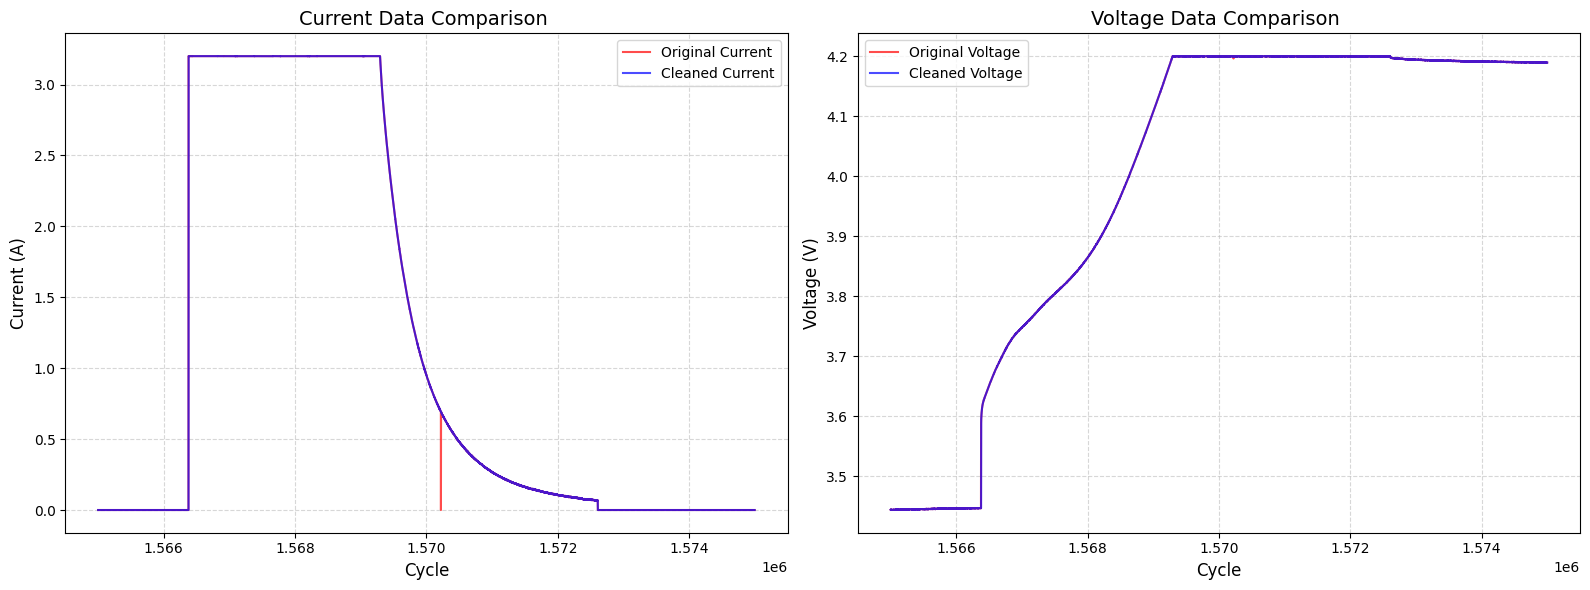

In [11]:
# 전류 이상치 제거 첫 번째 구간 (1565000:1575000) 플롯
start, end = 1565000, 1575000
indices = np.arange(start, end)
# 특정 구간 데이터 비교를 좌우로 배치하여 시각화
fig, axs = plt.subplots(1, 2, figsize=(16, 6), sharey=False)

# 전류 데이터 비교 (왼쪽)
axs[0].plot(indices, current_data[start:end], 'r-', label='Original Current', alpha=0.7)
axs[0].plot(indices, current_c[start:end], 'b-', label='Cleaned Current', alpha=0.7)
axs[0].set_title(f'Current Data Comparison ', fontsize=14)
axs[0].set_xlabel('Cycle', fontsize=12)
axs[0].set_ylabel('Current (A)', fontsize=12)
axs[0].legend(fontsize=10)
axs[0].grid(True, linestyle='--', alpha=0.5)

# 전압 데이터 비교 (오른쪽)
axs[1].plot(indices, voltage_data[start:end], 'r-', label='Original Voltage', alpha=0.7)
axs[1].plot(indices, voltage_c[start:end], 'b-', label='Cleaned Voltage', alpha=0.7)
axs[1].set_title(f'Voltage Data Comparison ', fontsize=14)
axs[1].set_xlabel('Cycle', fontsize=12)
axs[1].set_ylabel('Voltage (V)', fontsize=12)
axs[1].legend(fontsize=10)
axs[1].grid(True, linestyle='--', alpha=0.5)

# 레이아웃 조정
plt.tight_layout()
plt.show()


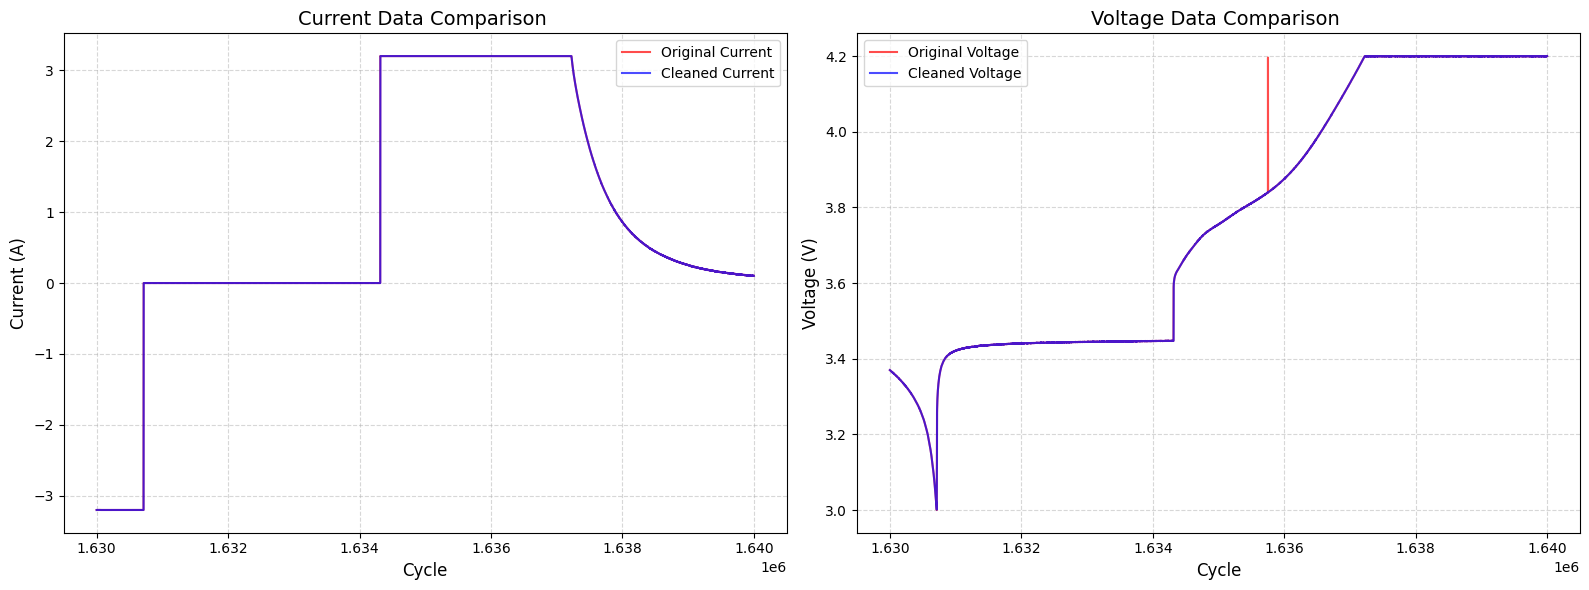

In [12]:
# 전압 이상치 제거 첫 번째 구간 (1630000: 1640000) 플롯
start, end = 1630000, 1640000
indices = np.arange(start, end)
# 특정 구간 데이터 비교를 좌우로 배치하여 시각화
fig, axs = plt.subplots(1, 2, figsize=(16, 6), sharey=False)

# 전류 데이터 비교 (왼쪽)
axs[0].plot(indices, current_data[start:end], 'r-', label='Original Current', alpha=0.7)
axs[0].plot(indices, current_c[start:end], 'b-', label='Cleaned Current', alpha=0.7)
axs[0].set_title(f'Current Data Comparison ', fontsize=14)
axs[0].set_xlabel('Cycle', fontsize=12)
axs[0].set_ylabel('Current (A)', fontsize=12)
axs[0].legend(fontsize=10)
axs[0].grid(True, linestyle='--', alpha=0.5)

# 전압 데이터 비교 (오른쪽)
axs[1].plot(indices, voltage_data[start:end], 'r-', label='Original Voltage', alpha=0.7)
axs[1].plot(indices, voltage_c[start:end], 'b-', label='Cleaned Voltage', alpha=0.7)
axs[1].set_title(f'Voltage Data Comparison ', fontsize=14)
axs[1].set_xlabel('Cycle', fontsize=12)
axs[1].set_ylabel('Voltage (V)', fontsize=12)
axs[1].legend(fontsize=10)
axs[1].grid(True, linestyle='--', alpha=0.5)

# 레이아웃 조정
plt.tight_layout()
plt.show()


## 용량 추출 방전구간 

In [13]:
# 데이터 레퍼런스 용량 추출을 위한 방전 구간 추출
discharge_start_point = np.zeros(data_length) # 방전 시작 지점 계산

for j in range(1, data_length):
    if current_c[j] == 0 and current_c[j - 1] > 0:
        discharge_start_point[j] = 0
    elif current_c[j] < 0 and current_c[j - 1] == 0: # 현재 시점의 전류가 0 보다 작고 (방전 구간) 이전 시점의 전류가 0과 같다면 (휴지구간) 그 지점은 방전 시작 지점
        discharge_start_point[j] = 1
        
find_discharge_start_point = np.where(discharge_start_point == 1)[0]
find_discharge_start_point_length = len(find_discharge_start_point)

discharge_end_point = np.zeros(data_length) # 방전 끝나는 지점 계산

for m in range(data_length - 1):
    if current_c[m] < 0 and current_c[m + 1] == 0: # 현재 시점의 전류가 0 보다 작고 (방전 구간) 다음 시점의 전류가 0과 같다면 (휴지구간) 그 지점은 방전이 끝나는 지점
        discharge_end_point[m] = 1
        
find_discharge_end_point = np.where(discharge_end_point == 1)[0]
find_discharge_end_point_length = len(find_discharge_end_point)


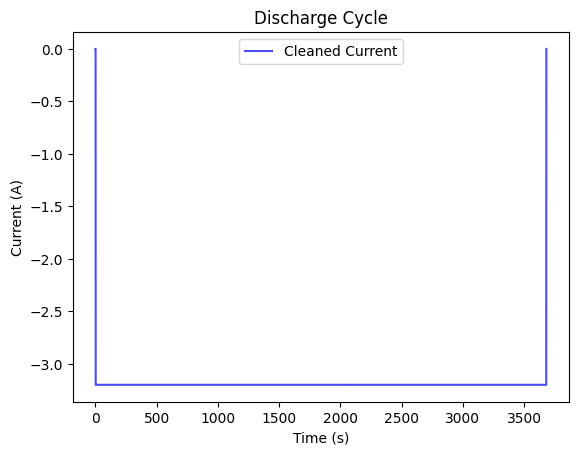

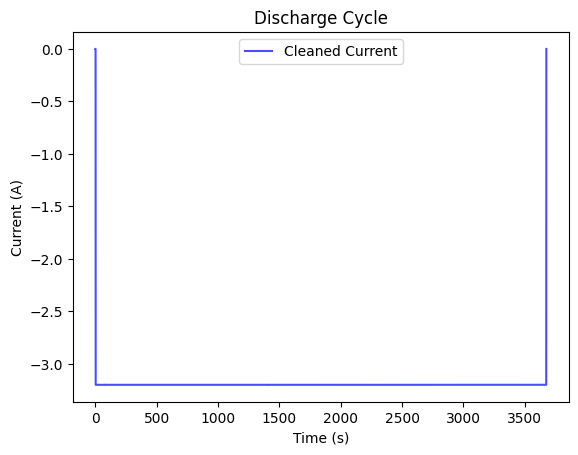

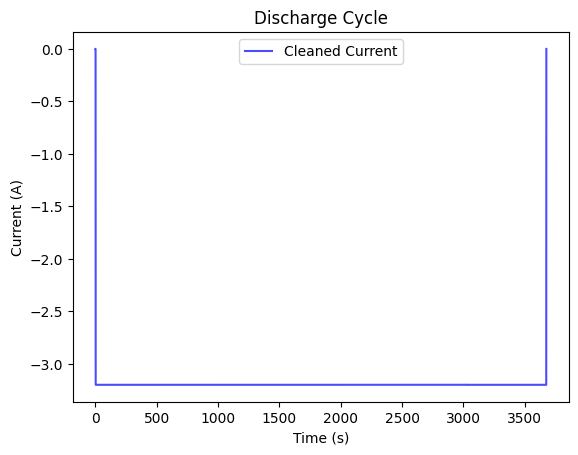

In [14]:
# 방전 구간이 잘 분리 됬는지 확인
for r in range(3):
    discharge_cycle1 = data_c[find_discharge_start_point[r]-2:find_discharge_end_point[r]+2, 0]
    plt.plot(discharge_cycle1, 'b-', label='Cleaned Current', alpha=0.7)
    plt.title('Discharge Cycle')
    plt.xlabel('Time (s)')
    plt.ylabel('Current (A)')
    plt.legend()
    plt.show()

In [15]:
# 3) 데이터의 방전 용량 추출 및 SOH 데이터로 환산
Capacity = []
for r in range(len(find_discharge_end_point)):
    discharge_cycle1 = current_c[find_discharge_start_point[r]:find_discharge_end_point[r]]# 입력 데이터의 모든 방전 구간 추출
    capacity = -sum(discharge_cycle1) / 3600 * sampling_time # 시간 단위로 면적 계산
    Capacity.append(capacity) 
    

방전이 시작되는 지점:  [   12967    29999    47012 ... 22685231 22697576 22709880]
방전이 끝나는 지점:  [   16645    33673    50685 ... 22685936 22698276 22710573]


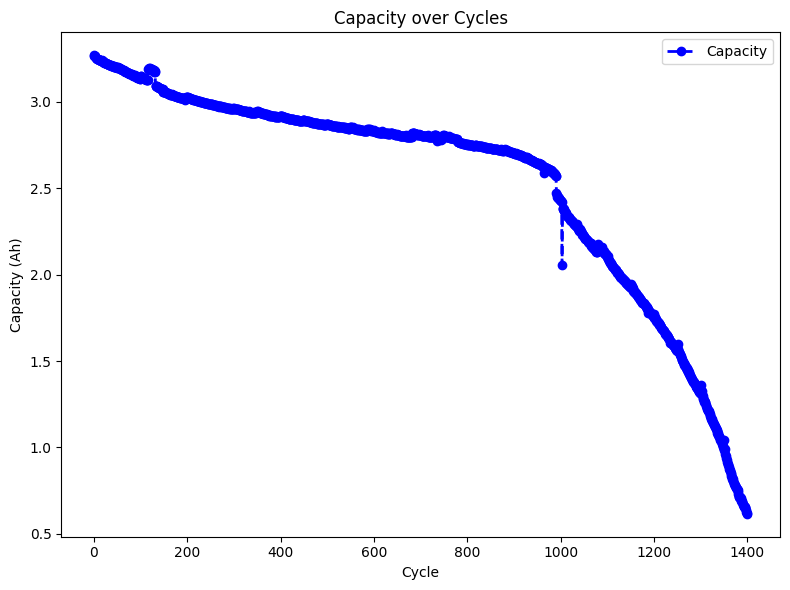

In [16]:
print("방전이 시작되는 지점: ", find_discharge_start_point)
print("방전이 끝나는 지점: ", find_discharge_end_point)

# Capacity 그래프
plt.figure(figsize=(8, 6))
plt.plot(Capacity, marker='o', linestyle='--', color='b', linewidth=2, label='Capacity')
plt.xlabel('Cycle')
plt.ylabel('Capacity (Ah)')
plt.title('Capacity over Cycles')
plt.legend()
plt.tight_layout()
plt.show()


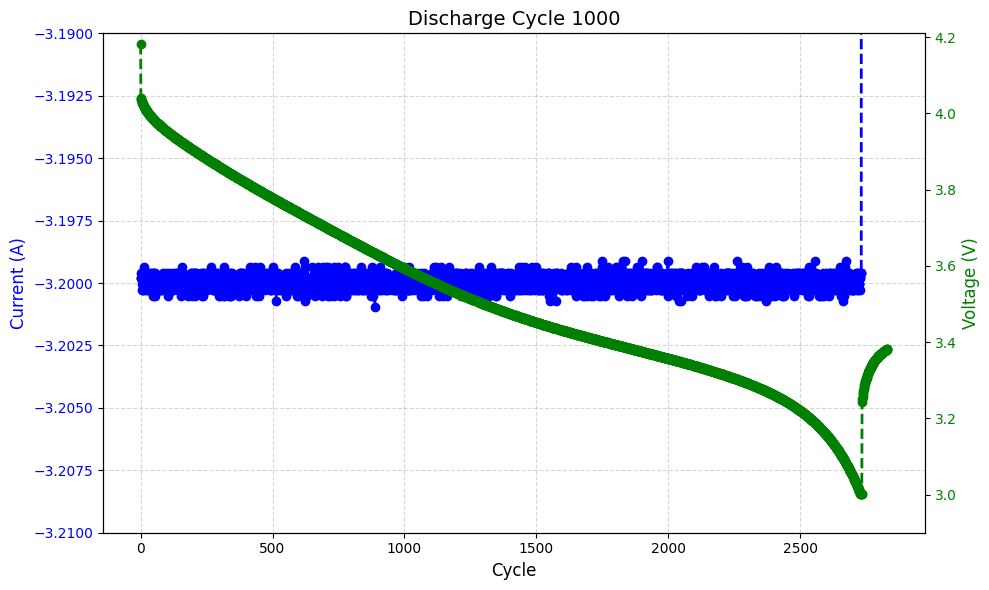

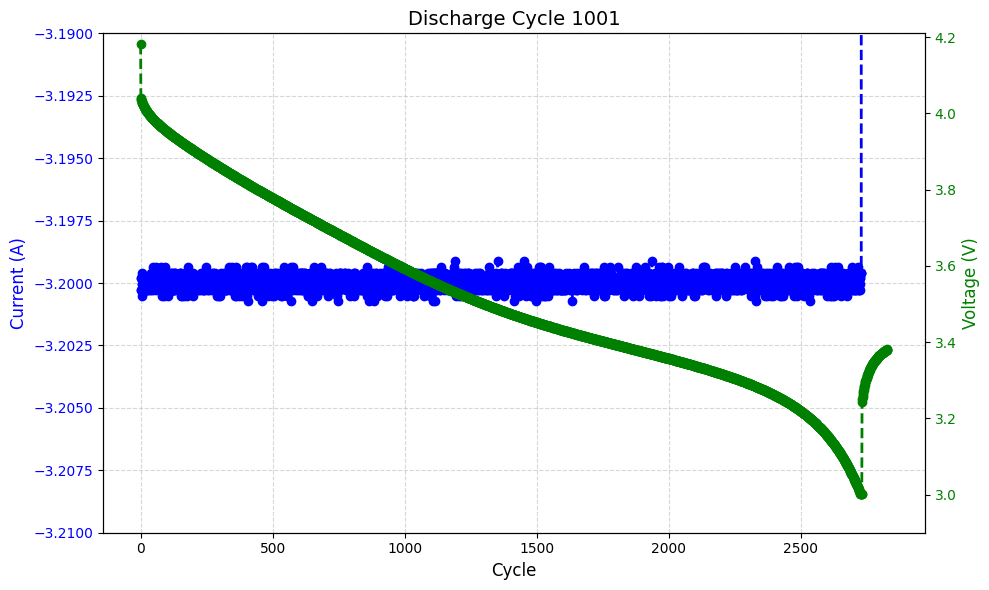

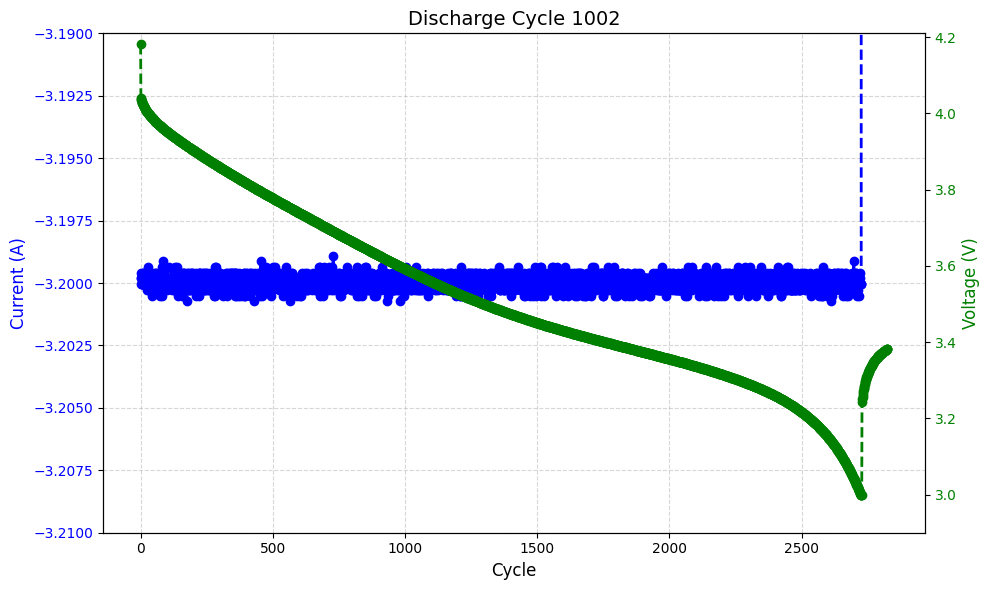

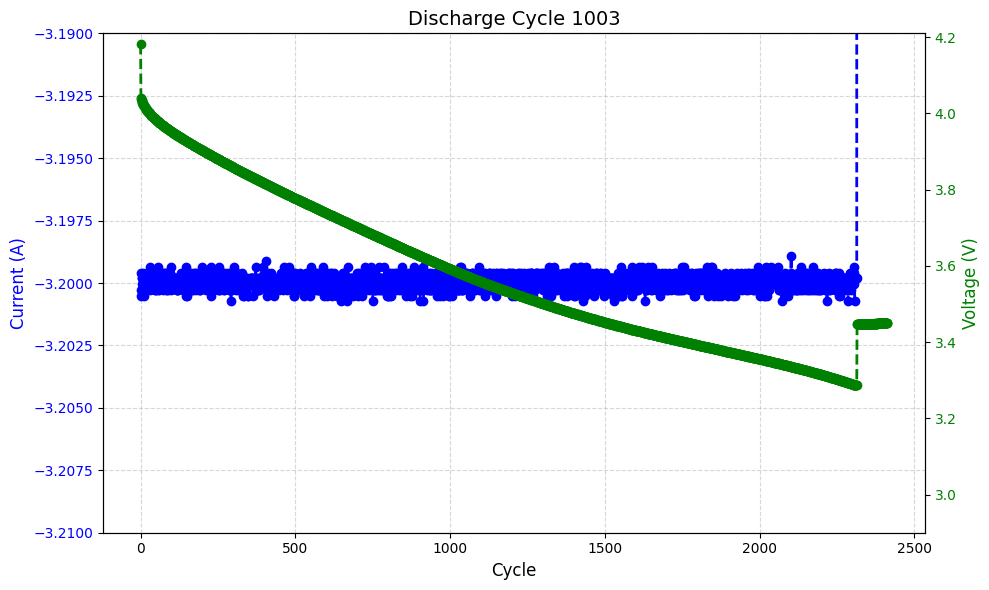

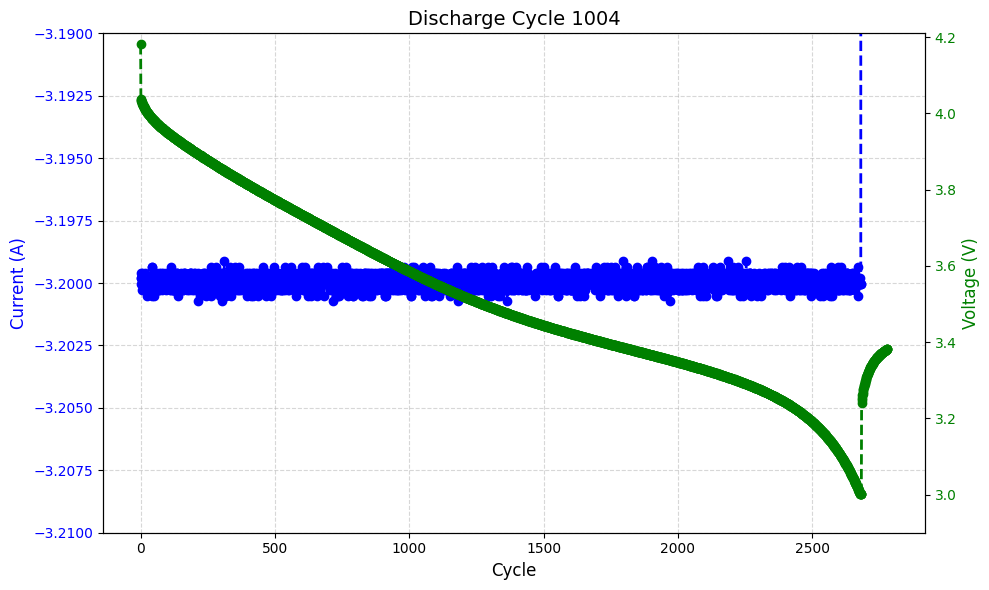

In [17]:
# 이상한 지점 확인 (수정된 코드) 1004번째 데이터에서 전압이 3.0 V 도달전에 종료
for r in range(5):
    discharge_cycle = data_c[find_discharge_start_point[r+1000]:find_discharge_end_point[r+1000]+100]
    
    fig, ax1 = plt.subplots(figsize=(10, 6))
    
    # 첫 번째 축 (왼쪽, 전류 데이터)
    ax1.plot(discharge_cycle[:, 0], marker='o', linestyle='--', color='b', linewidth=2, label='Current')
    ax1.set_xlabel('Cycle', fontsize=12)
    ax1.set_ylabel('Current (A)', fontsize=12, color='b')
    ax1.tick_params(axis='y', labelcolor='b')
    ax1.grid(True, linestyle='--', alpha=0.5)
    ax1.set_ylim(-3.21, -3.19)
    # 두 번째 축 (오른쪽, 전압 데이터)
    ax2 = ax1.twinx()
    ax2.plot(discharge_cycle[:, 1], marker='o', linestyle='--', color='g', linewidth=2, label='Voltage')
    ax2.set_ylabel('Voltage (V)', fontsize=12, color='g')
    ax2.tick_params(axis='y', labelcolor='g')
    ax2.set_ylim(2.9,4.21)
    # 제목 및 레이아웃 설정
    plt.title(f'Discharge Cycle {r+1000}', fontsize=14)
    fig.tight_layout()  # 레이아웃 조정
    plt.show()

방전이 시작되는 지점:  [   12967    29999    47012 ... 22685231 22697576 22709880]
방전이 끝나는 지점:  [   16645    33673    50685 ... 22685936 22698276 22710573]


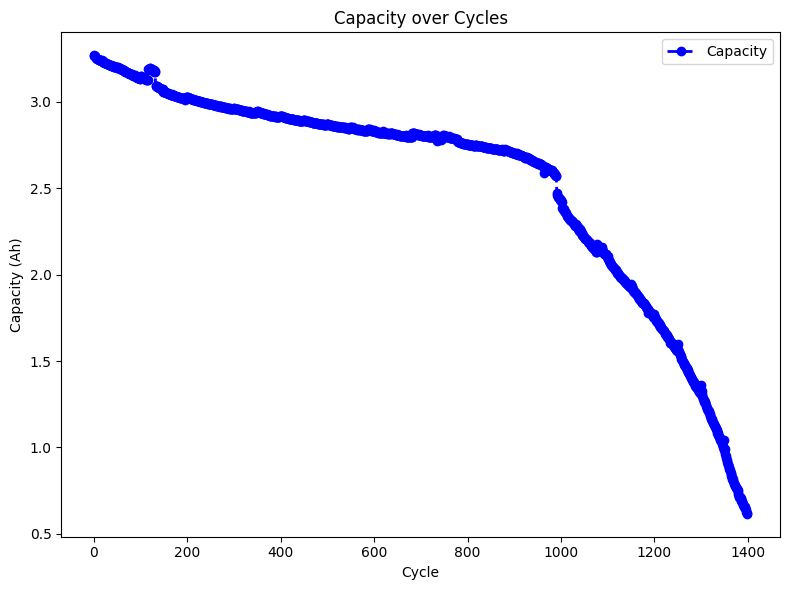

In [18]:
Capacity = []
for r in range(len(find_discharge_end_point)):
    if r == 1003:  # 1003번째 데이터 제외
        continue
    discharge_cycle1 = current_c[find_discharge_start_point[r]:find_discharge_end_point[r]]  # 입력 데이터의 모든 방전 구간 추출
    capacity = -sum(discharge_cycle1) / 3600 * sampling_time  # 시간 단위로 면적 계산
    Capacity.append(capacity)

print("방전이 시작되는 지점: ", find_discharge_start_point)
print("방전이 끝나는 지점: ", find_discharge_end_point)

# Capacity 그래프
plt.figure(figsize=(8, 6))
plt.plot(Capacity, marker='o', linestyle='--', color='b', linewidth=2, label='Capacity')
plt.xlabel('Cycle')
plt.ylabel('Capacity (Ah)')
plt.title('Capacity over Cycles')
plt.legend()
plt.tight_layout()
plt.show()


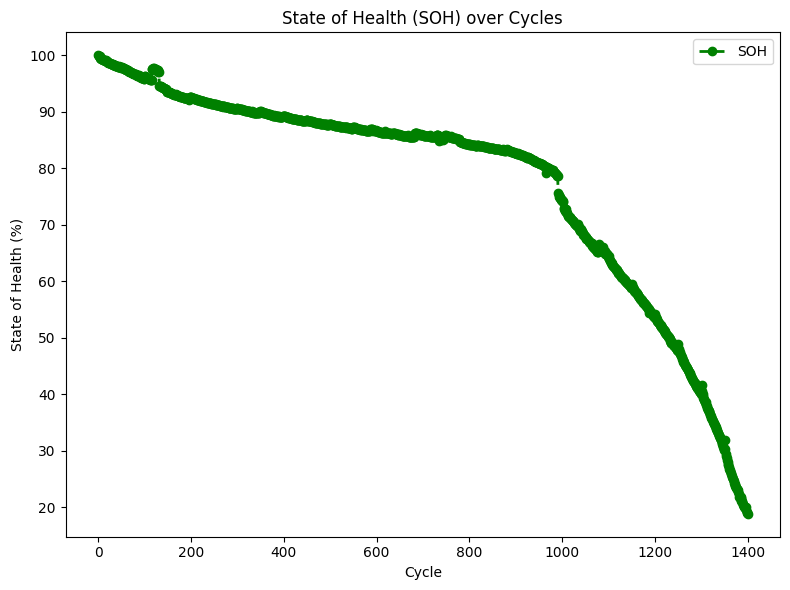

In [19]:
# SOH 계산 및 그래프
first_capacity_value = Capacity[0]
SOH = (np.array(Capacity) / first_capacity_value) * 100

plt.figure(figsize=(8, 6))
plt.plot(SOH, marker='o', linestyle='--', color='g', linewidth=2, label='SOH')
plt.xlabel('Cycle')
plt.ylabel('State of Health (%)')
plt.title('State of Health (SOH) over Cycles')
plt.legend()
plt.tight_layout()
plt.show()


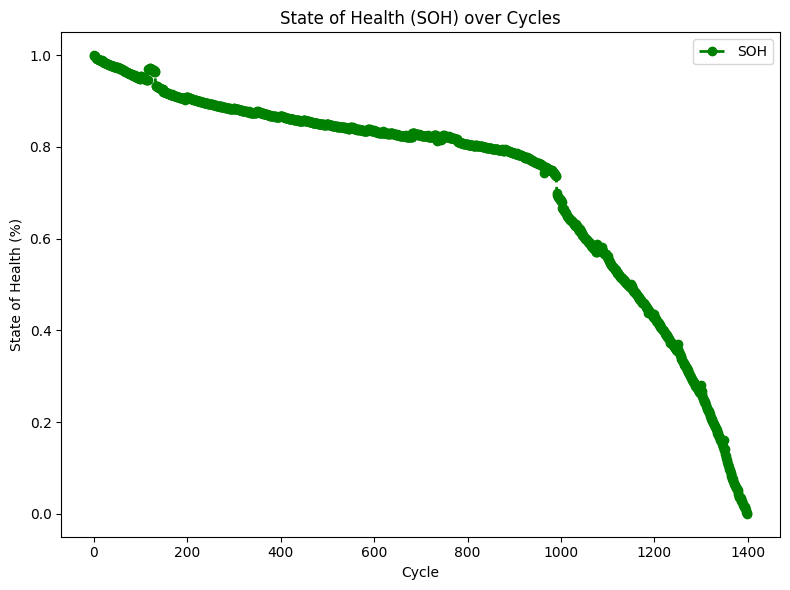

Scaling parameters saved to 'scaling_params.json'


In [20]:
import json

def min_max_scaling(x):
    x_np = np.asarray(x)  # 데이터를 Numpy 배열로 변환
    x_min = x_np.min()    # 데이터의 최소값
    x_max = x_np.max()    # 데이터의 최대값
    scaled_x = (x_np - x_min) / (x_max - x_min)  # Min-Max Scaling
    return scaled_x, x_min, x_max  # 스케일링된 데이터와 최소/최대값 반환

## Min-Max 스케일링 역변환 함수
def reverse_min_max_scaling(x, x_min, x_max):
    x_np = np.asarray(x)  # 데이터를 Numpy 배열로 변환
    reversed_x = (x_np * (x_max - x_min)) + x_min  # 원본 데이터 복원
    return reversed_x

SOH_normalized,x_min,x_max = min_max_scaling(SOH)

plt.figure(figsize=(8, 6))
plt.plot(SOH_normalized, marker='o', linestyle='--', color='g', linewidth=2, label='SOH')
plt.xlabel('Cycle')
plt.ylabel('State of Health (%)')
plt.title('State of Health (SOH) over Cycles')
plt.legend()
plt.tight_layout()
plt.show()


# x_min, x_max 값을 JSON 파일로 저장
scaling_params = {'x_min': float(x_min), 'x_max': float(x_max)}
with open('scaling_params.json', 'w') as f:
    json.dump(scaling_params, f)

print("Scaling parameters saved to 'scaling_params.json'")


## 충전 데이터 추출 및 HI 추출 

In [21]:
# 데이터의 충전 구간 추출
charge_start_point = np.zeros(data_length) # 충전 시작 지점 계산

for i in range(1, data_length):
    if current_c[i] == 0 and current_c[i - 1] < 0: 
        charge_start_point[i] = 0
    elif current_c[i] > 0 and current_c[i - 1] == 0: # 현재 시점의 전류가 0 보다 크고 (충전 구간) 이전 시점의 전류가 0과 같다면 (휴지구간) 그 지점은 충전 시작 지점
        charge_start_point[i] = 1
        
find_charge_start_point = np.where(charge_start_point == 1)[0]
find_charge_start_point_length = len(find_charge_start_point)

charge_end_point = np.zeros(data_length) # 충전 끝나는 지점 계산

for k in range(data_length - 1):
    if current_c[k] > 0 and current_c[k + 1] == 0: # 현재 시점의 전류가 0 보다 크고 (충전 구간) 다음 시점의 전류가 0과 같다면 (휴지구간) 그 지점은 충전이 끝나는 지점
        charge_end_point[k] = 1
        
find_charge_end_point = np.where(charge_end_point == 1)[0]
find_charge_end_point_length = len(find_charge_end_point)

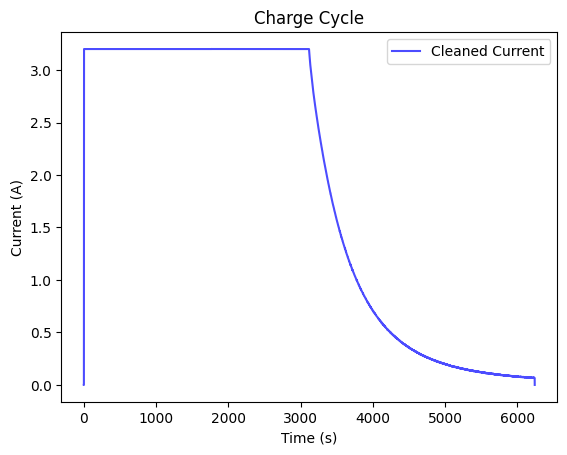

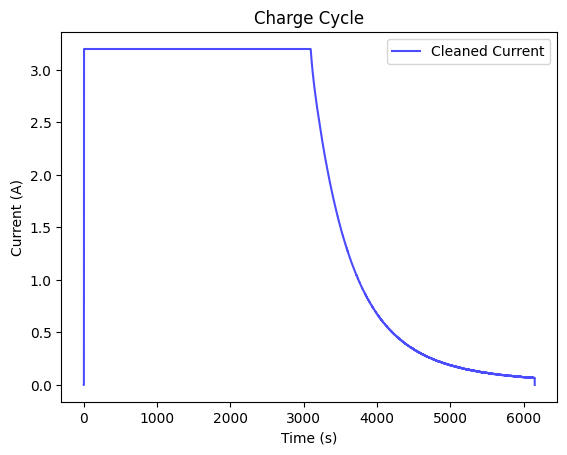

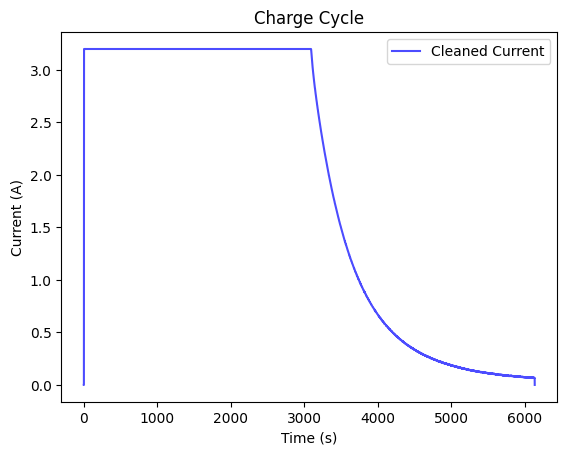

In [22]:
# 충전 구간이 잘 분리 됬는지 확인
for r in range(3):
    charge_cycle1 = data_c[find_charge_start_point[r]-2:find_charge_end_point[r]+2, 0]
    plt.plot(charge_cycle1, 'b-', label='Cleaned Current', alpha=0.7)
    plt.title('Charge Cycle')
    plt.xlabel('Time (s)')
    plt.ylabel('Current (A)')
    plt.legend()
    plt.show()

In [24]:
# 충전 구간 내 Feature 추출 - TIEDVD
TIECVD_ch = []

def TIECVD(data): # TIEDVD 추출 3.0V - 4.2V (0.2V 간격)
    voltage = data[:, 1]
    edges = np.arange(3.0, 4.2, 0.2)  # 간격 지정 
    interval_counts, _ = np.histogram(voltage, bins=edges)
    return interval_counts

for r in range(len(find_charge_end_point)):
    charge_cycle = data_c[find_charge_start_point[r]:find_charge_end_point[r], :]
    if r == 1003:  # 1003번째 데이터 제외
        continue
    tiecvd = TIECVD(charge_cycle) # TIEDVD 추출
    TIECVD_ch.append(tiecvd)
  
TIECVD_ch = np.array(TIECVD_ch)

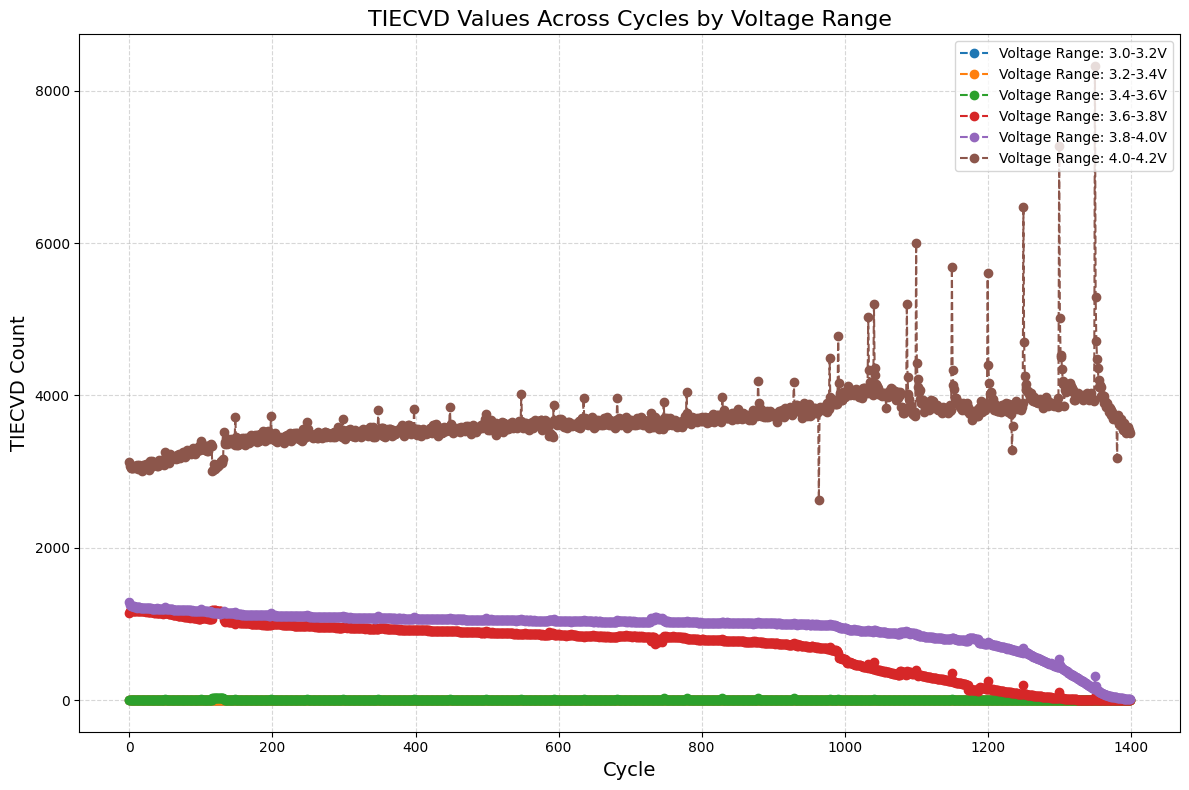

In [26]:
# TIECVD 추출결과 - CV 구간 이상함 당연하징
plt.figure(figsize=(12, 8))
num_bins = TIECVD_ch.shape[1]  # 구간 수
bin_labels = [f"{3.0 + i*0.2:.1f}-{3.2 + i*0.2:.1f}V" for i in range(num_bins)]

for i in range(num_bins):
    plt.plot(TIECVD_ch[:, i], marker='o', linestyle='--', label=f'Voltage Range: {bin_labels[i]}')

plt.xlabel('Cycle', fontsize=14)
plt.ylabel('TIECVD Count', fontsize=14)
plt.title('TIECVD Values Across Cycles by Voltage Range', fontsize=16)
plt.legend(fontsize=10, loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [28]:
# 충전 구간 내 Feature 추출 - MVF
MVF_ch = []

def MVF(data): # MVF 추출
    voltage = data[:, 1]
    MV = [4.2 - v for v in voltage] # 4.2V(상한전압) - 모든 시점의 전압의 평균 계산 
    interval_counts = sum(MV) / len(voltage)  
    return interval_counts

for r in range(len(find_charge_end_point)):
    charge_cycle = data_c[find_charge_start_point[r]:find_charge_end_point[r], :]
    if r == 1003:  # 1003번째 데이터 제외
        continue
    mvf = MVF(charge_cycle) # TIEDVD 추출
    MVF_ch.append(mvf)
  
MVF_ch = np.array(MVF_ch)

C:\Users\LG\AppData\Local\Temp\ipykernel_520\3683069135.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=10, loc='upper right')


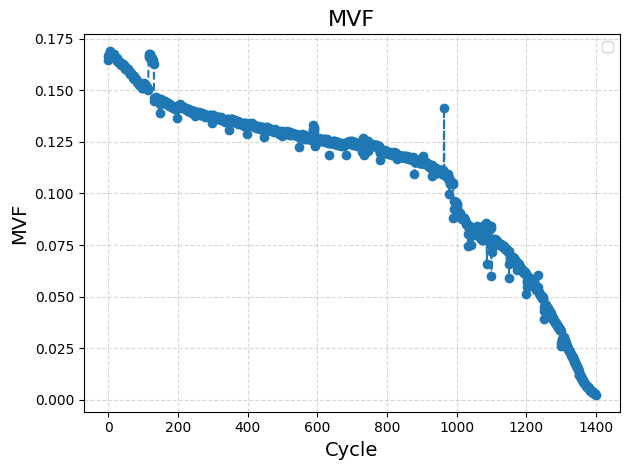

In [29]:
plt.plot(MVF_ch, marker='o', linestyle='--')
plt.xlabel('Cycle', fontsize=14)
plt.ylabel('MVF', fontsize=14)
plt.title('MVF', fontsize=16)
plt.legend(fontsize=10, loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [31]:
def VIECTD(data):
    voltage = data[:, 1]  # 전압 데이터 추출
    edges = np.arange(3.2, 4.2, 0.2)  # 3.2V ~ 4.0V 범위 구간 설정
    interval_counts = []

    for edge in edges:
        # 해당 전압을 처음 넘어가는 인덱스 추출
        indices = np.where(voltage >= edge)[0]

        if len(indices) > 0 and indices[0] + 100 < len(voltage):  # 첫 번째 인덱스와 +100이 유효할 경우
            v_start = voltage[indices[0]]  # 구간의 첫 번째 전압
            v_end = voltage[indices[0] + 100]  # 100초 후의 전압
            interval_counts.append(v_start - v_end)
        else:
            interval_counts.append(np.nan)  # 데이터 부족 시 NaN 처리

    return interval_counts

# VIEDTD 계산 및 저장
VIECTD_ch = []

for r in range(len(find_charge_end_point)):
    charge_cycle = data_c[find_charge_start_point[r]:find_charge_end_point[r], :]
    if r == 1003:  # 1003번째 데이터 제외
        continue
    viectd = VIECTD(charge_cycle)  # VIEDTD 추출
    VIECTD_ch.append(viectd)

VIECTD_ch = np.array(VIECTD_ch)


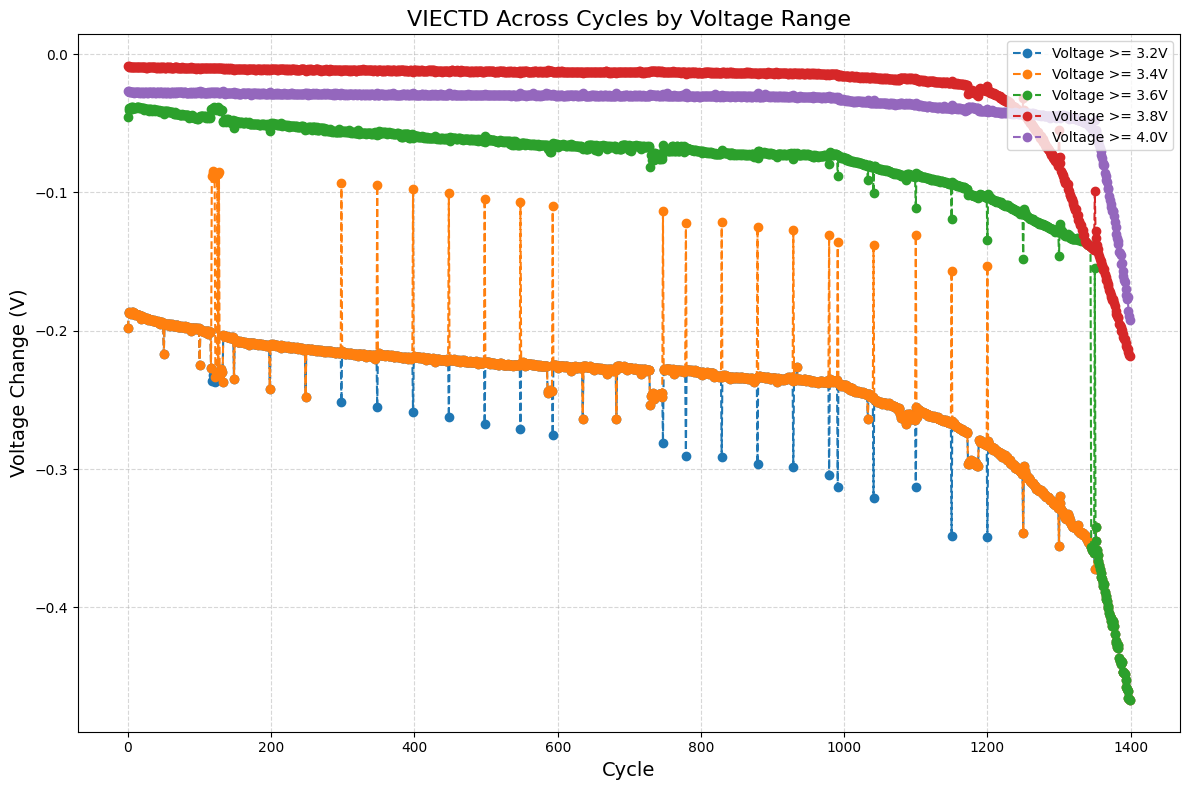

In [32]:
# VIECTD 시각화
plt.figure(figsize=(12, 8))
num_bins = VIECTD_ch.shape[1]  # 구간 수
bin_labels = [f"{3.2 + i*0.2:.1f}V" for i in range(num_bins)]

for i in range(num_bins):
    plt.plot(VIECTD_ch[:, i], marker='o', linestyle='--', label=f'Voltage >= {bin_labels[i]}')

plt.xlabel('Cycle', fontsize=14)
plt.ylabel('Voltage Change (V)', fontsize=14)
plt.title('VIECTD Across Cycles by Voltage Range', fontsize=16)
plt.legend(fontsize=10, loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [33]:
# 충전 구간 내 Feature 추출 - Partial cap
Partialcap_ch = []

def Partialcap(data):
    try:
        voltage = data[:, 1]
        current = data[:, 0]
        v1 = []
        v2 = []
        v3 = []
        v4 = []
        v5 = []
        v6 = []

        for i in range(len(voltage)):
            if 3.0 <= voltage[i] <= 3.2:
                v1.append(current[i])
            elif 3.2 <= voltage[i] <= 3.4:
                v2.append(current[i])
            elif 3.4 <= voltage[i] <= 3.6:
                v3.append(current[i])
            elif 3.6 <= voltage[i] <= 3.8:
                v4.append(current[i])
            elif 3.8 <= voltage[i] <= 4.0:
                v5.append(current[i])
            elif 4.0 <= voltage[i] <= 4.2:
                v6.append(current[i])
        
        # 구간별 전류 적산 후 미소 용량 계산
        v11 = sum(v1) / 3600 * sampling_time
        v12 = sum(v2) / 3600 * sampling_time
        v13 = sum(v3) / 3600 * sampling_time
        v14 = sum(v4) / 3600 * sampling_time
        v15 = sum(v5) / 3600 * sampling_time
        v16 = sum(v6) / 3600 * sampling_time

        interval_counts = [v11, v12, v13, v14, v15, v16]
        return interval_counts
    except Exception as e:
        print(f"An error occurred: {e}")
        return None

# 충전 구간에 대해 Partialcap 추출
for r in range(len(find_charge_end_point)):
    charge_cycle = data_c[find_charge_start_point[r]:find_charge_end_point[r], :]
    if r == 1003:  # 1003번째 데이터 제외
        continue
    partialcap = Partialcap(charge_cycle)  # Partialcap 추출
    Partialcap_ch.append(partialcap)

Partialcap_ch = np.array(Partialcap_ch)

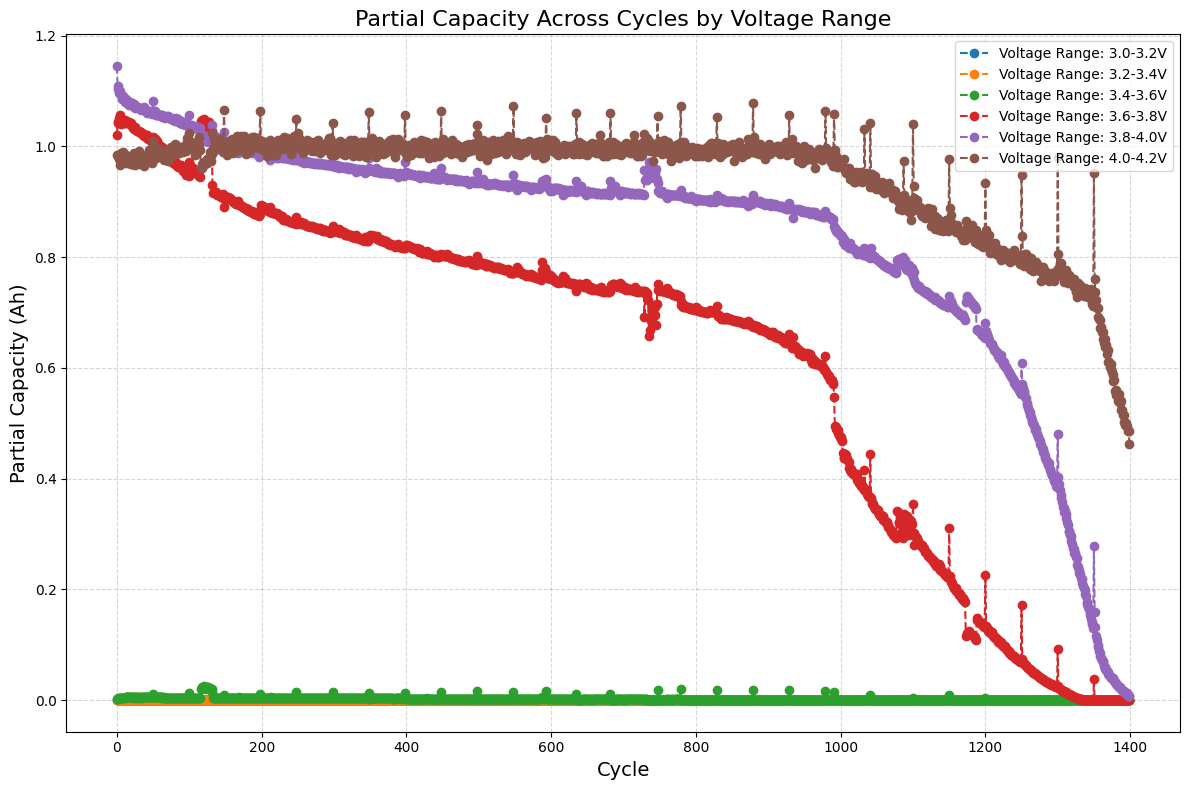

In [34]:
# Partialcap 시각화
plt.figure(figsize=(12, 8))
num_bins = Partialcap_ch.shape[1]  # 구간 수
bin_labels = [f"{3.0 + i*0.2:.1f}-{3.2 + i*0.2:.1f}V" for i in range(num_bins)]

for i in range(num_bins):
    plt.plot(Partialcap_ch[:, i], marker='o', linestyle='--', label=f'Voltage Range: {bin_labels[i]}')

plt.xlabel('Cycle', fontsize=14)
plt.ylabel('Partial Capacity (Ah)', fontsize=14)
plt.title('Partial Capacity Across Cycles by Voltage Range', fontsize=16)
plt.legend(fontsize=10, loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [35]:
# CCarea 계산 및 저장
CCarea_ch = []

# CCarea 함수 정의
def CCarea(data):
    current = data[:, 0]  # 전류 데이터 추출
    CC_indices = np.where(np.abs(current) >= 3.1990)[0]  # CC 조건에 해당하는 인덱스 추출
    interval_counts = sum(current[CC_indices]) / 3600 * sampling_time  # 면적 계산 (Ah 단위)
    return interval_counts

for r in range(len(find_charge_end_point)):
    charge_cycle = data_c[find_charge_start_point[r]:find_charge_end_point[r], :]
    if r == 1003:  # 1003번째 데이터 제외
        continue
    cc_area = CCarea(charge_cycle)  # CCarea 추출
    CCarea_ch.append(cc_area)

CCarea_ch = np.array(CCarea_ch)

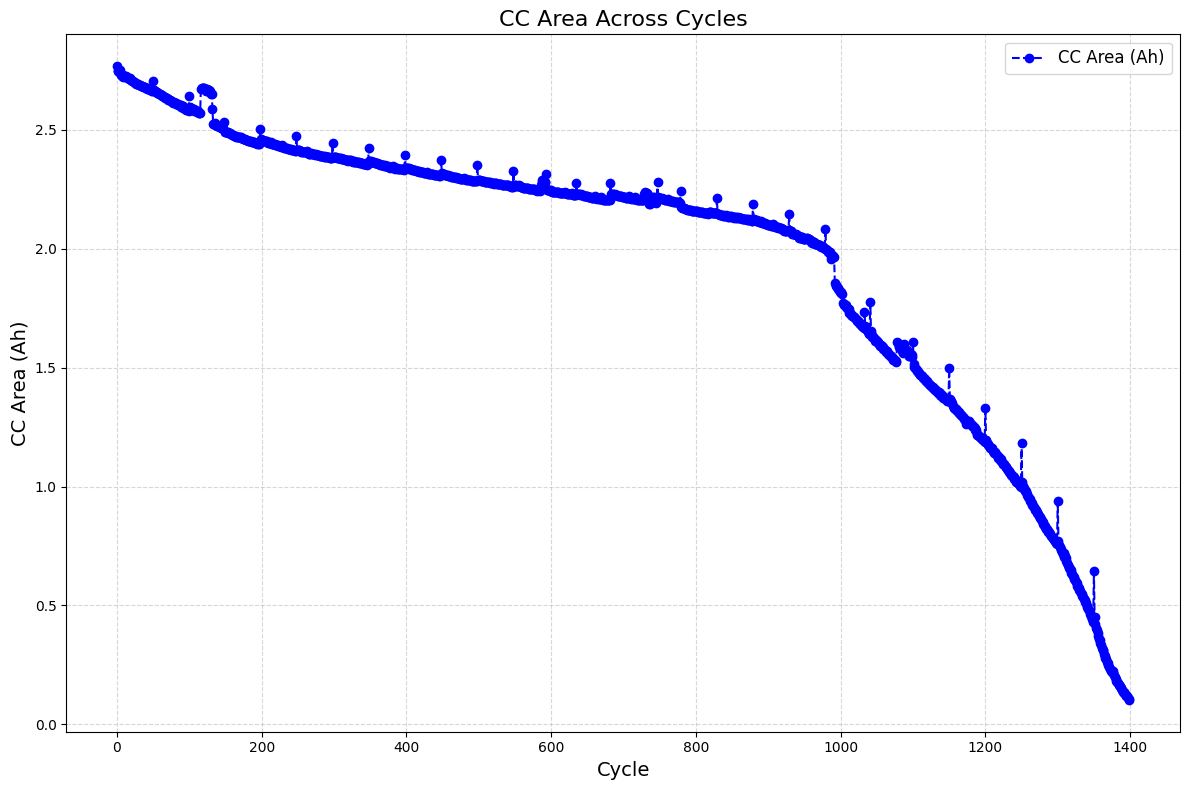

In [36]:
# CCarea 시각화
plt.figure(figsize=(12, 8))
plt.plot(CCarea_ch, marker='o', linestyle='--', color='b', label='CC Area (Ah)')
plt.xlabel('Cycle', fontsize=14)
plt.ylabel('CC Area (Ah)', fontsize=14)
plt.title('CC Area Across Cycles', fontsize=16)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

In [37]:
# CCtime 함수 정의
def CCtime(data):
    current = data[:, 0]  # 전류 데이터 추출
    CC_indices = np.where(np.abs(current) >= 3.1990)[0]  # CC 구간 인덱스 추출
    interval_counts = len(CC_indices) * sampling_time  # CC 구간 시간 계산 (초 단위)
    return interval_counts

# CCtime 계산 및 저장
CCtime_ch = []

for r in range(len(find_charge_end_point)):
    charge_cycle = data_c[find_charge_start_point[r]:find_charge_end_point[r], :]
    if r == 1003:  # 1003번째 데이터 제외
        continue
    cc_time = CCtime(charge_cycle)  # CCtime 추출
    CCtime_ch.append(cc_time)

CCtime_ch = np.array(CCtime_ch)

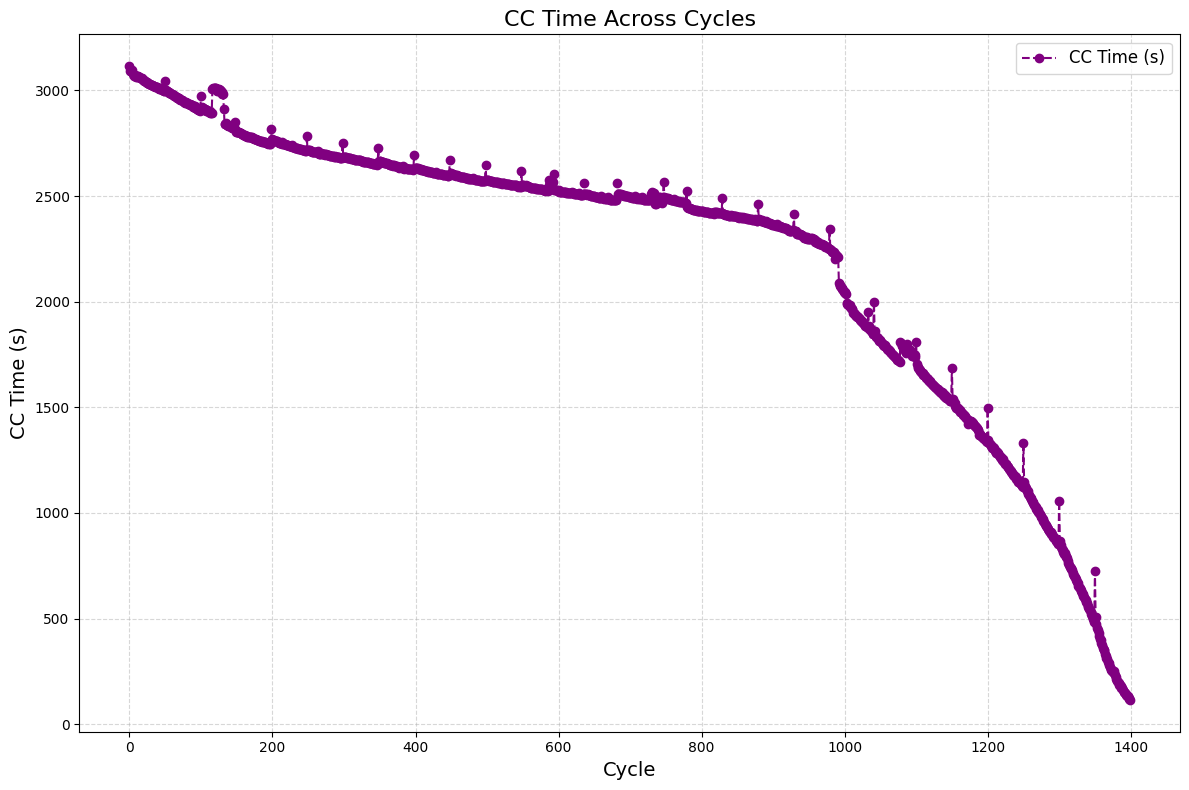

In [38]:
# CCtime 시각화
plt.figure(figsize=(12, 8))
plt.plot(CCtime_ch, marker='o', linestyle='--', color='purple', label='CC Time (s)')
plt.xlabel('Cycle', fontsize=14)
plt.ylabel('CC Time (s)', fontsize=14)
plt.title('CC Time Across Cycles', fontsize=16)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

In [39]:
# CVarea 함수 정의
def CVarea(data):
    current = data[:, 0]  # 전류 데이터 추출
    CV_indices = np.where(current < 3.1990)[0]  # CV 조건에 해당하는 인덱스 추출
    interval_counts = sum(current[CV_indices]) / 3600 * sampling_time  # 면적 계산 (Ah 단위)
    return interval_counts

# CVarea 계산 및 저장
CVarea_ch = []

for r in range(len(find_charge_end_point)):
    charge_cycle = data_c[find_charge_start_point[r]:find_charge_end_point[r], :]
    if r == 1003:  # 1003번째 데이터 제외
        continue
    cv_area = CVarea(charge_cycle)  # CVarea 추출
    CVarea_ch.append(cv_area)

CVarea_ch = np.array(CVarea_ch)


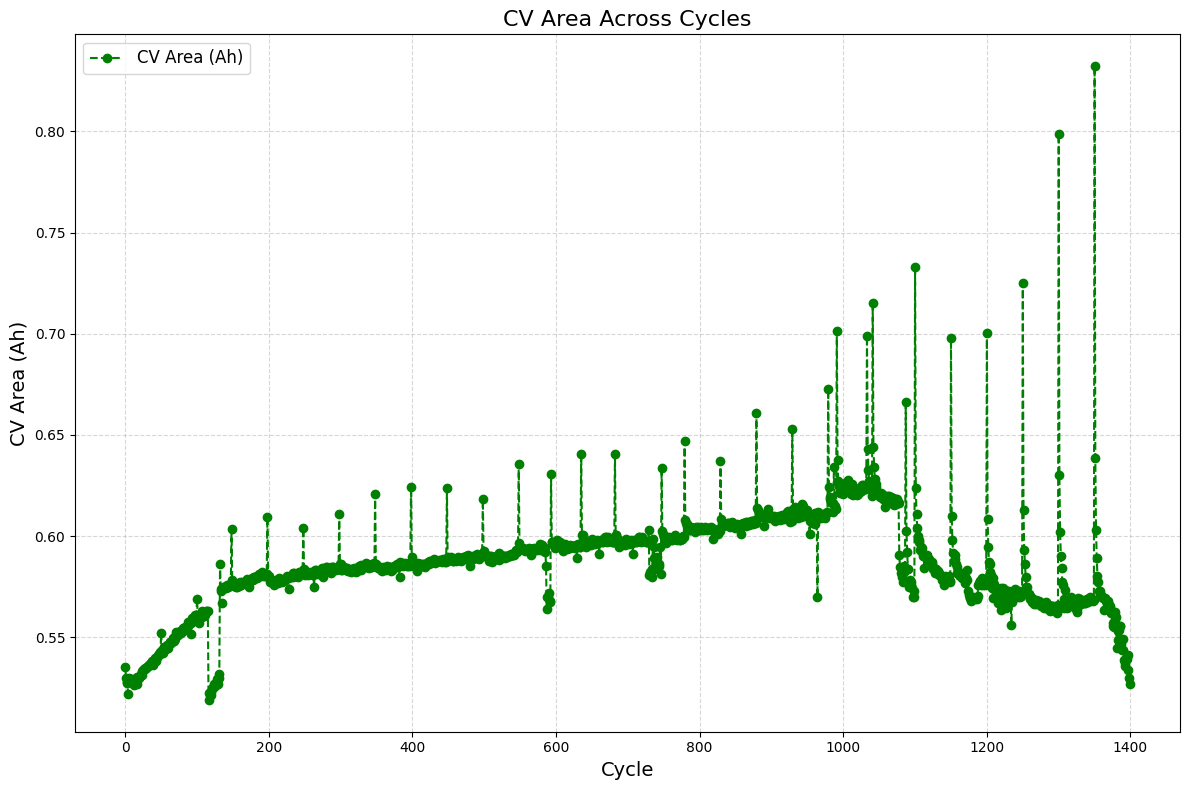

In [40]:
# CVarea 시각화
plt.figure(figsize=(12, 8))
plt.plot(CVarea_ch, marker='o', linestyle='--', color='g', label='CV Area (Ah)')
plt.xlabel('Cycle', fontsize=14)
plt.ylabel('CV Area (Ah)', fontsize=14)
plt.title('CV Area Across Cycles', fontsize=16)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

In [41]:
# CVtime 함수 정의
def CVtime(data):
    current = data[:, 0]  # 전류 데이터 추출
    CV_indices = np.where(current < 3.1990)[0]  # CV 구간 인덱스 추출
    interval_counts = len(CV_indices) * sampling_time  # CV 구간 시간 계산 (초 단위)
    return interval_counts

# CVtime 계산 및 저장
CVtime_ch = []

for r in range(len(find_charge_end_point)):
    charge_cycle = data_c[find_charge_start_point[r]:find_charge_end_point[r], :]
    if r == 1003:  # 1003번째 데이터 제외
        continue
    cv_time = CVtime(charge_cycle)  # CVtime 추출
    CVtime_ch.append(cv_time)

CVtime_ch = np.array(CVtime_ch)

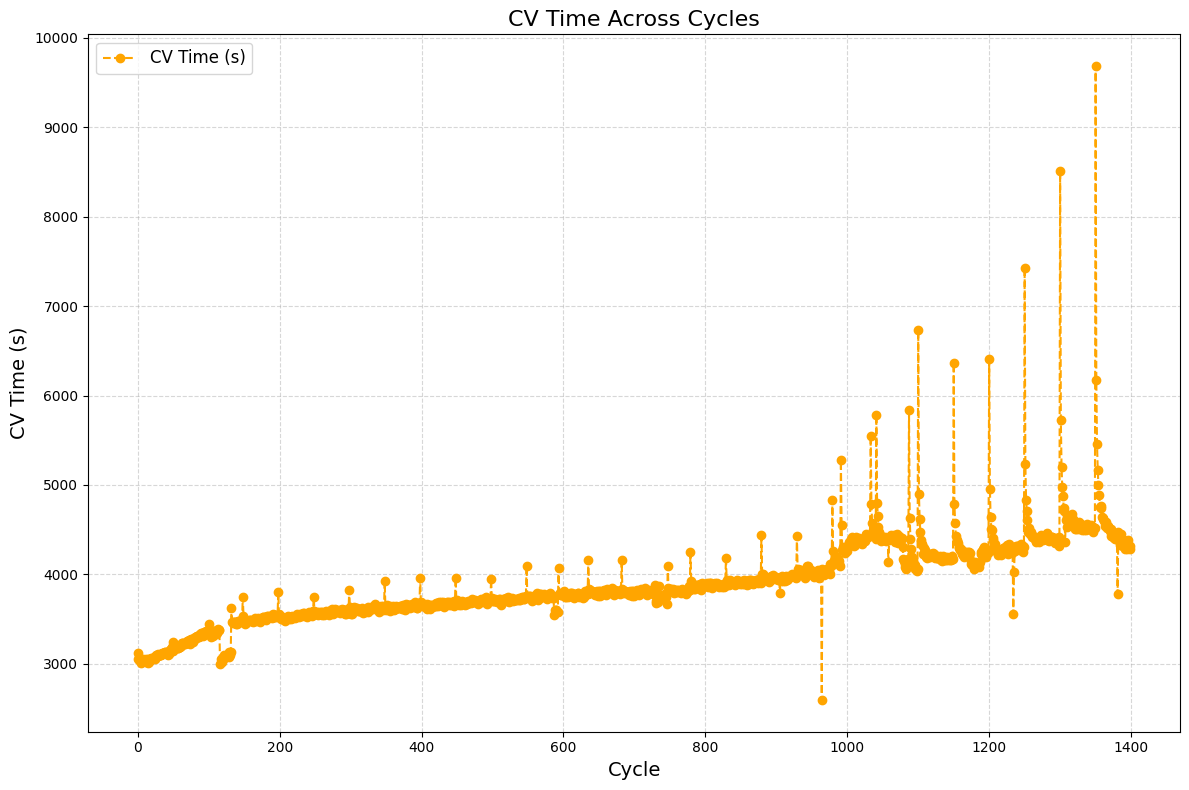

In [42]:
# CVtime 시각화
plt.figure(figsize=(12, 8))
plt.plot(CVtime_ch, marker='o', linestyle='--', color='orange', label='CV Time (s)')
plt.xlabel('Cycle', fontsize=14)
plt.ylabel('CV Time (s)', fontsize=14)
plt.title('CV Time Across Cycles', fontsize=16)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

In [43]:
def U010(data): # U010 추출
    voltage = data[:, 1]
    interval_counts = voltage[1* sampling_time] - voltage[600* sampling_time]  # 60*60, 10분 후 전압 빼기
    return interval_counts

U0m10_ch = []

for r in range(len(find_charge_end_point)):
    charge_cycle = data_c[find_charge_end_point[r] : find_charge_end_point[r]+601, :]
    if r == 1003:  # 1003번째 데이터 제외
        continue
    u0m10 = U010(charge_cycle) # U0m10 추출
    U0m10_ch.append(u0m10)
    
U0m10_ch = np.array(U0m10_ch)

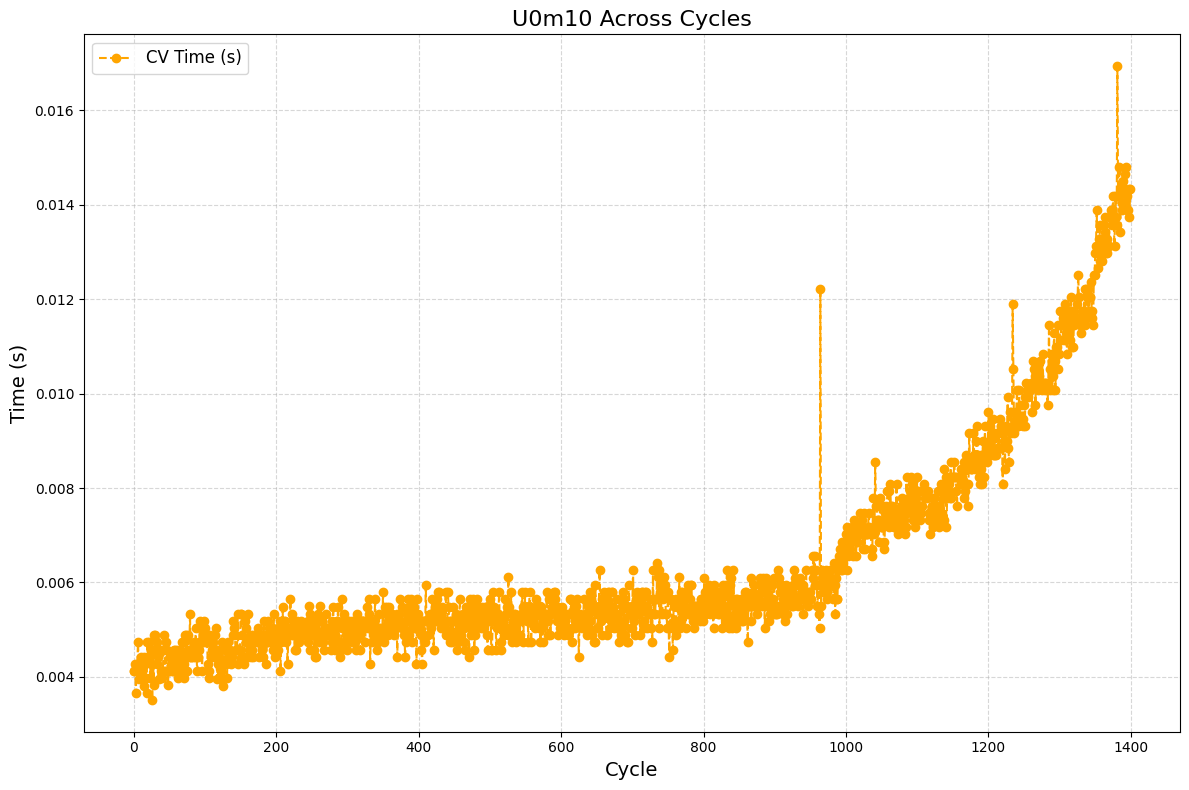

In [44]:
# CVtime 시각화
plt.figure(figsize=(12, 8))
plt.plot(U0m10_ch, marker='o', linestyle='--', color='orange', label='CV Time (s)')
plt.xlabel('Cycle', fontsize=14)
plt.ylabel('Time (s)', fontsize=14)
plt.title('U0m10 Across Cycles', fontsize=16)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

C:\Users\LG\AppData\Local\Temp\ipykernel_520\317254217.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=10, loc='upper right')


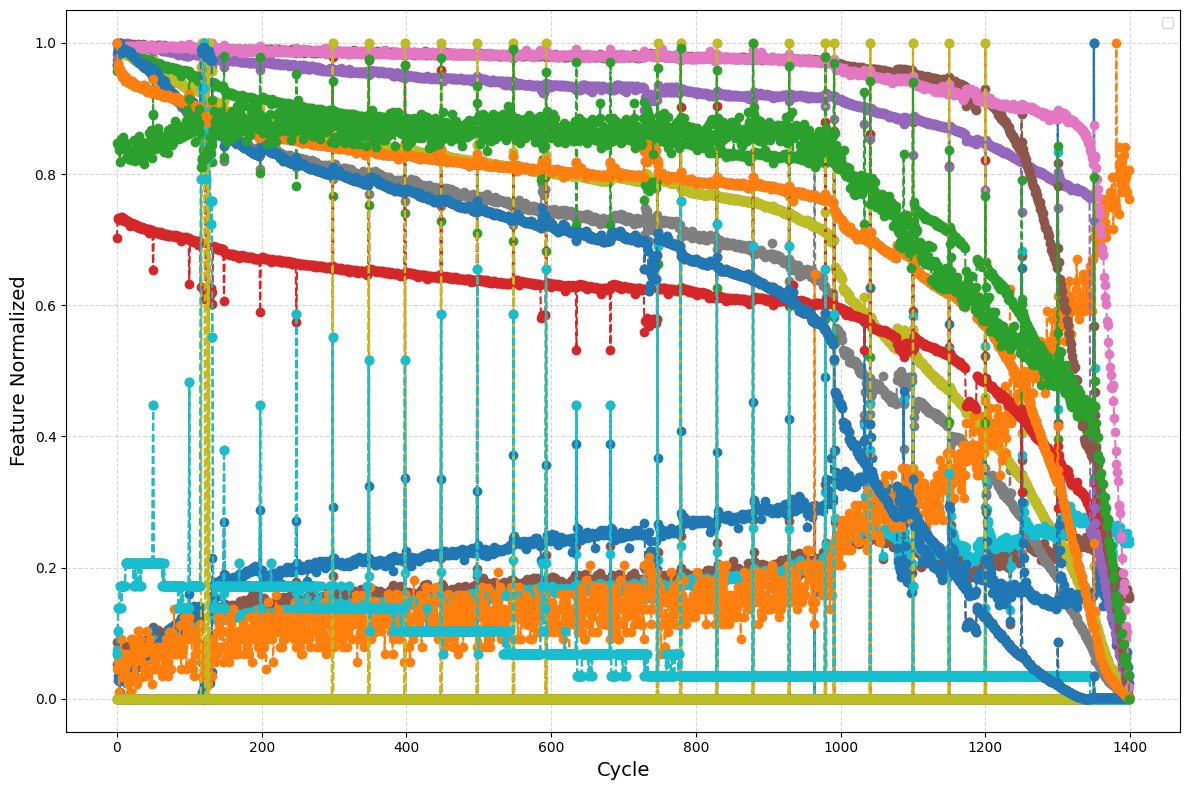

In [46]:
# 특징 데이터 합치고 정규화 
full_set_ch = np.column_stack((TIECVD_ch, CCtime_ch, MVF_ch, CCarea_ch, CVtime_ch, CVarea_ch, U0m10_ch, VIECTD_ch, Partialcap_ch))

scaler = MinMaxScaler()
full_set_ch_normalized = scaler.fit_transform(full_set_ch)

plt.figure(figsize=(12, 8))
plt.plot(full_set_ch_normalized, marker='o', linestyle='--')
plt.xlabel('Cycle', fontsize=14)
plt.ylabel('Feature Normalized', fontsize=14)
plt.legend(fontsize=10, loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 상관 분석 기반 인자 제거 및 인자간 상관분석 기반 인자제거(다중 공선성) 

In [47]:
# numpy 배열을 pandas DataFrame으로 변환
column_names = [f'Feature{i+1}' for i in range(full_set_ch_normalized.shape[1] - 1)] + ['SOH']
full_set_ch_normalized_df = pd.DataFrame(full_set_ch_normalized, columns=column_names)

# Feature와 SOH 간의 피어슨 상관 분석
correlation_with_SOH = full_set_ch_normalized_df.corr()['SOH'].drop('SOH')

# 상관계수 결과를 표로 나타내기
correlation_with_SOH_table = correlation_with_SOH.to_frame(name='Pearson Correlation with SOH')
print("Correlation with SOH:")
print(correlation_with_SOH_table)


# 상관계수 절대값이 0.9 이하인 Feature 제거
features_to_keep = correlation_with_SOH[correlation_with_SOH.abs() > 0.9].index.tolist()
if features_to_keep:
    full_set_ch_filtered = full_set_ch_normalized_df[features_to_keep]
    
print(features_to_keep)
print(len(features_to_keep))

Correlation with SOH:
           Pearson Correlation with SOH
Feature1                            NaN
Feature2                       0.106534
Feature3                       0.339521
Feature4                       0.858498
Feature5                       0.946008
Feature6                      -0.308634
Feature7                       0.930895
Feature8                       0.892831
Feature9                       0.930895
Feature10                     -0.529282
Feature11                      0.325354
Feature12                     -0.942980
Feature13                      0.924259
Feature14                      0.918504
Feature15                      0.852795
Feature16                      0.895368
Feature17                      0.836581
Feature18                           NaN
Feature19                      0.106536
Feature20                      0.339521
Feature21                      0.858498
Feature22                      0.946007
['Feature5', 'Feature7', 'Feature9', 'Feature12', 'Feature

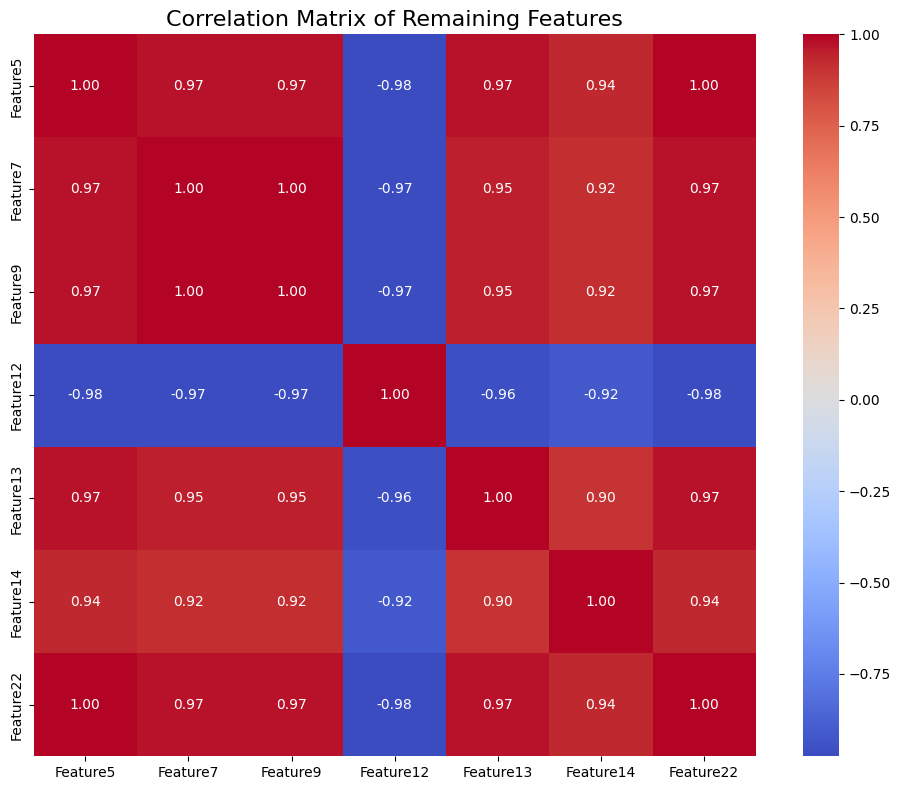

In [48]:
# 3. 남은 Feature끼리의 상관 분석
feature_correlation = full_set_ch_filtered.corr()

# 4. 상관 행렬 시각화
plt.figure(figsize=(10, 8))
sns.heatmap(feature_correlation, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('Correlation Matrix of Remaining Features', fontsize=16)
plt.tight_layout()
plt.show()

Removed features: ['Feature9', 'Feature22']
Remaining features after removal: ['Feature5', 'Feature7', 'Feature12', 'Feature13', 'Feature14']


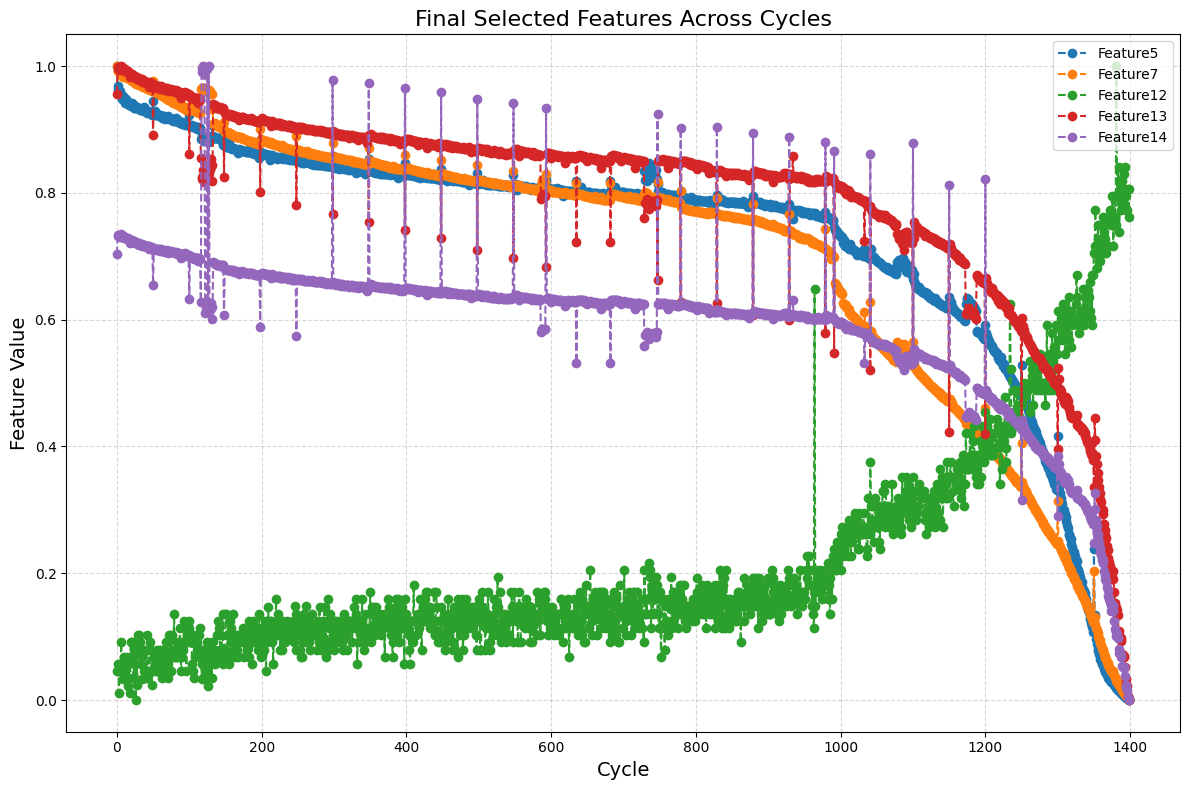

In [49]:
# 제거할 피처 목록
features_to_drop = ['Feature9', 'Feature22']

# 피처 제거
full_set_ch_filtered_reduced = full_set_ch_filtered.drop(columns=features_to_drop)

# 결과 출력
print(f"Removed features: {features_to_drop}")
print(f"Remaining features after removal: {full_set_ch_filtered_reduced.columns.tolist()}")

plt.figure(figsize=(12, 8))

for column in full_set_ch_filtered_reduced.columns:
    plt.plot(full_set_ch_filtered_reduced[column], marker='o', linestyle='--', label=column)

plt.xlabel('Cycle', fontsize=14)
plt.ylabel('Feature Value', fontsize=14)
plt.title('Final Selected Features Across Cycles', fontsize=16)
plt.legend(fontsize=10, loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## PCA 적용 분산 90% 이상 설명시

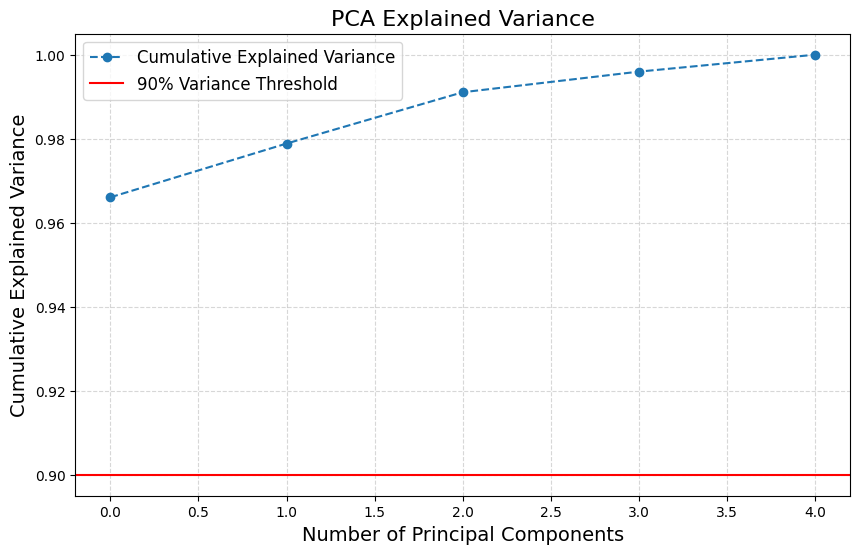

Number of principal components explaining at least 90% variance: 1
Final Feature Set Shape: (1400, 1)


In [50]:
# PCA 적용
pca = PCA()
pca_result = pca.fit_transform(full_set_ch_filtered_reduced)

# 고유값과 기여율 계산
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

# 누적 기여율 시각화
plt.figure(figsize=(10, 6))
plt.plot(cumulative_explained_variance, marker='o', linestyle='--', label='Cumulative Explained Variance')
plt.axhline(y=0.9, color='r', linestyle='-', label='90% Variance Threshold')
plt.xlabel('Number of Principal Components', fontsize=14)
plt.ylabel('Cumulative Explained Variance', fontsize=14)
plt.title('PCA Explained Variance', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# 90% 이상 설명하는 최소 PC 개수
num_components = np.argmax(cumulative_explained_variance >= 0.9)

if num_components == 0:
    num_components = 1  # 최소 1개의 PC 선택
    
print(f"Number of principal components explaining at least 90% variance: {num_components}")

# 선택된 PC 기반 최종 Feature Set 구성
final_features = pd.DataFrame(pca_result[:, :num_components], columns=[f'PC{i+1}' for i in range(num_components)])
print(f"Final Feature Set Shape: {final_features.shape}")

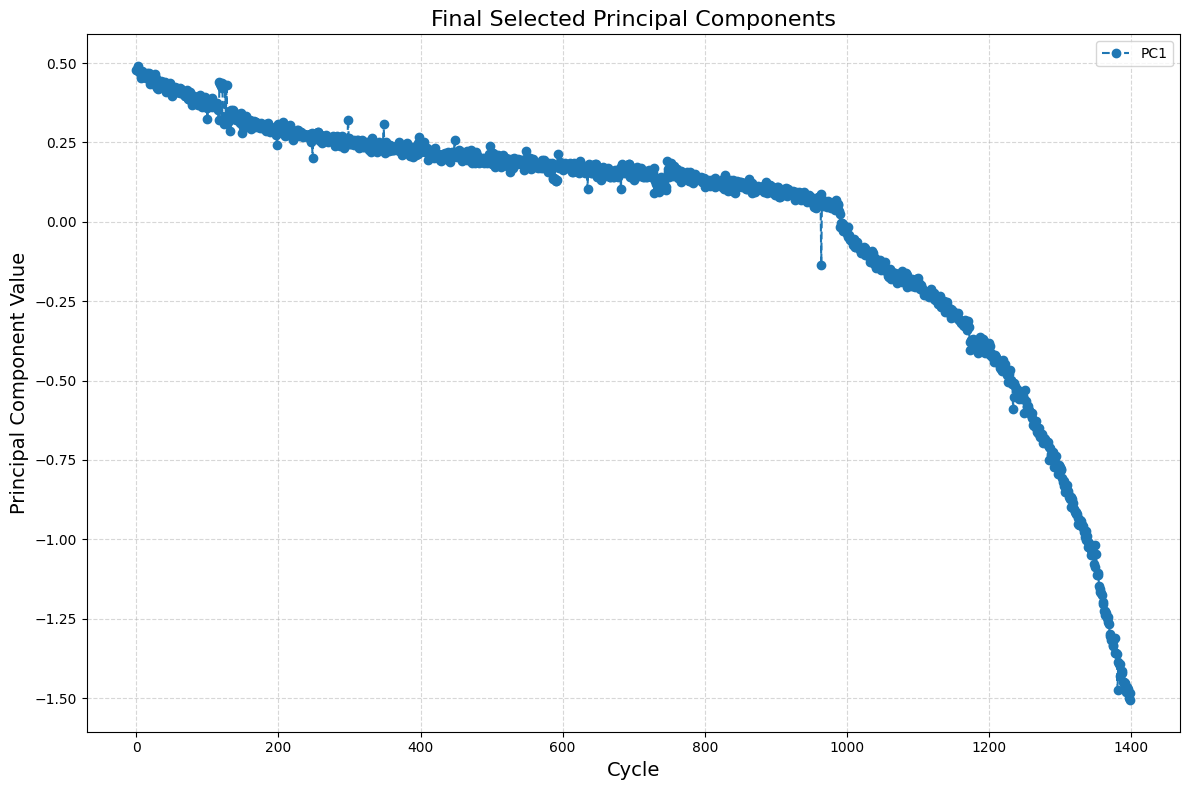

In [51]:
plt.figure(figsize=(12, 8))

for column in final_features.columns:
    plt.plot(final_features[column], marker='o', linestyle='--', label=column)

plt.xlabel('Cycle', fontsize=14)
plt.ylabel('Principal Component Value', fontsize=14)
plt.title('Final Selected Principal Components', fontsize=16)
plt.legend(fontsize=10, loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [52]:
# 최종 데이터 셋 저장
dataset = np.column_stack((final_features, SOH_normalized)) # 최종 Fullset 데이터 추출 (RUL 모델의 input)

# 저장 경로 설정
save_path = "dataset_for_AI.csv"

# CSV 파일로 저장
np.savetxt(save_path, dataset, delimiter=',', header=','.join(final_features.columns.tolist() + ['SOH']), comments='', fmt='%f')

print(f"Dataset successfully saved to {save_path}")

Dataset successfully saved to dataset_for_AI.csv


## Step 3 인공지능 파트 시작 

In [53]:
# 데이터 불러오기
data_path = "dataset_for_AI.csv"
data = pd.read_csv(data_path)

label = data.iloc[:, -1]
feature = data.iloc[:, :-1]
label = np.array(label).reshape(-1, 1)
print(f"feature shape = {feature.shape}, target={label.shape}")
print(feature, label)

feature shape = (1400, 1), target=(1400, 1)
           PC1
0     0.477860
1     0.482586
2     0.476575
3     0.490803
4     0.478454
...        ...
1395 -1.478591
1396 -1.471557
1397 -1.499975
1398 -1.483927
1399 -1.506031

[1400 rows x 1 columns] [[1.      ]
 [0.998661]
 [0.998326]
 ...
 [0.004021]
 [0.002343]
 [0.      ]]


In [54]:
# 학습 및 테스트 데이터 분할 (70% 학습, 30% 테스트)
total_samples = len(feature)

train_ratio = 0.7  # 학습 데이터 비율 

train_samples = int(total_samples * train_ratio)
test_samples = total_samples - train_samples

# 데이터 나누기
x_train = feature[:train_samples]
y_train = label[:train_samples]
x_test = feature[train_samples:]
y_test = label[train_samples:]

In [55]:
print(label.shape)
print(feature.shape)

(1400, 1)
(1400, 1)


In [56]:
# 시계열 데이터 셋 생성 함수 정의
def make_dataset(data, label, time_step):
    feature_list = []
    label_list = []
    for i in range(len(data) - time_step):
        feature_list.append(np.array(data[i:i+time_step]))
        label_list.append(np.array(label[i+time_step]))
    return np.array(feature_list), np.array(label_list)

In [57]:
# 학습 및 검증 데이터 셋 생성
train_feature, train_label = make_dataset(x_train, y_train, 10)
test_feature, test_label = make_dataset(x_test, y_test, 10)

x_train, x_valid, y_train, y_valid = train_test_split(train_feature, train_label, test_size=0.2)

print(train_feature.shape)
print(train_label.shape)
print(x_train.shape)
print(x_valid.shape)
print(y_train.shape)
print(y_valid.shape)

(969, 10, 1)
(969, 1)
(775, 10, 1)
(194, 10, 1)
(775, 1)
(194, 1)


## 모델 구조 설계

In [58]:
# RNN 모델 생성 함수
def build_rnn_model(units, dropout_rate, learning_rate, activation):
    model = Sequential()
    model.add(SimpleRNN(units, return_sequences=False, input_shape=train_feature.shape[1:]))
    model.add(Dropout(dropout_rate))
    model.add(Dense(1, activation=activation))
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(loss='mse', optimizer=optimizer, metrics=['mse'])
    return model

In [59]:
# LSTM 모델 생성 함수
def build_lstm_model(units, dropout_rate, learning_rate, activation):
    model = Sequential()
    model.add(LSTM(units, return_sequences=False, input_shape=train_feature.shape[1:]))
    model.add(Dropout(dropout_rate))
    model.add(Dense(1, activation))
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(loss='mse', optimizer=optimizer, metrics=['mse'])
    return model

In [60]:
# GRU 모델 생성
def build_gru_model(units, dropout_rate, learning_rate, activation): # 베이지안 최적화로 진행할 하이퍼 파라미터
    model = Sequential()
    model.add(GRU(units, return_sequences=False, input_shape=train_feature.shape[1:]))
    model.add(Dropout(dropout_rate))
    model.add(Dense(1, activation))
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(loss='mse', optimizer=optimizer, metrics=['mse'])
    return model

## 먼저 RNN기반으로 그냥 일반 손튜닝 하는과정

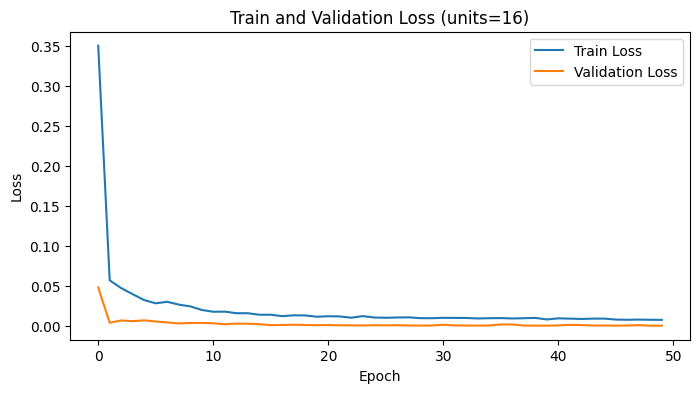

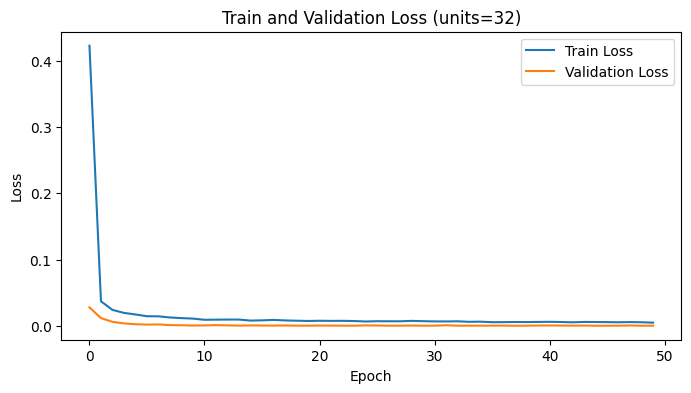

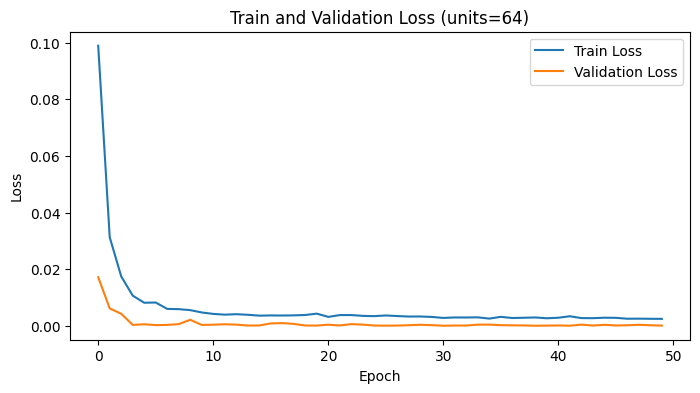

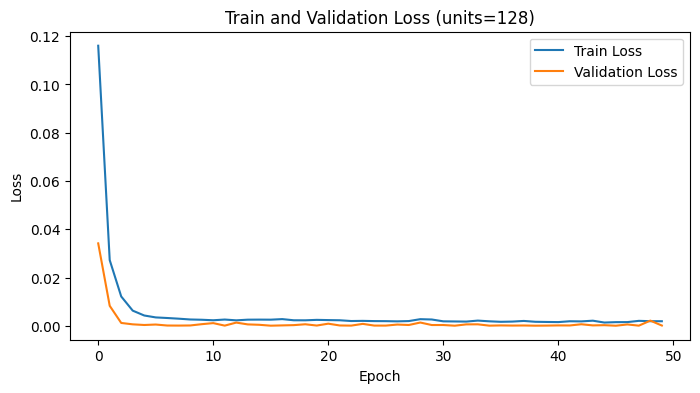

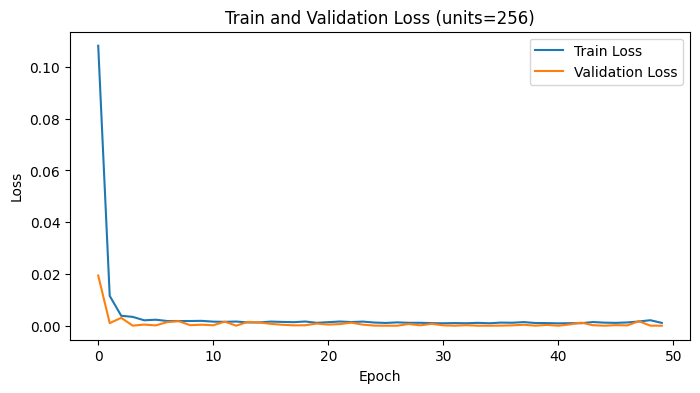

In [61]:
# 1단계: units 변경
unit_list = [16, 32, 64, 128, 256]
fixed_dropout = 0.2
fixed_learning_rate = 0.001
fixed_activation = 'linear'

for units in unit_list:
    model = ()
    model = build_rnn_model(units, fixed_dropout, fixed_learning_rate, fixed_activation)
    history = model.fit(
        x_train, y_train,
        validation_data=(x_valid, y_valid),
        epochs=50,
        batch_size=32,
        verbose=0
    )
    plt.figure(figsize=(8, 4))
    plt.plot(history.history['loss'], label="Train Loss")
    plt.plot(history.history['val_loss'], label="Validation Loss")
    plt.title(f'Train and Validation Loss (units={units})')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

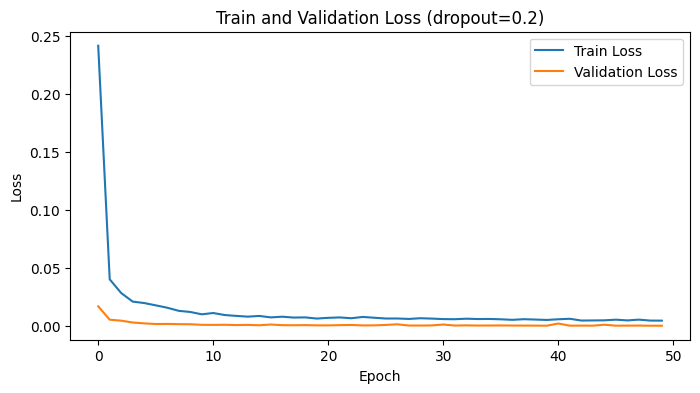

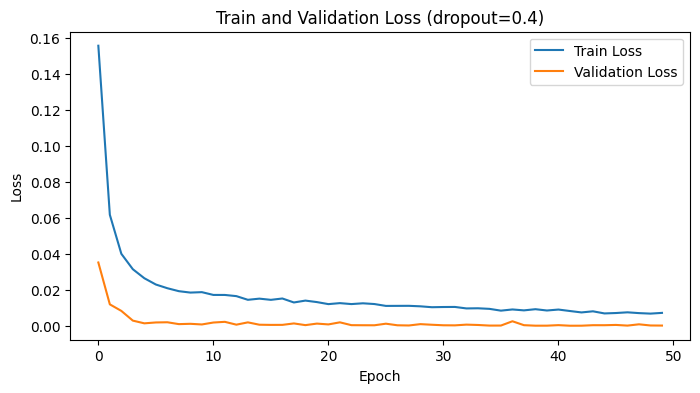

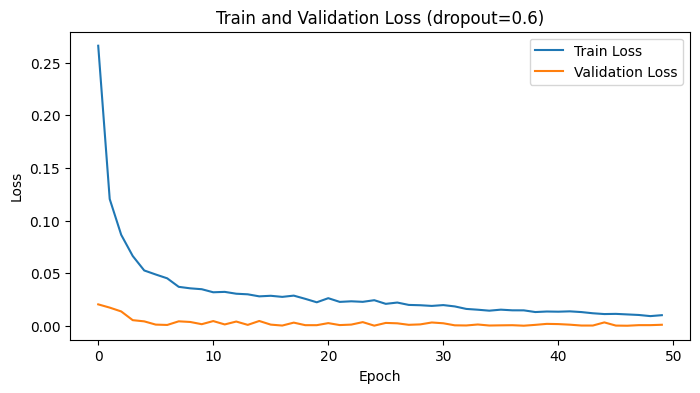

In [62]:
# 2단계: dropout_rate 변경
dropout_list = [0.2, 0.4, 0.6]
fixed_units = 32
fixed_learning_rate = 0.001
fixed_activation = 'linear'

for dropout_rate in dropout_list:
    model = ()
    model = build_rnn_model(fixed_units, dropout_rate, fixed_learning_rate, fixed_activation)
    history = model.fit(
        x_train, y_train,
        validation_data=(x_valid, y_valid),
        epochs=50,
        batch_size=32,
        verbose=0
    )
    plt.figure(figsize=(8, 4))
    plt.plot(history.history['loss'], label="Train Loss")
    plt.plot(history.history['val_loss'], label="Validation Loss")
    plt.title(f'Train and Validation Loss (dropout={dropout_rate})')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

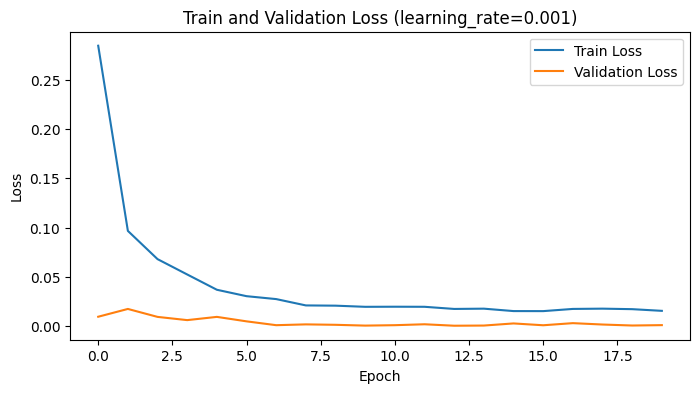

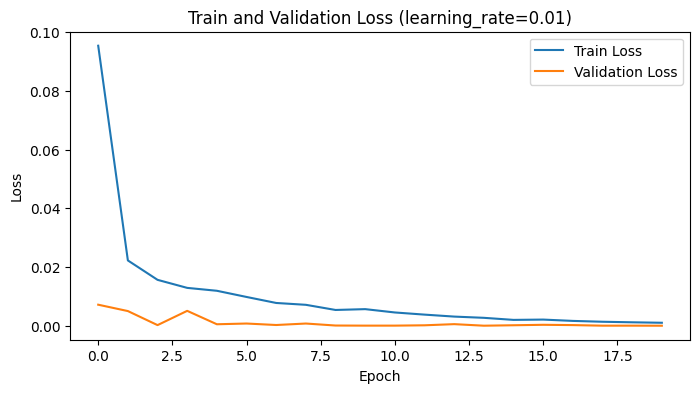

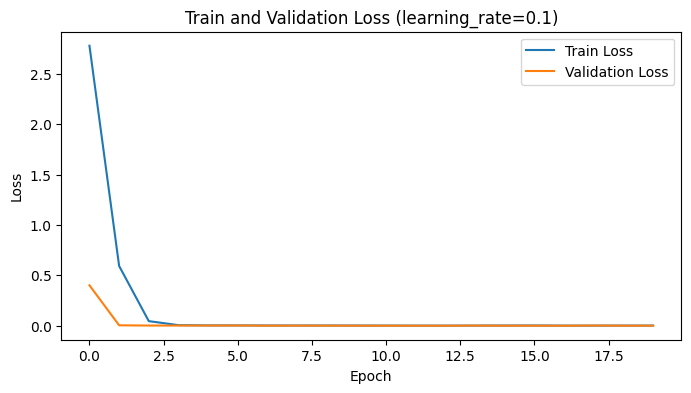

In [63]:
# 3단계: learning_rate 변경
learning_rate_list = [0.001, 0.01, 0.1]
fixed_units = 32
fixed_dropout = 0.4
fixed_activation = 'linear'

for learning_rate in learning_rate_list:
    model = ()
    model = build_rnn_model(fixed_units, fixed_dropout, learning_rate, fixed_activation)
    history = model.fit(
        x_train, y_train,
        validation_data=(x_valid, y_valid),
        epochs=20,
        batch_size=32,
        verbose=0
    )
    plt.figure(figsize=(8, 4))
    plt.plot(history.history['loss'], label="Train Loss")
    plt.plot(history.history['val_loss'], label="Validation Loss")
    plt.title(f'Train and Validation Loss (learning_rate={learning_rate})')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

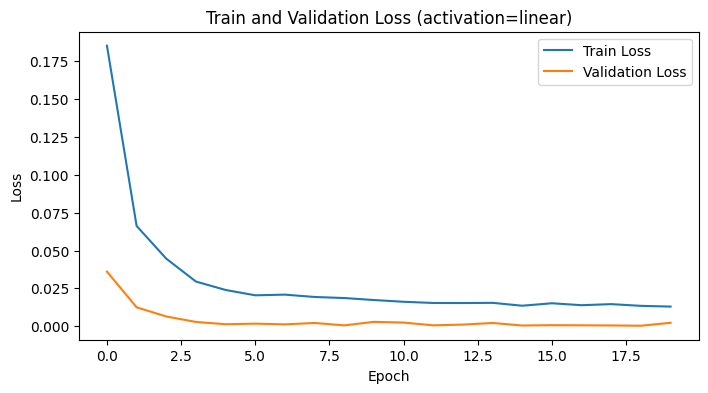

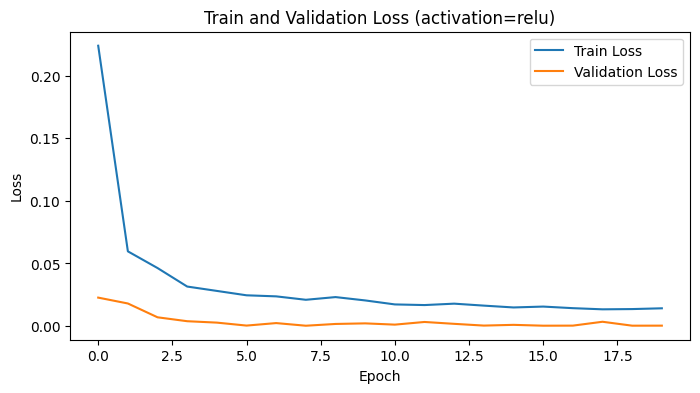

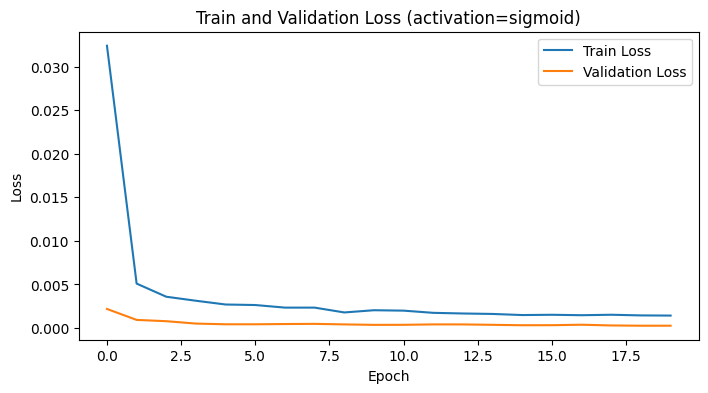

In [64]:
# 4단계: activation 변경
activation_list = ['linear', 'relu', 'sigmoid']
fixed_units = 32
fixed_dropout = 0.4
fixed_learning_rate = 0.001


for activation in activation_list:
    model = ()
    model = build_rnn_model(fixed_units, fixed_dropout, fixed_learning_rate, activation)
    history = model.fit(
        x_train, y_train,
        validation_data=(x_valid, y_valid),
        epochs=20,
        batch_size=32,
        verbose=0
    )
    plt.figure(figsize=(8, 4))
    plt.plot(history.history['loss'], label="Train Loss")
    plt.plot(history.history['val_loss'], label="Validation Loss")
    plt.title(f'Train and Validation Loss (activation={activation})')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

Training with batch_size=16, epochs=10


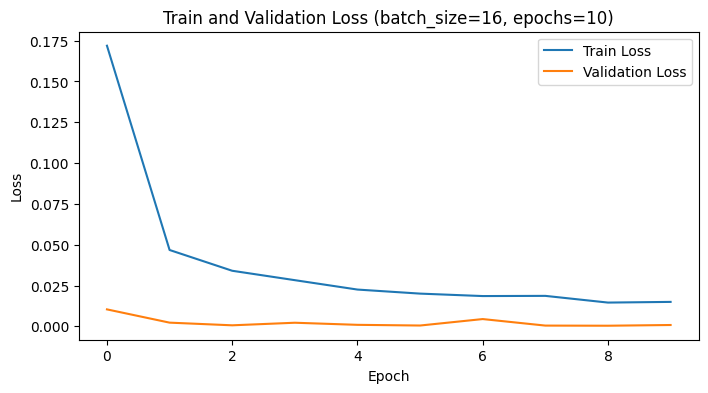

Training with batch_size=16, epochs=20


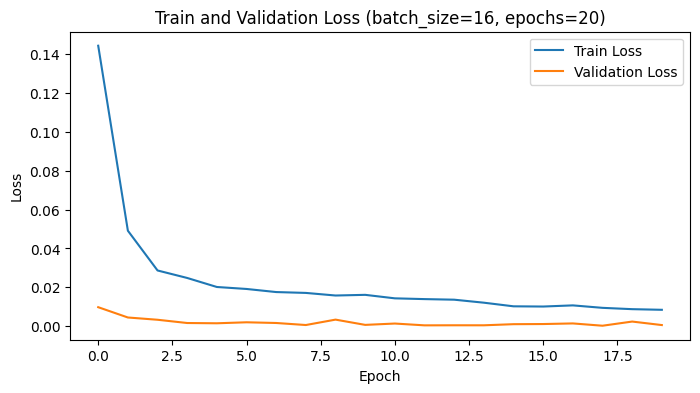

Training with batch_size=16, epochs=50


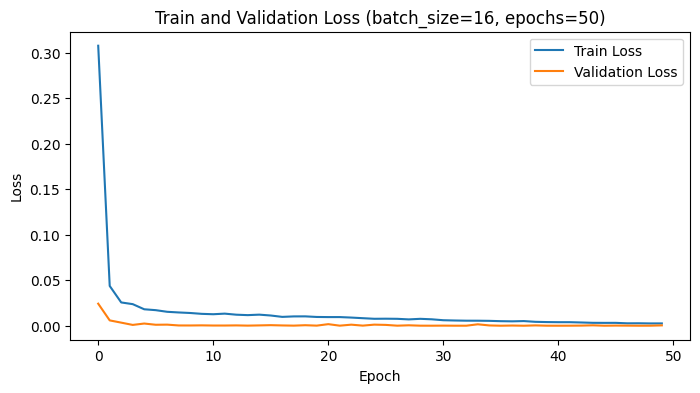

Training with batch_size=32, epochs=10


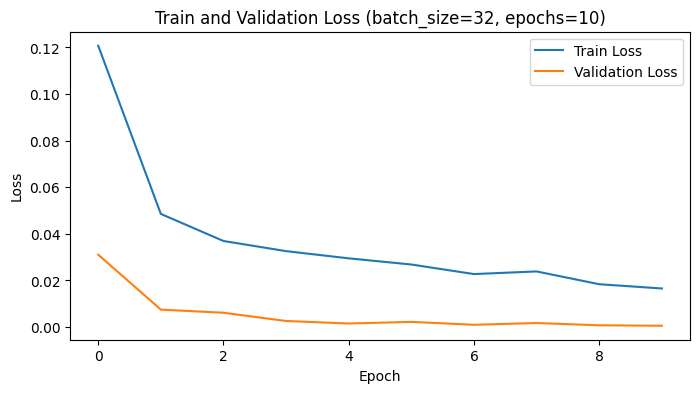

Training with batch_size=32, epochs=20


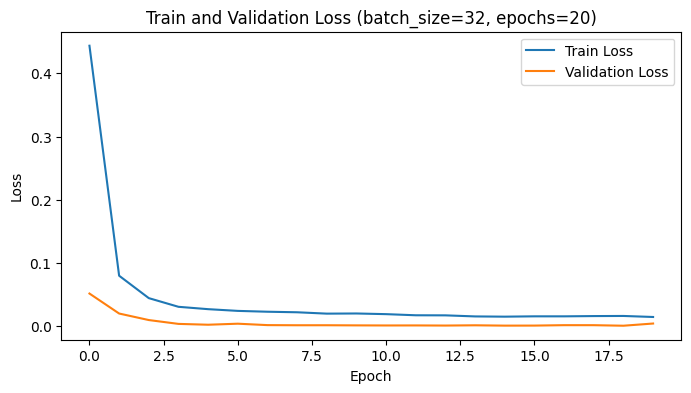

Training with batch_size=32, epochs=50


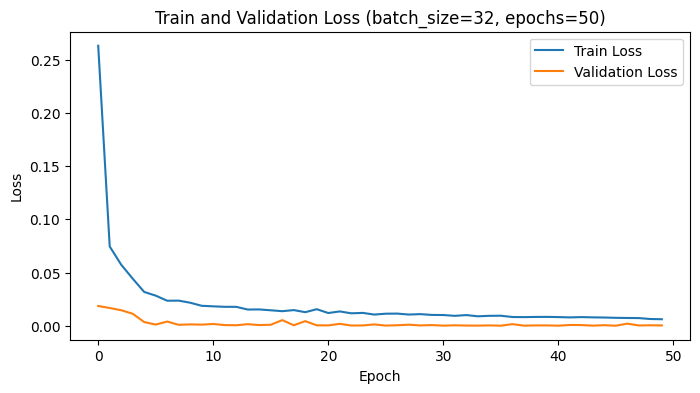

Training with batch_size=64, epochs=10


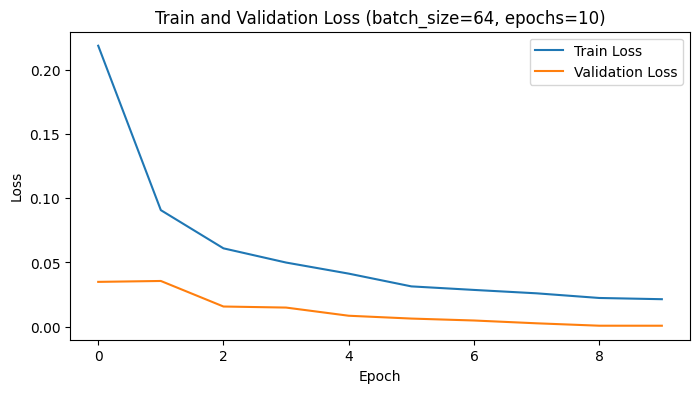

Training with batch_size=64, epochs=20


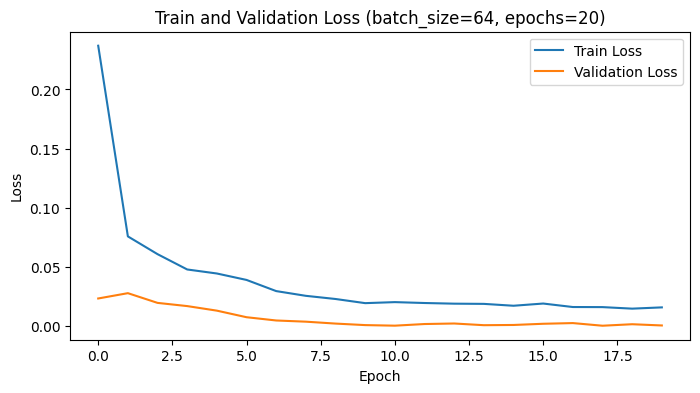

Training with batch_size=64, epochs=50


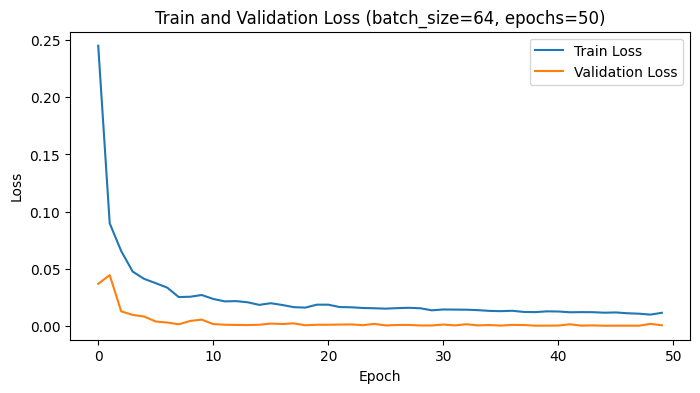

In [65]:
# 고정된 조건
fixed_units = 32
fixed_dropout = 0.4
fixed_learning_rate = 0.001
fixed_activation = 'relu'

# 실험할 batch_size와 epochs 설정
batch_sizes = [16, 32, 64]  # 배치 크기
epoch_values = [10, 20, 50]  # 에폭 수

# 결과 저장 및 그래프 그리기
for batch_size in batch_sizes:
    for epochs in epoch_values:
        print(f"Training with batch_size={batch_size}, epochs={epochs}")
        model = ()
        model = build_rnn_model(fixed_units, fixed_dropout, fixed_learning_rate, fixed_activation)
        
        # 학습
        history = model.fit(
            x_train, y_train,
            validation_data=(x_valid, y_valid),
            epochs=epochs,
            batch_size=batch_size,
            verbose=0
        )
        
        # 그래프 그리기
        plt.figure(figsize=(8, 4))
        plt.plot(history.history['loss'], label="Train Loss")
        plt.plot(history.history['val_loss'], label="Validation Loss")
        plt.title(f'Train and Validation Loss (batch_size={batch_size}, epochs={epochs})')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.show()

Epoch 1/20
31/31 [==============================] - 1s 2ms/step - loss: 0.2664 - mse: 0.2664
Epoch 2/20
31/31 [==============================] - 0s 2ms/step - loss: 0.0686 - mse: 0.0686
Epoch 3/20
31/31 [==============================] - 0s 2ms/step - loss: 0.0470 - mse: 0.0470
Epoch 4/20
31/31 [==============================] - 0s 2ms/step - loss: 0.0325 - mse: 0.0325
Epoch 5/20
31/31 [==============================] - 0s 2ms/step - loss: 0.0252 - mse: 0.0252
Epoch 6/20
31/31 [==============================] - 0s 2ms/step - loss: 0.0233 - mse: 0.0233
Epoch 7/20
31/31 [==============================] - 0s 2ms/step - loss: 0.0210 - mse: 0.0210
Epoch 8/20
31/31 [==============================] - 0s 2ms/step - loss: 0.0213 - mse: 0.0213
Epoch 9/20
31/31 [==============================] - 0s 2ms/step - loss: 0.0172 - mse: 0.0172
Epoch 10/20
31/31 [==============================] - 0s 2ms/step - loss: 0.0153 - mse: 0.0153
Epoch 11/20
31/31 [==============================] - 0s 2ms/step - lo

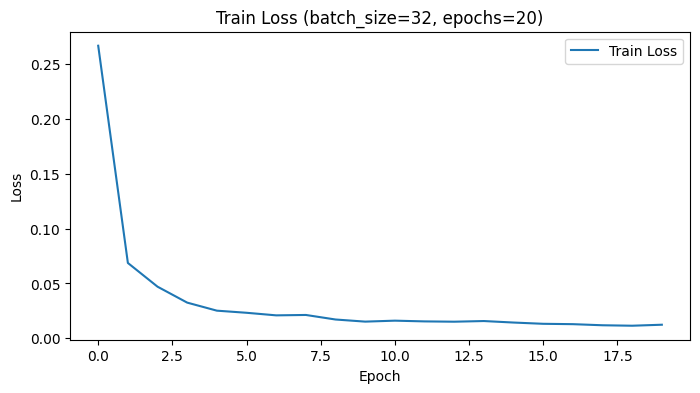

Loaded scaling parameters: x_min=18.841691120404445, x_max=100.0
13/13 [==============================] - 0s 1ms/step
Model Evaluation Results:
Mean Squared Error (MSE): 201.6682
Mean Absolute Error (MAE): 12.1820
Root Mean Squared Error (RMSE): 14.2010
R² (R-squared): 0.1480


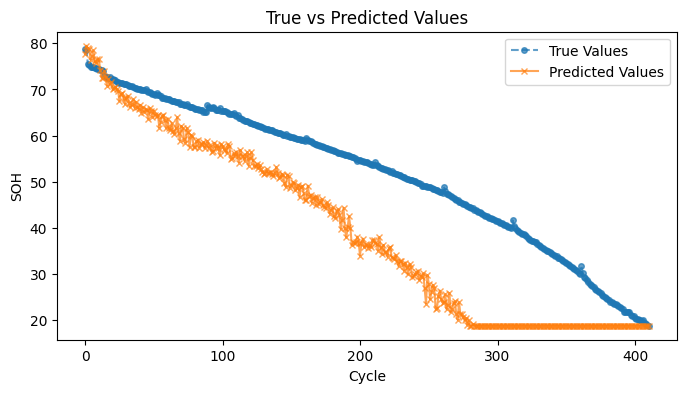

In [66]:
# 고정된 조건
fixed_units = 32
fixed_dropout = 0.4
fixed_learning_rate = 0.001
fixed_activation = 'relu'
batch_size = 32
epoch = 20

# 모델 학습
rnn_model = ()
rnn_model = build_rnn_model(fixed_units, fixed_dropout, fixed_learning_rate, fixed_activation)
history = rnn_model.fit(
    train_feature, train_label,
    epochs=epoch,
    batch_size=batch_size,
    verbose=1
)

# 학습 손실 및 검증 손실 그래프
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label="Train Loss")
plt.title(f"Train Loss (batch_size={batch_size}, epochs={epoch})")
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# JSON 파일에서 x_min, x_max 값 불러오기
with open('scaling_params.json', 'r') as f:
    scaling_params = json.load(f)

x_min = scaling_params['x_min']
x_max = scaling_params['x_max']
print(f"Loaded scaling parameters: x_min={x_min}, x_max={x_max}")


# 모델 평가
y_pred = rnn_model.predict(test_feature)

#역변환
origin = reverse_min_max_scaling(test_label,x_min,x_max)[:,0]
result = reverse_min_max_scaling(y_pred,x_min,x_max)[:,0]


mse = mean_squared_error(origin, result)
mae = mean_absolute_error(origin, result)
rmse = np.sqrt(mse)
r2 = r2_score(origin, result)

print("Model Evaluation Results:")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² (R-squared): {r2:.4f}")

# 결과 샘플 시각화
plt.figure(figsize=(8, 4))
plt.plot(origin, label="True Values", marker='o', linestyle='--', markersize=4, alpha=0.7)
plt.plot(result, label="Predicted Values", marker='x', linestyle='-', markersize=4, alpha=0.7)
plt.title("True vs Predicted Values")
plt.xlabel("Cycle")
plt.ylabel("SOH")
plt.legend()
plt.show()

## 베이시안 최적화 결과

In [67]:
# Bayesian 최적화 함수
def bayesian_optimization(units, dropout_rate, learning_rate, batch_size, model_type):
    units = int(units)  # 정수 변환
    batch_size = int(batch_size)  # 정수 변환
    fixed_activation = 'relu'
    # 모델 선택
    if model_type == 'rnn':
        model = build_rnn_model(units, dropout_rate, learning_rate, fixed_activation)
    elif model_type == 'gru':
        model = build_gru_model(units, dropout_rate, learning_rate, fixed_activation)
    elif model_type == 'lstm':
        model = build_lstm_model(units, dropout_rate, learning_rate, fixed_activation)
    else:
        raise ValueError(f"Invalid model_type: {model_type}. Choose 'rnn' or 'gru'.")
    
    # 모델 학습
    hist = model.fit(
        x_train, y_train,
        validation_data=(x_valid, y_valid),
        batch_size=batch_size,
        epochs=20,  # 에포크는 고정
        verbose=0
    )
    
    # 검증 손실(MSE)을 반환 (최소화가 목표)
    val_mse = hist.history['val_mse'][-1]
    
    # Loss 그래프 출력
    plt.figure(figsize=(8, 4))
    plt.plot(hist.history['loss'], label='Training Loss')
    plt.plot(hist.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.title(f"Loss Plot (Model Type: {model_type})")
    plt.show()
    
    return -val_mse  # BayesianOptimization은 최대화를 수행하므로 음수 반환


|   iter    |  target   | batch_... | dropou... | learni... |   units   |
-------------------------------------------------------------------------


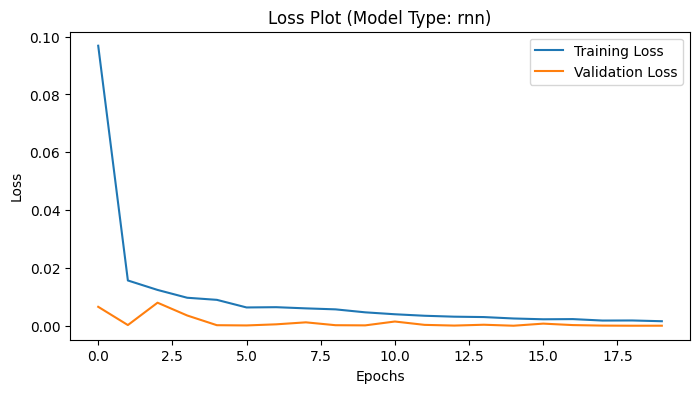

| 1         | -5.85e-05 | 26.47     | 0.4759    | 0.00732   | 83.05     |


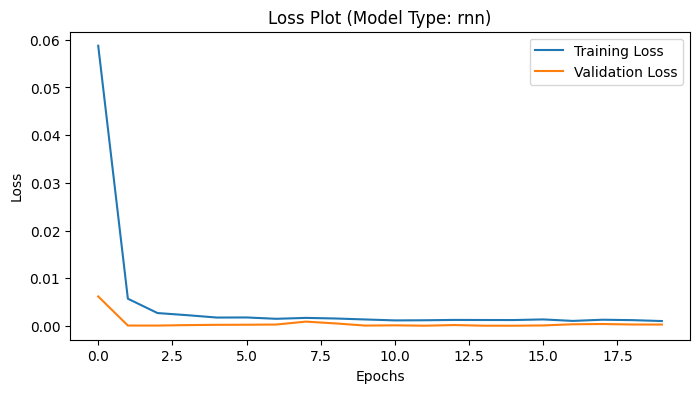

| 2         | -0.000274 | 13.36     | 0.08644   | 0.0005818 | 113.0     |


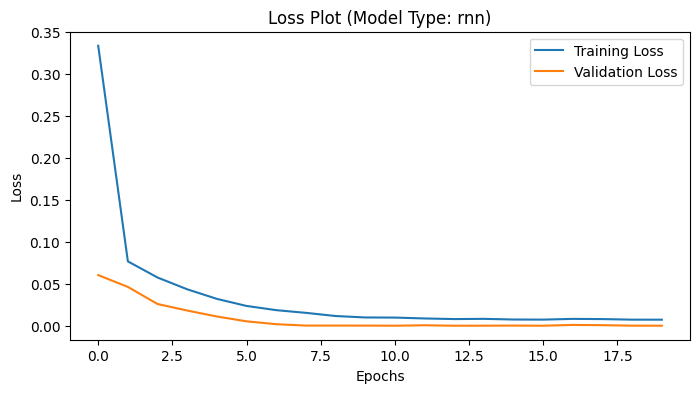

| 3         | -0.000129 | 40.07     | 0.357     | 0.0002068 | 124.6     |


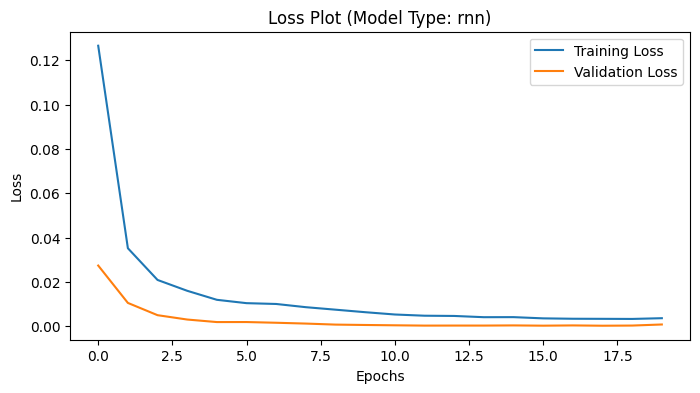

| 4         | -0.000736 | 53.95     | 0.114     | 0.001819  | 36.54     |


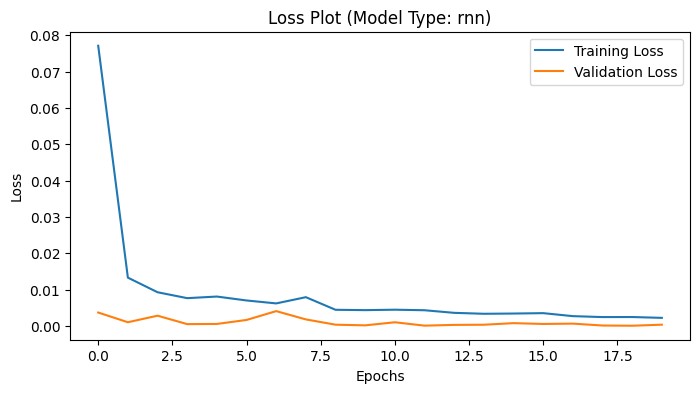

| 5         | -0.000333 | 22.25     | 0.2671    | 0.00432   | 48.62     |


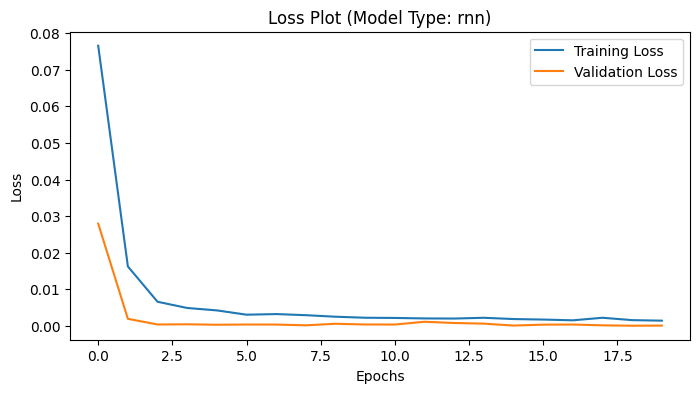

| 6         | -7.611e-0 | 40.71     | 0.07835   | 0.002922  | 57.03     |


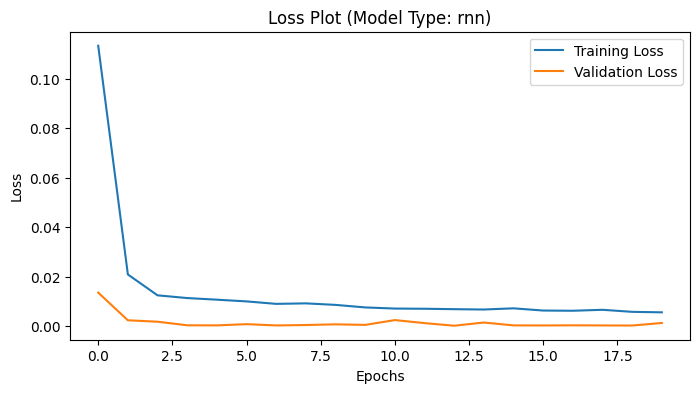

| 7         | -0.001317 | 31.36     | 0.3947    | 0.001998  | 73.59     |


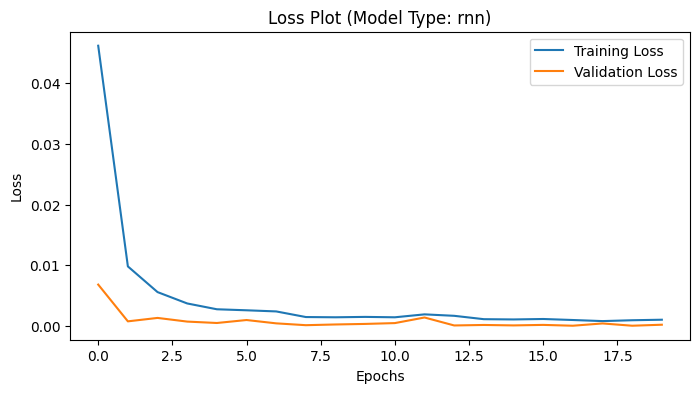

| 8         | -0.000221 | 39.54     | 0.03276   | 0.006076  | 35.1      |


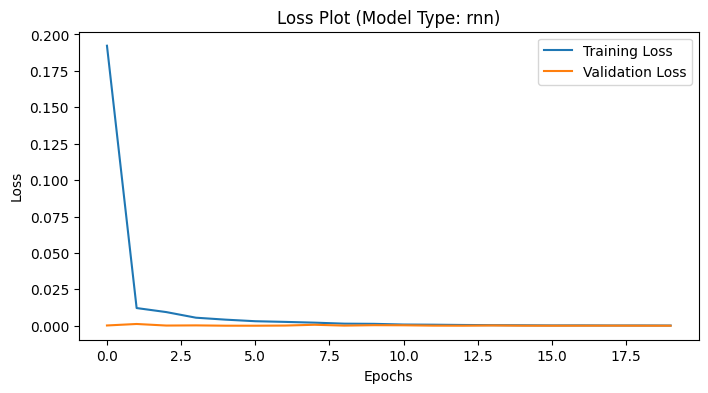

| 9         | -4.414e-0 | 7.903     | 0.475     | 0.009656  | 106.5     |


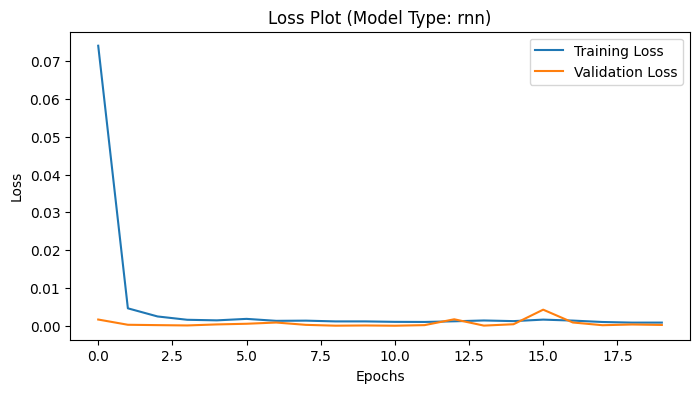

| 10        | -0.000232 | 22.28     | 0.05786   | 0.006843  | 65.3      |


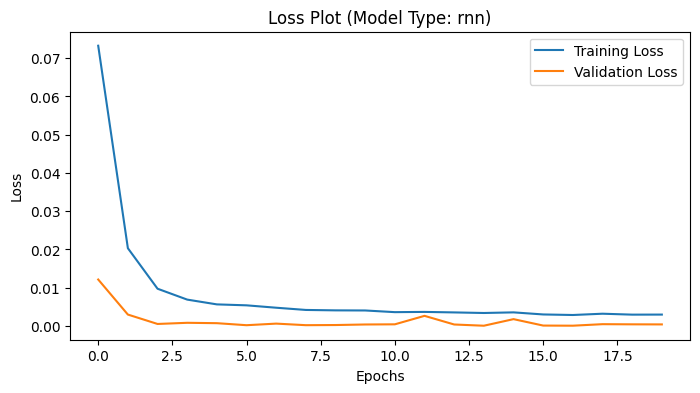

| 11        | -0.000405 | 11.32     | 0.2526    | 0.0003449 | 117.8     |


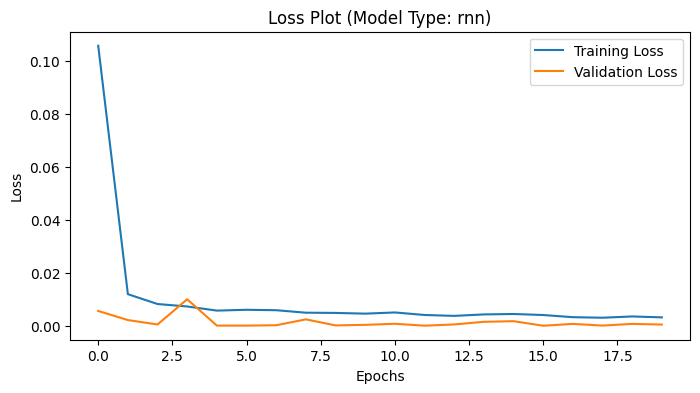

| 12        | -0.000490 | 19.53     | 0.3346    | 0.003118  | 74.25     |


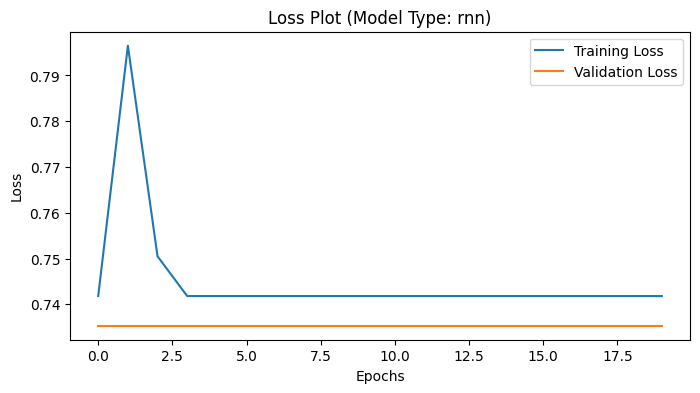

| 13        | -0.7353   | 36.8      | 0.1006    | 0.009696  | 102.8     |


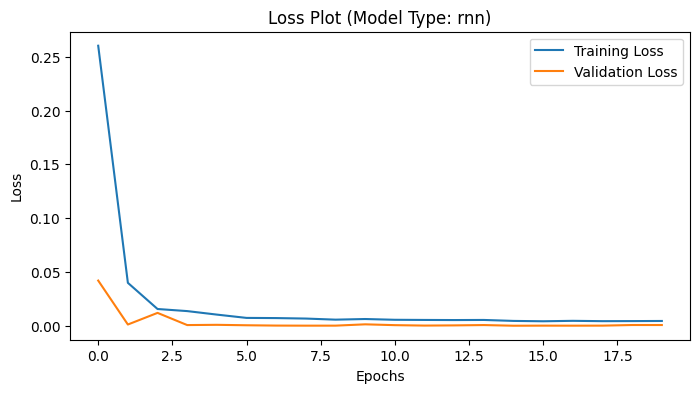

| 14        | -0.000721 | 60.37     | 0.4485    | 0.005979  | 119.2     |


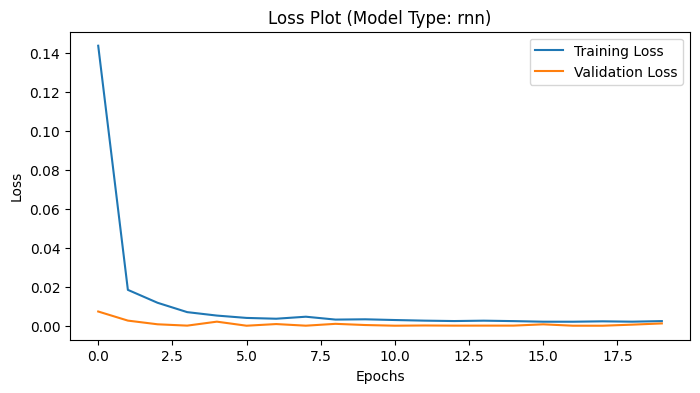

| 15        | -0.001239 | 9.31      | 0.106     | 0.0004532 | 52.44     |


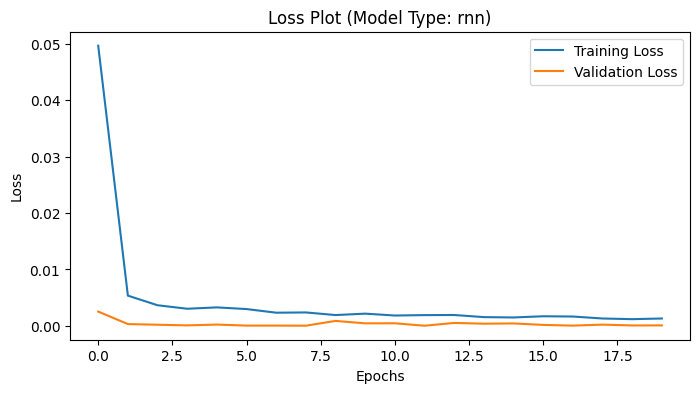

| 16        | -8.605e-0 | 27.32     | 0.143     | 0.008288  | 55.96     |


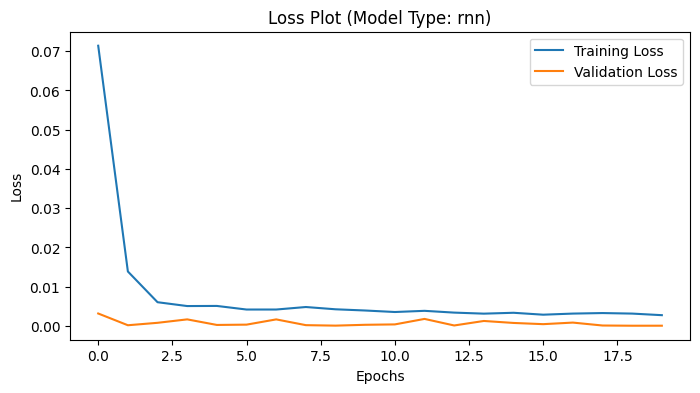

| 17        | -4.398e-0 | 20.86     | 0.2759    | 0.00141   | 105.8     |


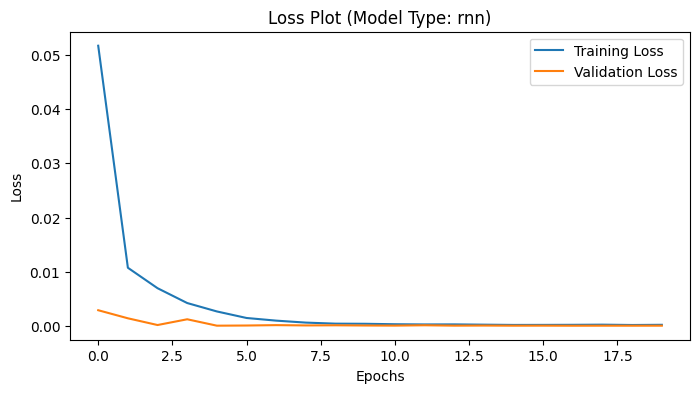

| 18        | -5.038e-0 | 8.473     | 0.4936    | 0.007723  | 38.26     |


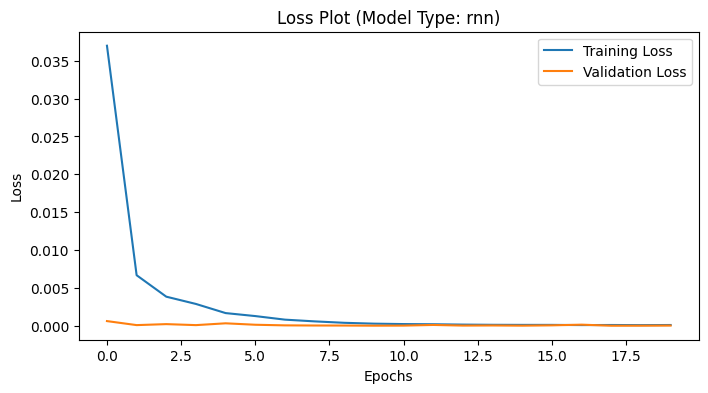

| 19        | -5.857e-0 | 4.331     | 0.4096    | 0.007069  | 97.65     |


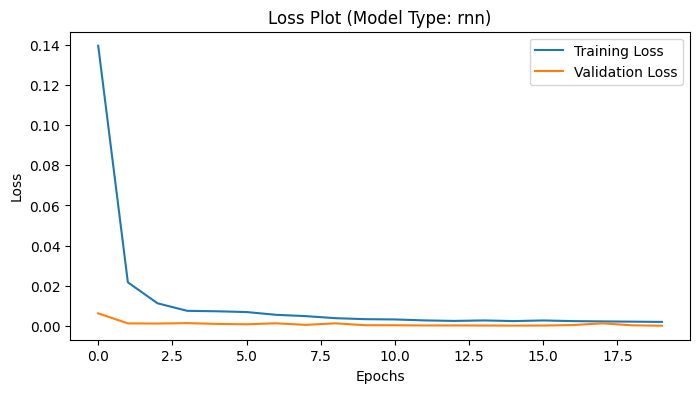

| 20        | -0.000136 | 50.28     | 0.04628   | 0.003585  | 28.98     |


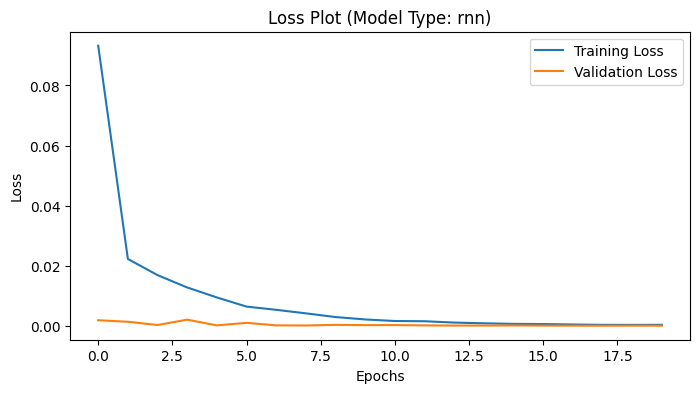

| 21        | -8.547e-0 | 20.86     | 0.361     | 0.008859  | 16.03     |


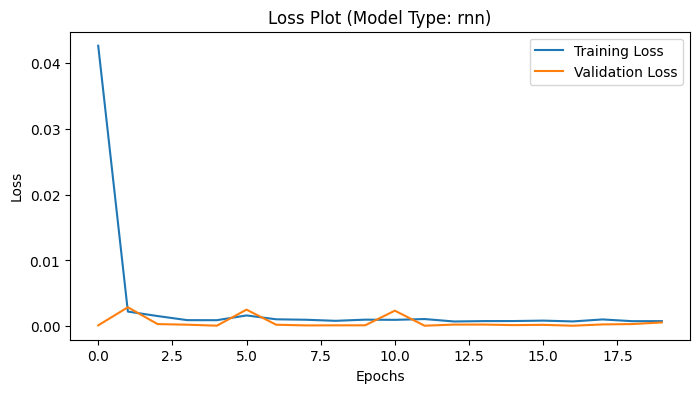

| 22        | -0.000554 | 12.08     | 0.06353   | 0.003512  | 115.3     |


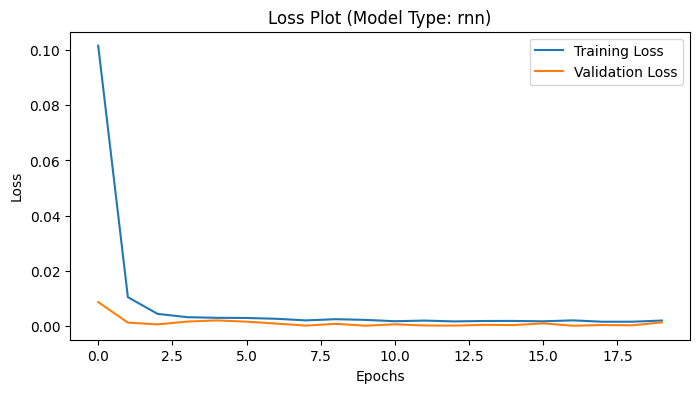

| 23        | -0.001259 | 63.77     | 0.1025    | 0.008142  | 63.11     |


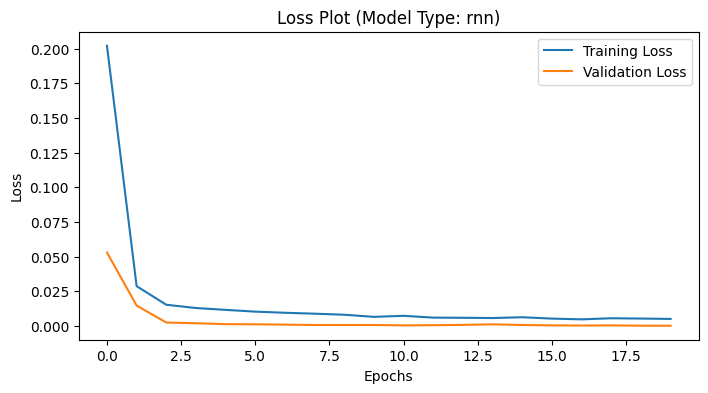

| 24        | -0.000124 | 62.69     | 0.06311   | 0.002775  | 16.01     |


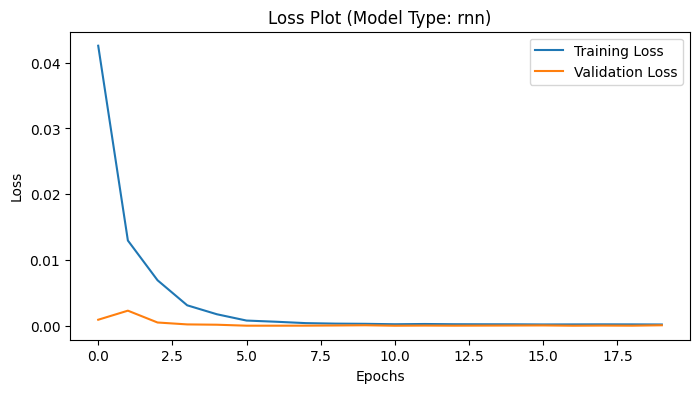

| 25        | -0.000105 | 4.224     | 0.4027    | 0.004607  | 19.32     |


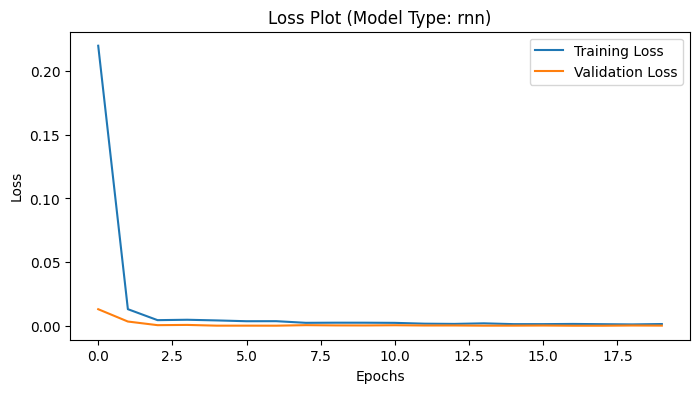

| 26        | -0.000203 | 39.42     | 0.01848   | 0.006397  | 16.06     |


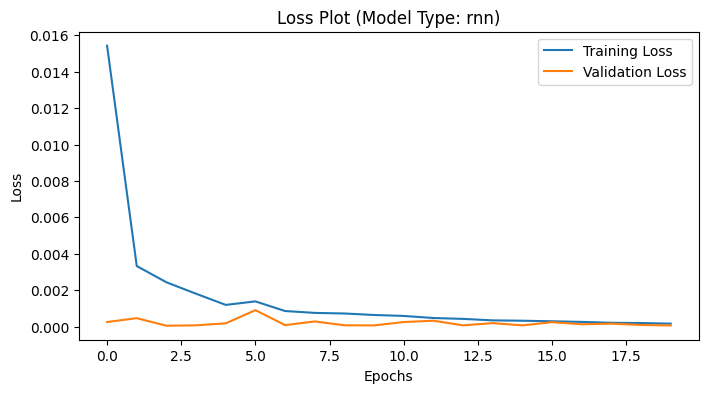

| 27        | -5.834e-0 | 4.07      | 0.1155    | 0.00535   | 79.24     |


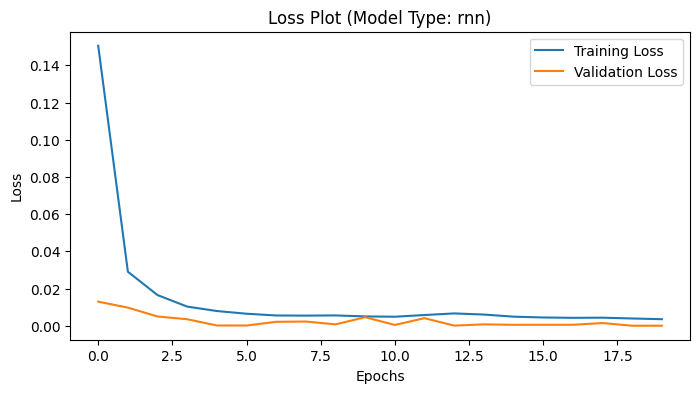

| 28        | -4.519e-0 | 63.67     | 0.2882    | 0.006357  | 81.83     |


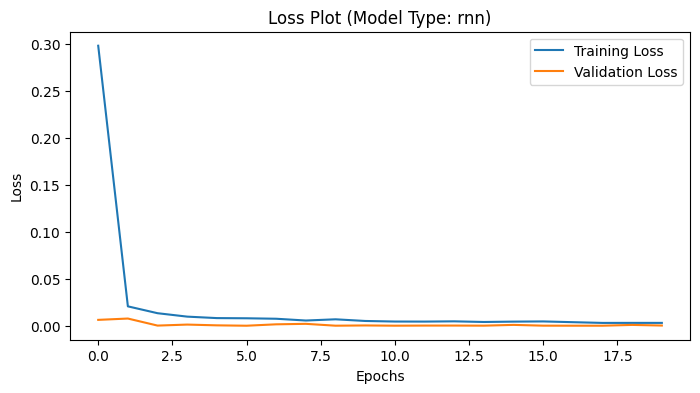

| 29        | -0.000259 | 26.04     | 0.4724    | 0.008145  | 128.0     |


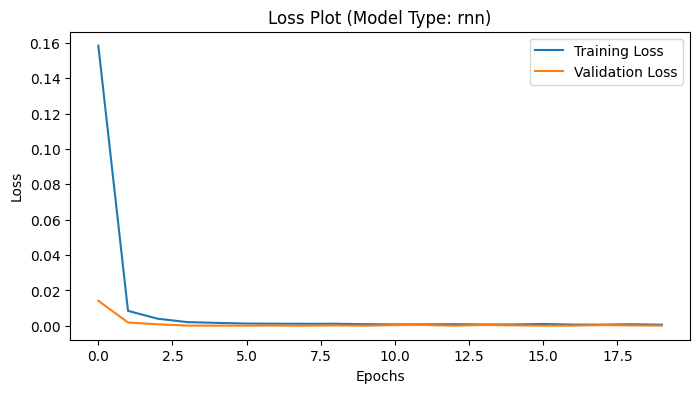

| 30        | -7.7e-05  | 63.82     | 0.0238    | 0.006036  | 48.16     |


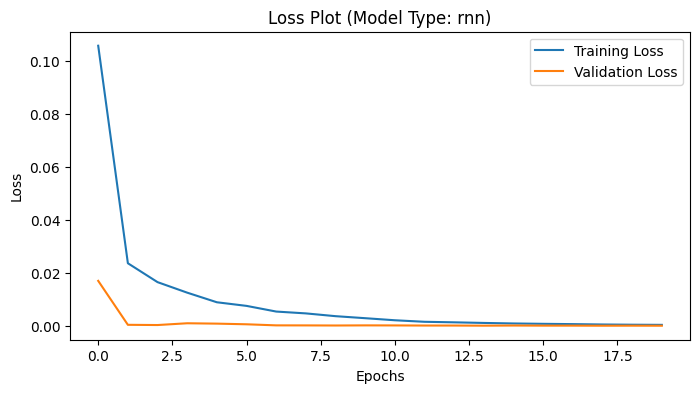

| 31        | -6.135e-0 | 23.32     | 0.483     | 0.008347  | 30.94     |


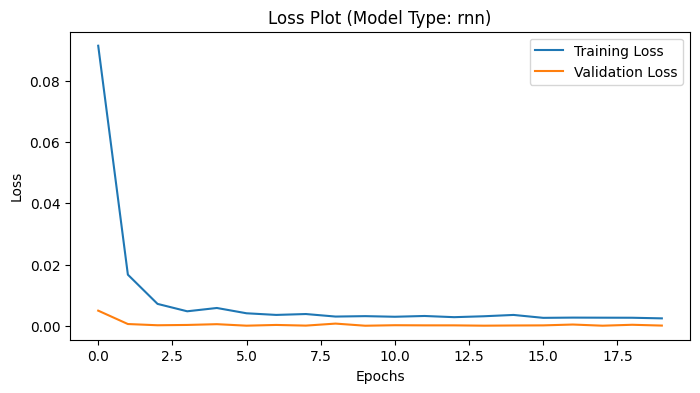

| 32        | -0.000125 | 49.88     | 0.1987    | 0.005592  | 71.33     |


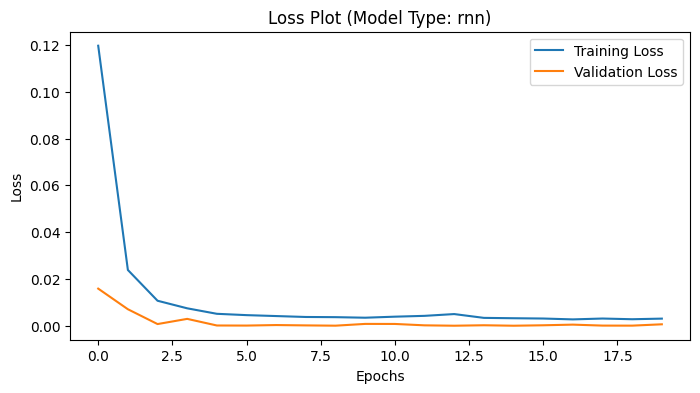

| 33        | -0.000645 | 53.03     | 0.3045    | 0.002579  | 127.9     |


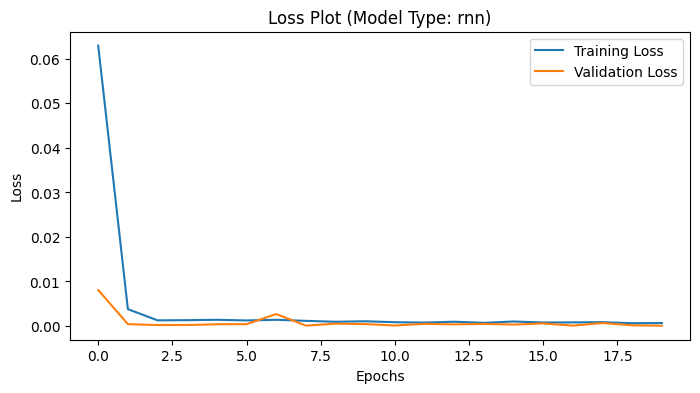

| 34        | -4.77e-05 | 15.06     | 0.06793   | 0.008631  | 91.17     |


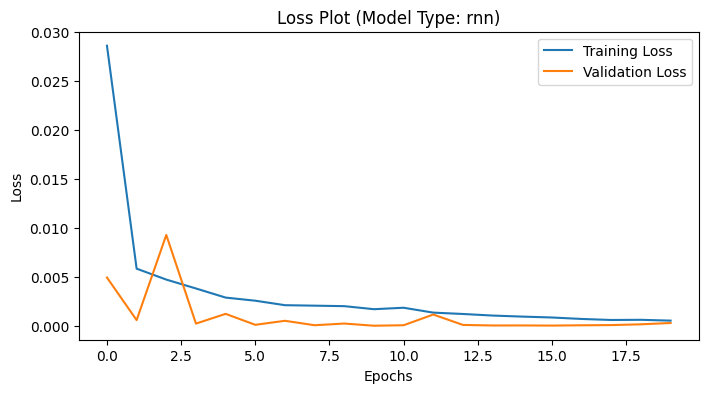

| 35        | -0.000317 | 4.014     | 0.1884    | 0.002327  | 66.42     |


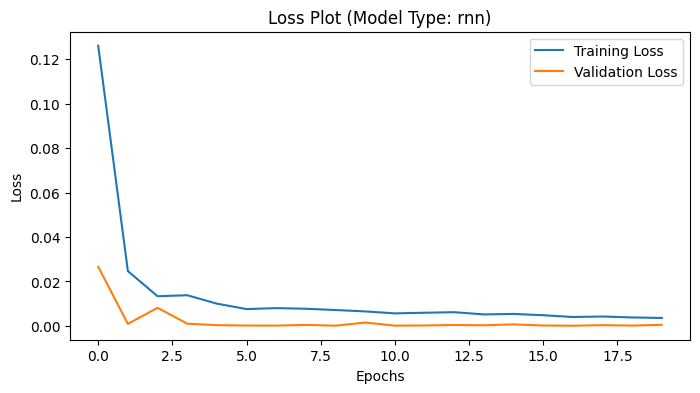

| 36        | -0.000460 | 63.77     | 0.2606    | 0.008688  | 30.54     |


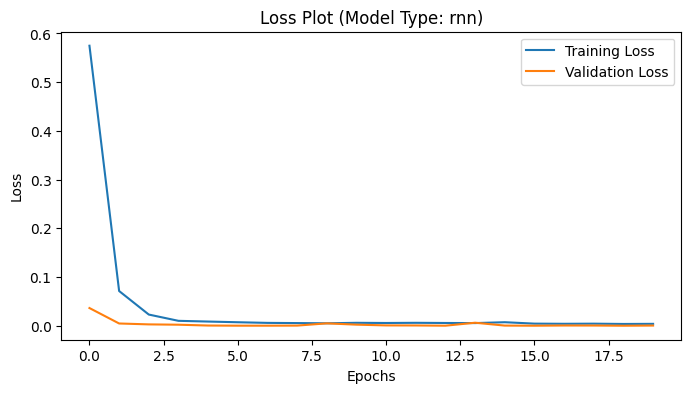

| 37        | -0.000439 | 63.98     | 0.3094    | 0.009963  | 98.96     |


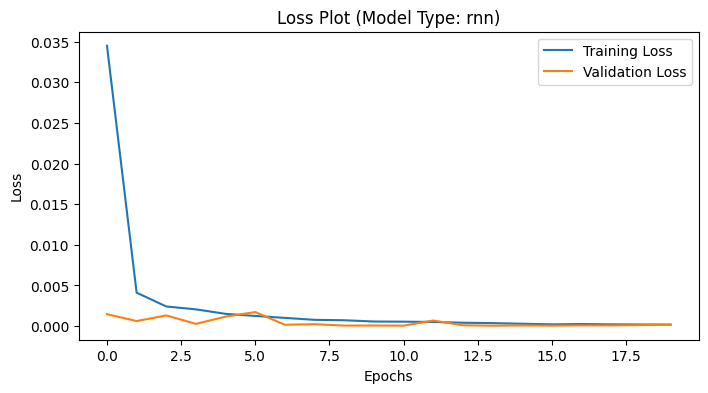

| 38        | -0.000158 | 4.435     | 0.1814    | 0.006095  | 127.5     |


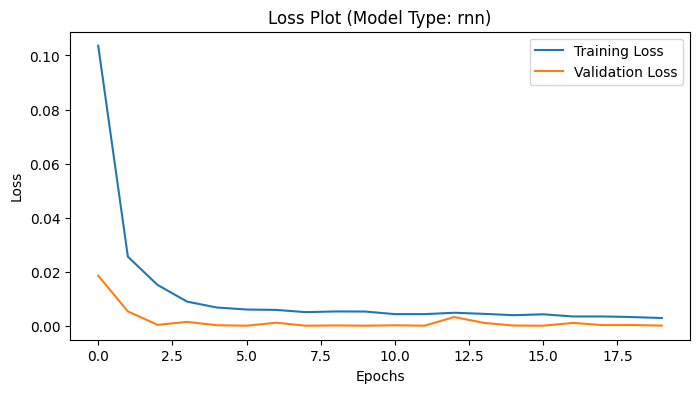

| 39        | -0.000101 | 52.35     | 0.3062    | 0.009691  | 52.84     |


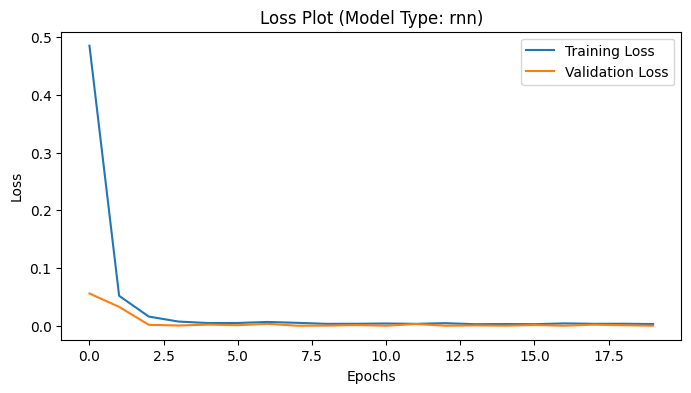

| 40        | -0.000111 | 63.87     | 0.2659    | 0.009187  | 127.4     |


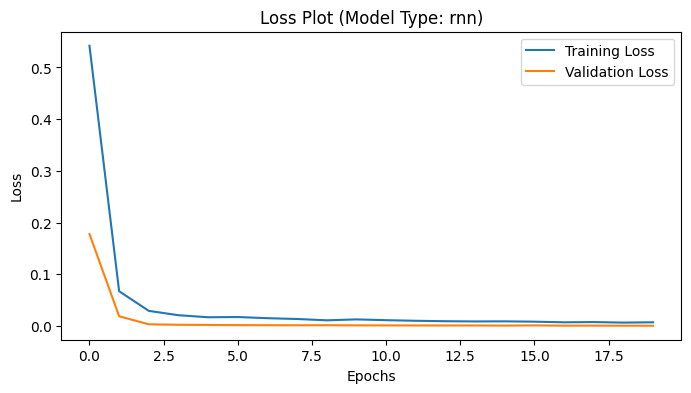

| 41        | -0.000771 | 51.38     | 0.06723   | 0.001428  | 16.44     |


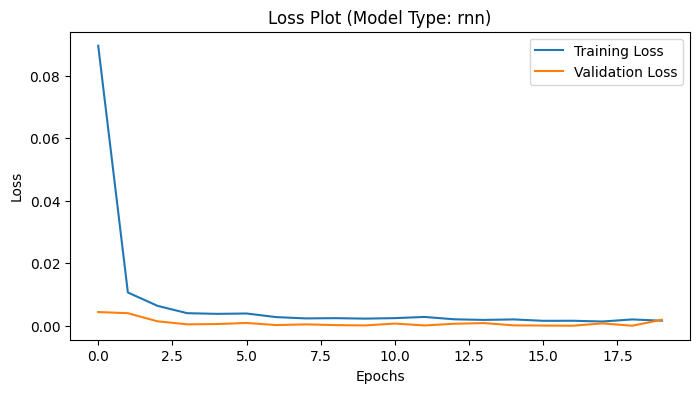

| 42        | -0.00196  | 35.53     | 0.08438   | 0.007568  | 45.77     |


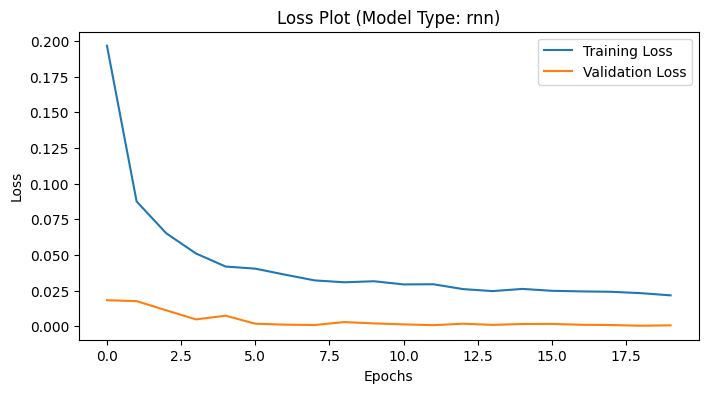

| 43        | -0.000676 | 12.59     | 0.4979    | 0.0003099 | 26.57     |


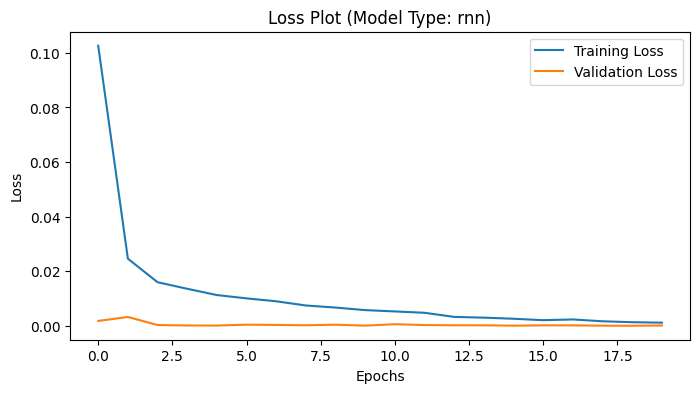

| 44        | -0.000156 | 32.22     | 0.3618    | 0.008616  | 24.61     |


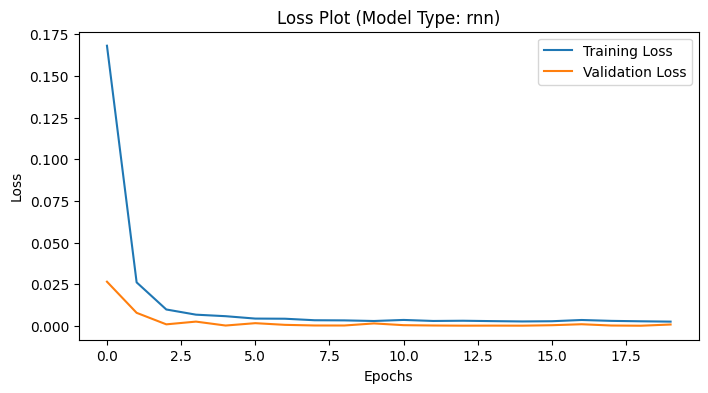

| 45        | -0.000766 | 63.65     | 0.2277    | 0.002633  | 109.9     |


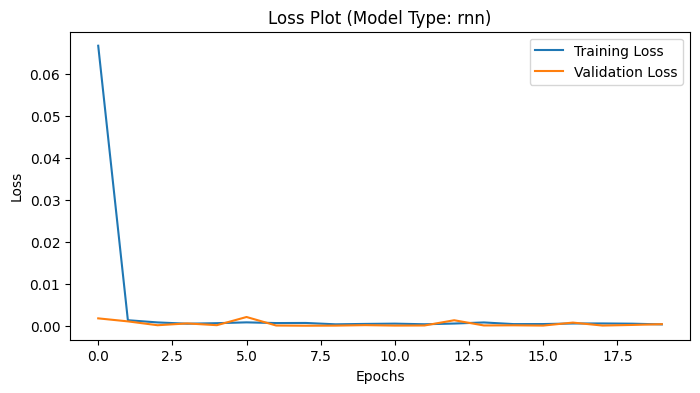

| 46        | -0.000413 | 15.71     | 0.02358   | 0.006319  | 127.9     |


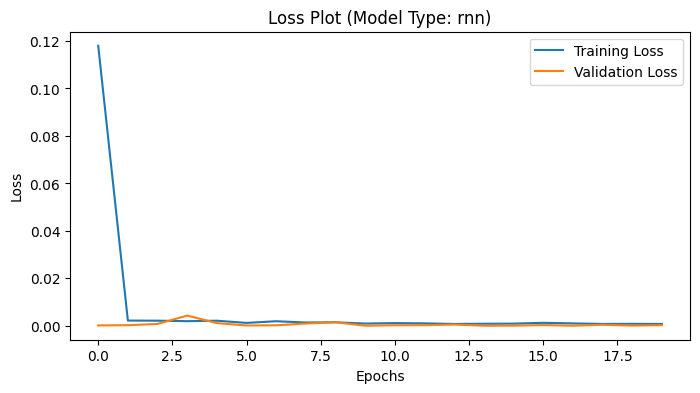

| 47        | -0.000283 | 14.9      | 0.07877   | 0.006386  | 100.6     |


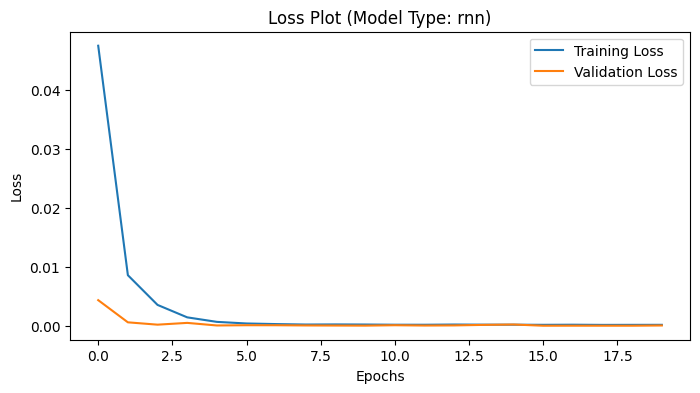

| 48        | -8.515e-0 | 4.01      | 0.444     | 0.00805   | 31.5      |


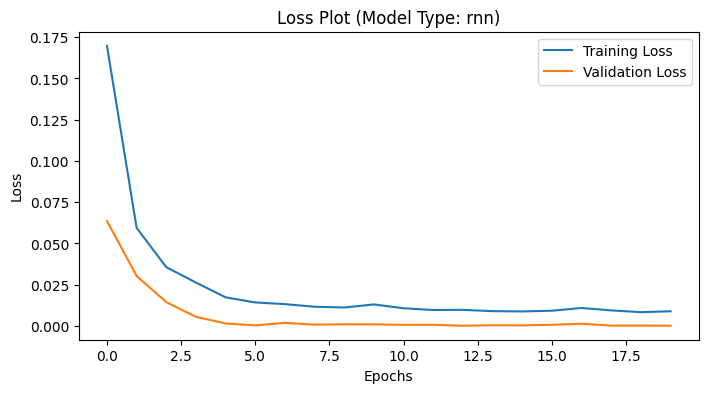

| 49        | -0.000161 | 63.15     | 0.4529    | 0.001496  | 72.83     |


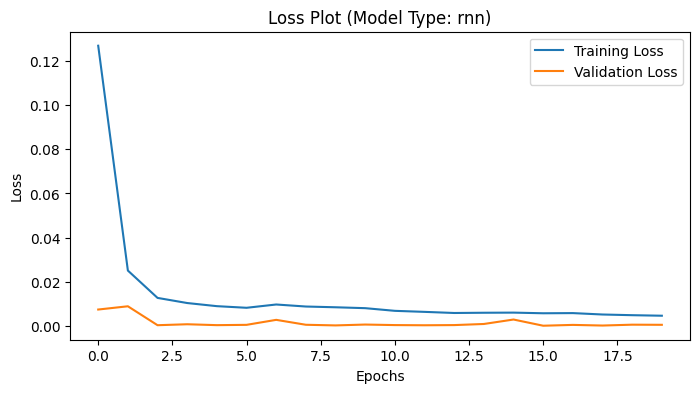

| 50        | -0.000476 | 52.92     | 0.4011    | 0.005469  | 62.48     |
Best hyperparameters:
{'target': -4.397569864522666e-05, 'params': {'batch_size': 20.856070581242847, 'dropout_rate': 0.27592108074754174, 'learning_rate': 0.0014101013255226518, 'units': 105.84606184445244}}


In [68]:
# Bayesian 최적화를 위한 하이퍼파라미터 범위 설정
param_bounds = {
    'units': (16, 128),  # RNN 유닛 개수 (정수로 변환 필요)
    'dropout_rate': (0.01, 0.5),  # Dropout 비율
    'learning_rate': (1e-6, 1e-2),  # Learning Rate (연속 값)
    'batch_size': (4, 64),  # Batch Size 범위 (정수로 변환 필요)
}

# Bayesian 최적화 객체 생성
bayesian_optimizer = BayesianOptimization(
    f=lambda units, dropout_rate, learning_rate, batch_size: bayesian_optimization(
        units, dropout_rate, learning_rate, batch_size, model_type='rnn'  # 여기에서 모델 타입 선택
    ),
    pbounds=param_bounds,
    random_state=42,
    verbose=2,
)

# Bayesian 최적화 실행
bayesian_optimizer.maximize(init_points=20, n_iter=30)

# 최적화 결과 출력
print("Best hyperparameters:")
print(bayesian_optimizer.max)

In [70]:
rnn_best_hyperparameters = bayesian_optimizer.max['params']
rnn_best_accuracy = bayesian_optimizer.max['target']

print("Best Hyperparameters:", rnn_best_hyperparameters)
print("Best Validation Accuracy:", rnn_best_accuracy)

# 최적 하이퍼파라미터 저장
rnn_best_hyperparameters = bayesian_optimizer.max['params']

Best Hyperparameters: {'batch_size': 20.856070581242847, 'dropout_rate': 0.27592108074754174, 'learning_rate': 0.0014101013255226518, 'units': 105.84606184445244}
Best Validation Accuracy: -4.397569864522666e-05


Epoch 1/20
49/49 [==============================] - 1s 3ms/step - loss: 0.0753 - mse: 0.0753
Epoch 2/20
49/49 [==============================] - 0s 4ms/step - loss: 0.0081 - mse: 0.0081
Epoch 3/20
49/49 [==============================] - 0s 2ms/step - loss: 0.0059 - mse: 0.0059
Epoch 4/20
49/49 [==============================] - 0s 2ms/step - loss: 0.0051 - mse: 0.0051
Epoch 5/20
49/49 [==============================] - 0s 2ms/step - loss: 0.0049 - mse: 0.0049
Epoch 6/20
49/49 [==============================] - 0s 2ms/step - loss: 0.0047 - mse: 0.0047
Epoch 7/20
49/49 [==============================] - 0s 2ms/step - loss: 0.0039 - mse: 0.0039
Epoch 8/20
49/49 [==============================] - 0s 2ms/step - loss: 0.0039 - mse: 0.0039
Epoch 9/20
49/49 [==============================] - 0s 2ms/step - loss: 0.0036 - mse: 0.0036
Epoch 10/20
49/49 [==============================] - 0s 2ms/step - loss: 0.0033 - mse: 0.0033
Epoch 11/20
49/49 [==============================] - 0s 2ms/step - lo

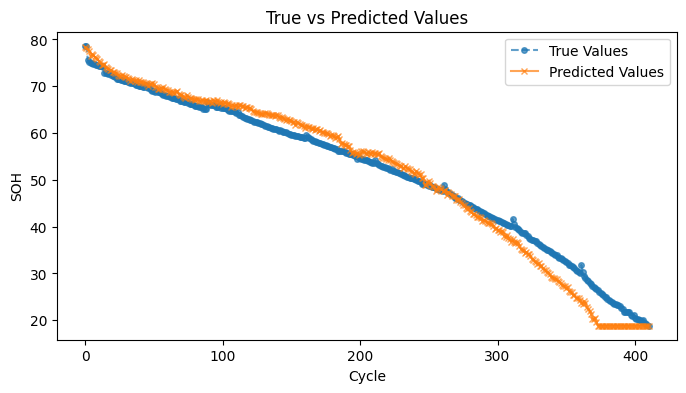

In [71]:
# 최적 하이퍼파라미터로 모델 생성
best_units = int(rnn_best_hyperparameters['units'])
best_dropout_rate = rnn_best_hyperparameters['dropout_rate']
best_learning_rate = rnn_best_hyperparameters['learning_rate']
best_batch_size = int(rnn_best_hyperparameters['batch_size'])

rnn_model = ()
rnn_model = build_rnn_model(best_units, best_dropout_rate, best_learning_rate,fixed_activation)

history = rnn_model.fit(
    train_feature, train_label,
    epochs=20,
    batch_size=best_batch_size,
    verbose=1
)


# 모델 평가
y_pred = rnn_model.predict(test_feature)

#역변환
origin = reverse_min_max_scaling(test_label,x_min,x_max)[:,0]
result = reverse_min_max_scaling(y_pred,x_min,x_max)[:,0]


mse = mean_squared_error(origin, result)
mae = mean_absolute_error(origin, result)
rmse = np.sqrt(mse)
r2 = r2_score(origin, result)

print("Model Evaluation Results:")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² (R-squared): {r2:.4f}")

# 결과 샘플 시각화
plt.figure(figsize=(8, 4))
plt.plot(origin, label="True Values", marker='o', linestyle='--', markersize=4, alpha=0.7)
plt.plot(result, label="Predicted Values", marker='x', linestyle='-', markersize=4, alpha=0.7)
plt.title("True vs Predicted Values")
plt.xlabel("Cycle")
plt.ylabel("SOH")
plt.legend()
plt.show()

## GRU

|   iter    |  target   | batch_... | dropou... | learni... |   units   |
-------------------------------------------------------------------------


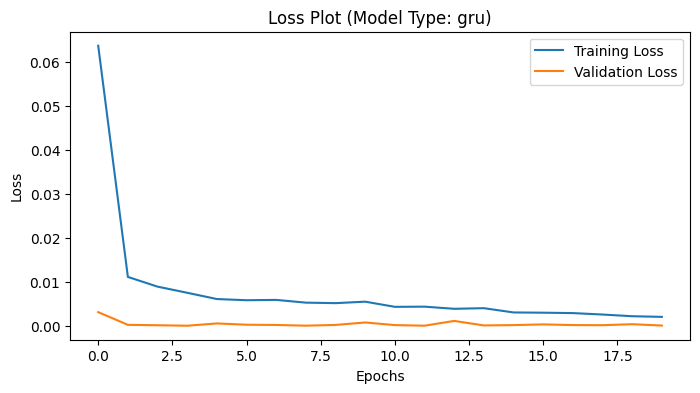

| 1         | -8.628e-0 | 26.47     | 0.4759    | 0.00732   | 83.05     |


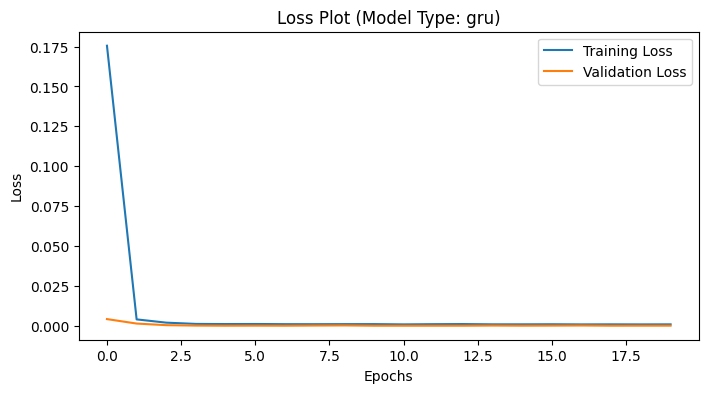

| 2         | -6.987e-0 | 13.36     | 0.08644   | 0.0005818 | 113.0     |


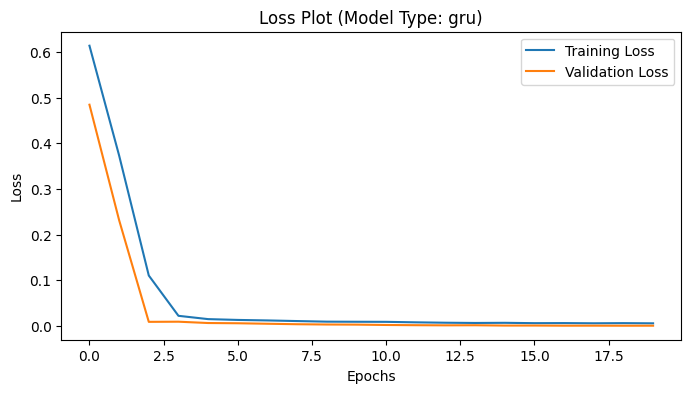

| 3         | -0.000215 | 40.07     | 0.357     | 0.0002068 | 124.6     |


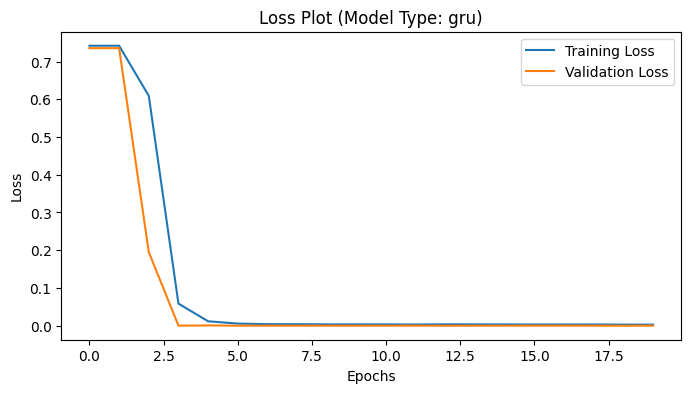

| 4         | -0.000165 | 53.95     | 0.114     | 0.001819  | 36.54     |


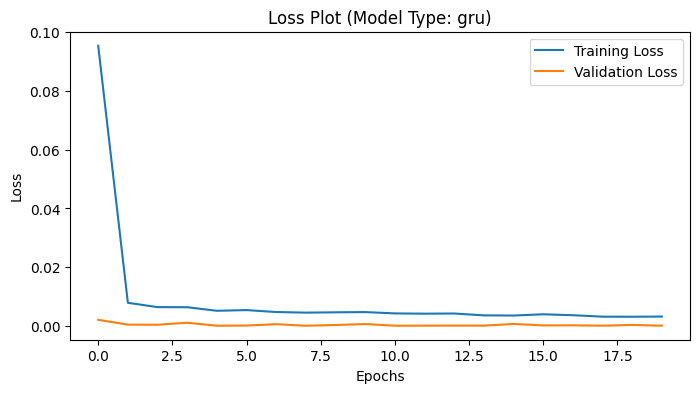

| 5         | -5.048e-0 | 22.25     | 0.2671    | 0.00432   | 48.62     |


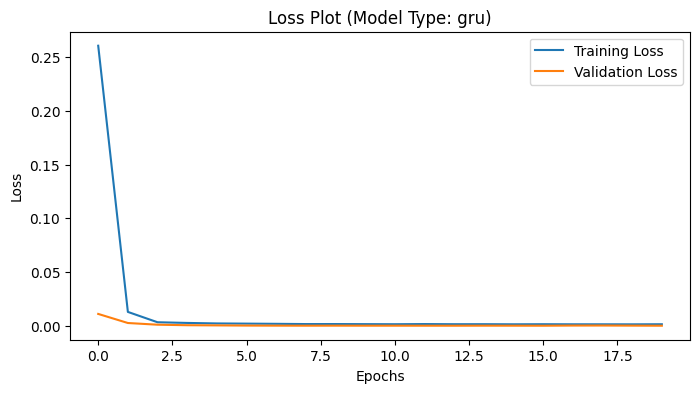

| 6         | -3.368e-0 | 40.71     | 0.07835   | 0.002922  | 57.03     |


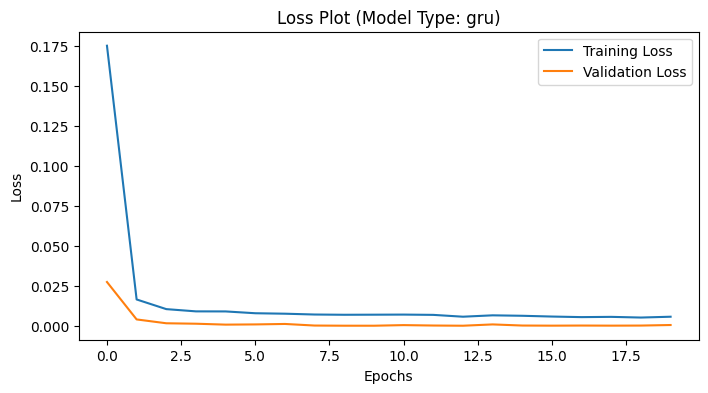

| 7         | -0.000478 | 31.36     | 0.3947    | 0.001998  | 73.59     |


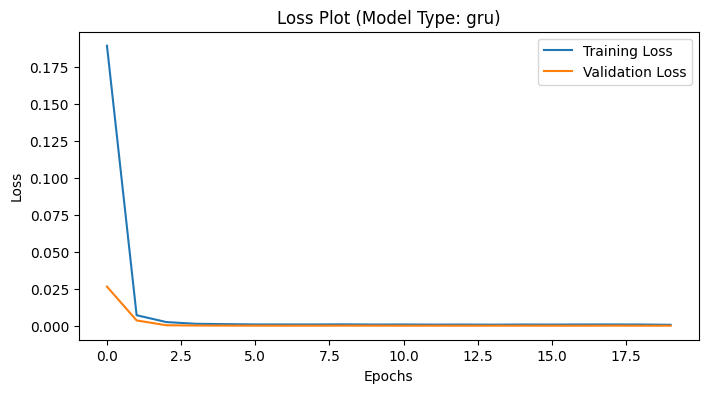

| 8         | -3.458e-0 | 39.54     | 0.03276   | 0.006076  | 35.1      |


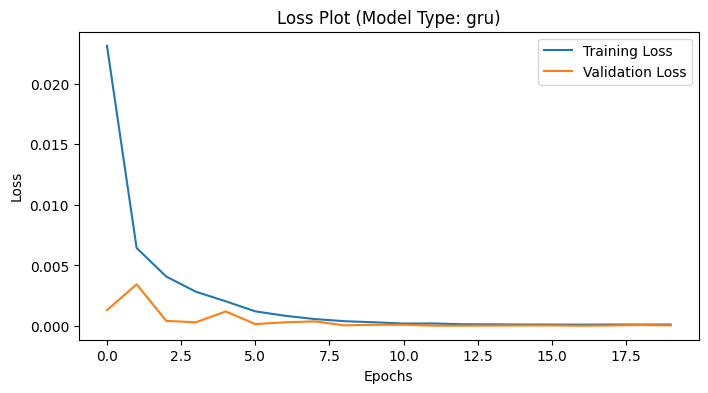

| 9         | -4.248e-0 | 7.903     | 0.475     | 0.009656  | 106.5     |


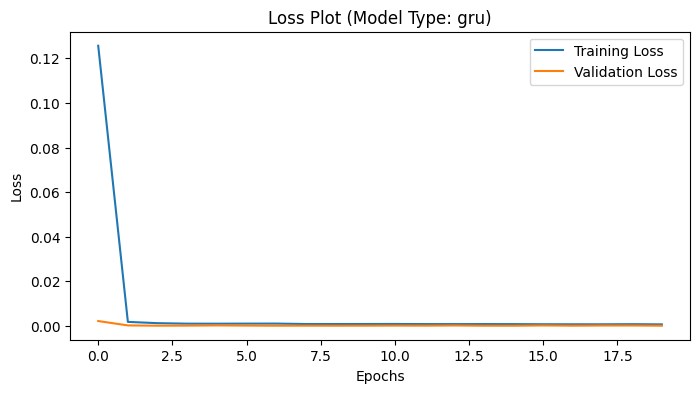

| 10        | -4.462e-0 | 22.28     | 0.05786   | 0.006843  | 65.3      |


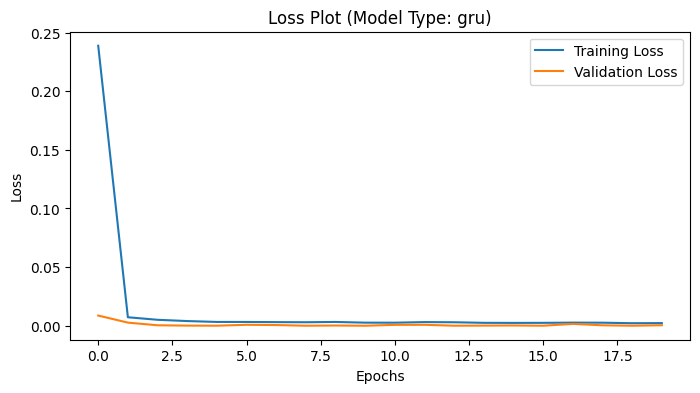

| 11        | -0.000444 | 11.32     | 0.2526    | 0.0003449 | 117.8     |


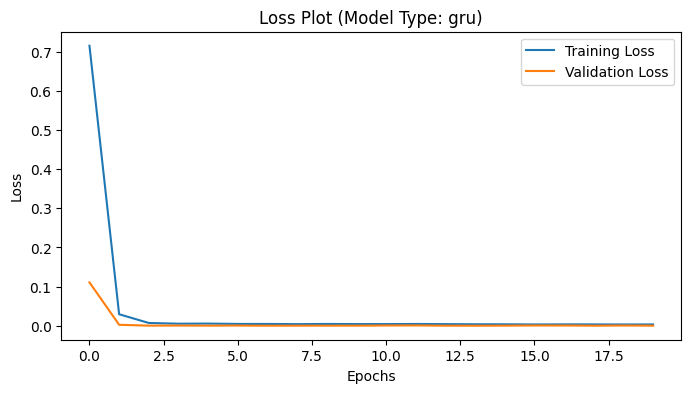

| 12        | -0.000157 | 19.53     | 0.3346    | 0.003118  | 74.25     |


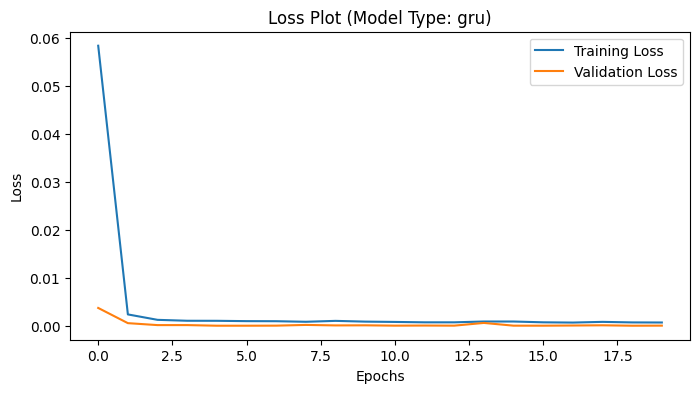

| 13        | -6.441e-0 | 36.8      | 0.1006    | 0.009696  | 102.8     |


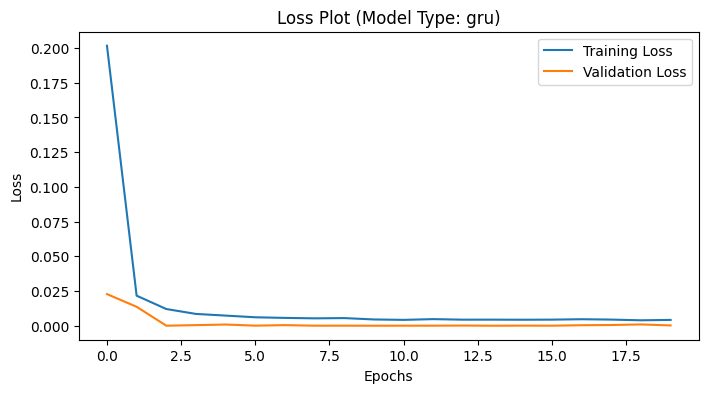

| 14        | -0.000243 | 60.37     | 0.4485    | 0.005979  | 119.2     |


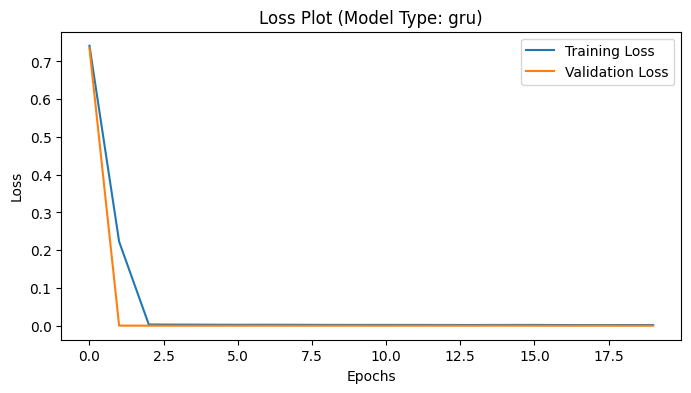

| 15        | -9.224e-0 | 9.31      | 0.106     | 0.0004532 | 52.44     |


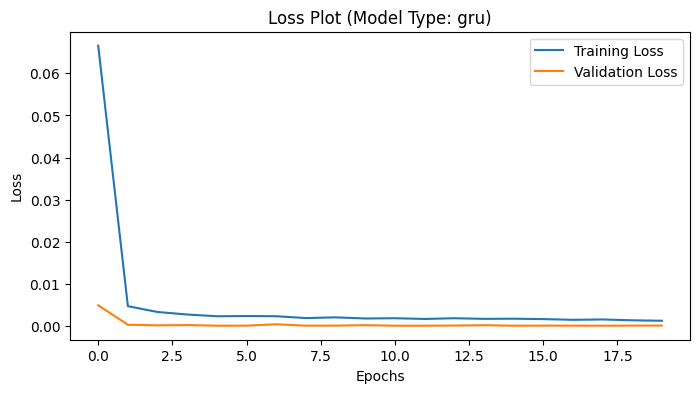

| 16        | -8.251e-0 | 27.32     | 0.143     | 0.008288  | 55.96     |


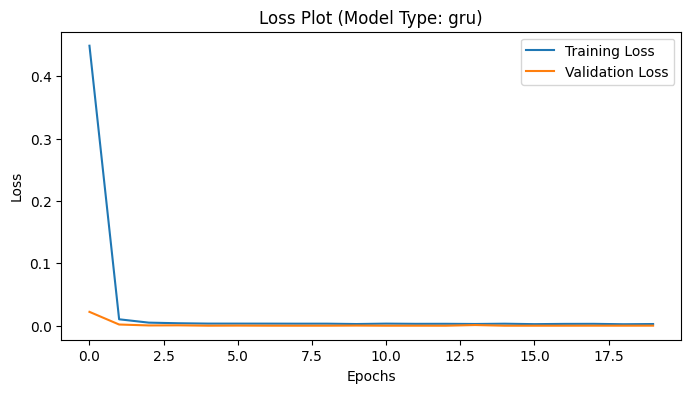

| 17        | -0.000131 | 20.86     | 0.2759    | 0.00141   | 105.8     |


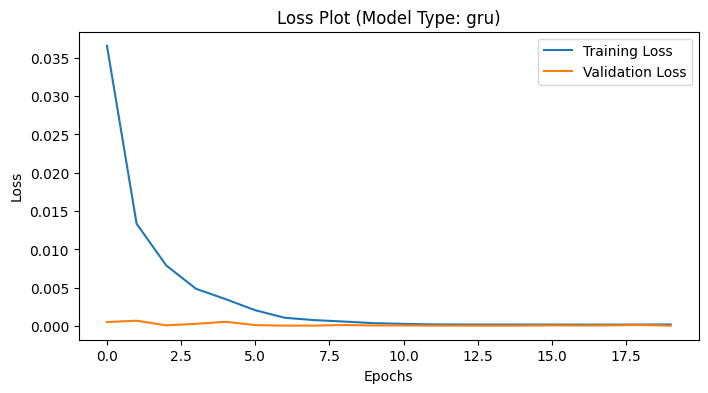

| 18        | -4.293e-0 | 8.473     | 0.4936    | 0.007723  | 38.26     |


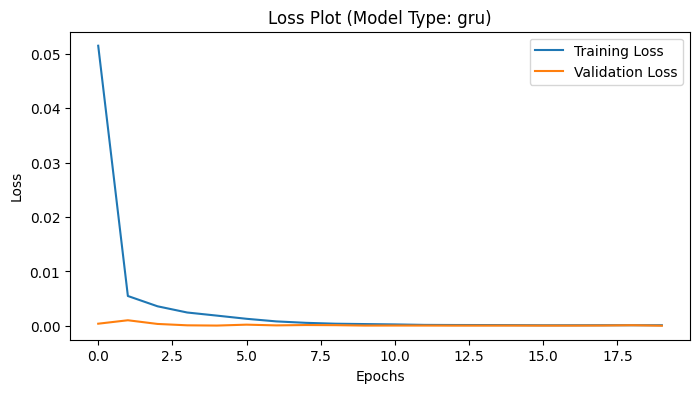

| 19        | -2.338e-0 | 4.331     | 0.4096    | 0.007069  | 97.65     |


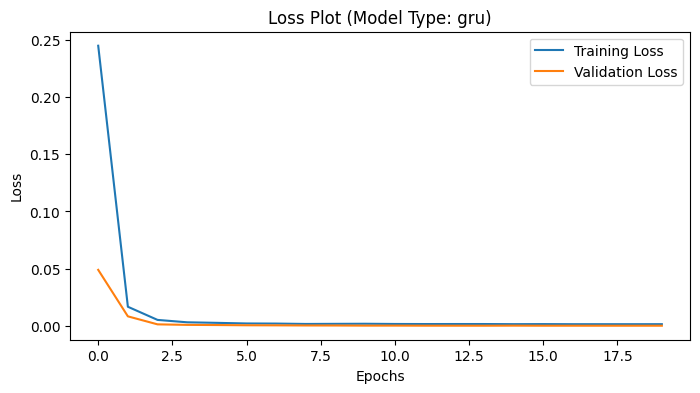

| 20        | -3.643e-0 | 50.28     | 0.04628   | 0.003585  | 28.98     |


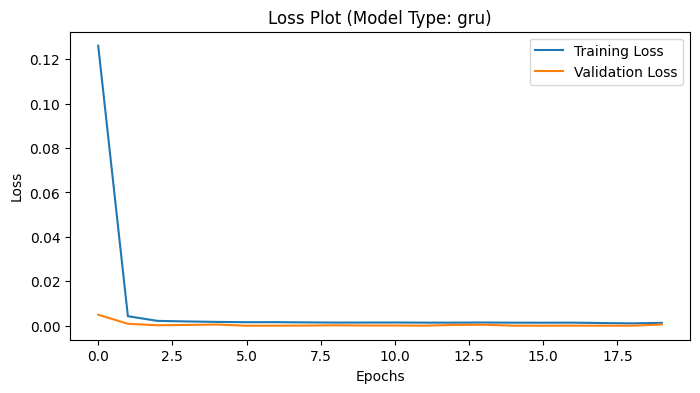

| 21        | -0.000596 | 13.35     | 0.1421    | 0.0009995 | 112.9     |


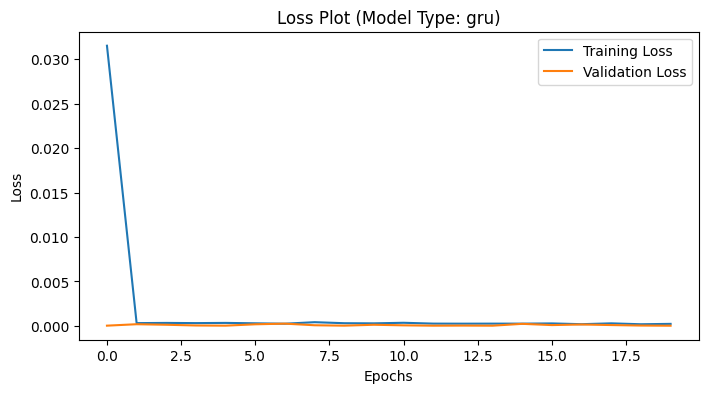

| 22        | -2.907e-0 | 6.953     | 0.01906   | 0.006005  | 97.07     |


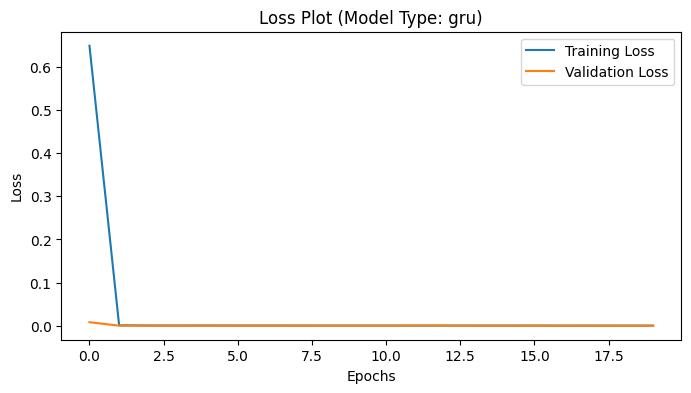

| 23        | -3.062e-0 | 4.269     | 0.02978   | 0.004665  | 55.44     |


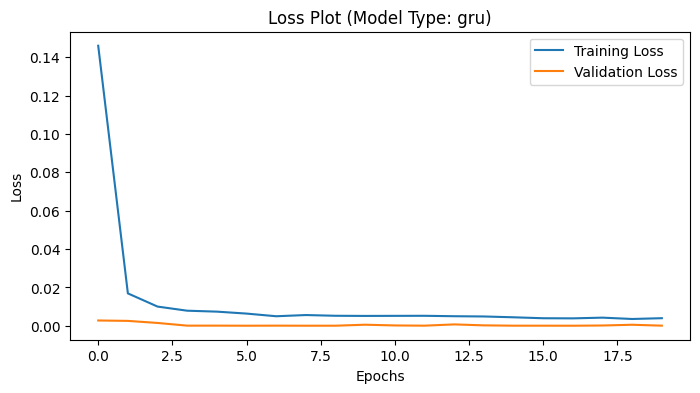

| 24        | -7.744e-0 | 62.25     | 0.3577    | 0.009939  | 57.88     |


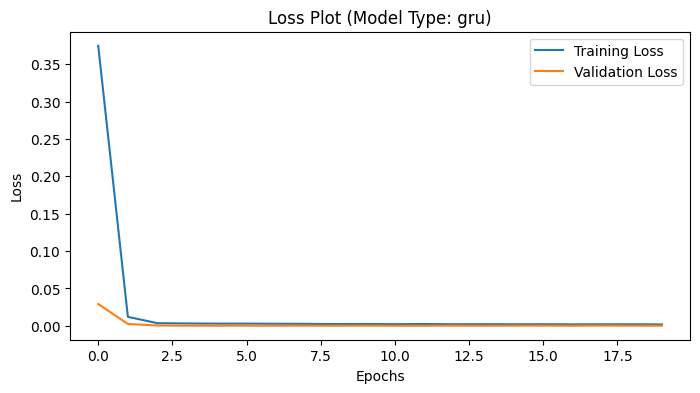

| 25        | -5.881e-0 | 32.29     | 0.08864   | 0.00802   | 26.81     |


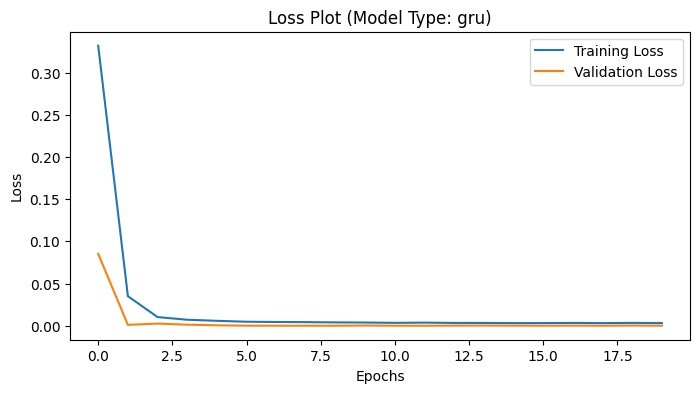

| 26        | -3.587e-0 | 60.3      | 0.3561    | 0.004502  | 127.8     |


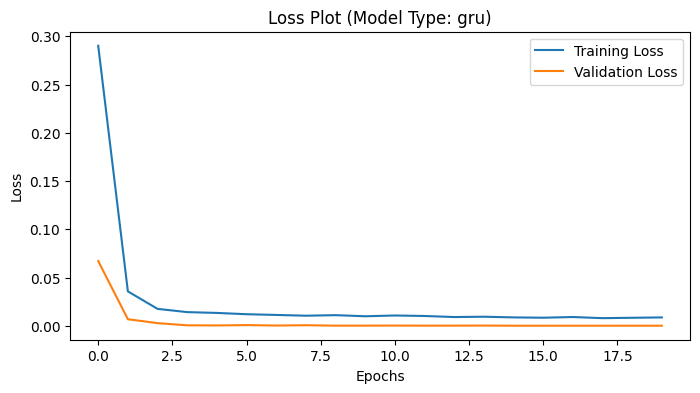

| 27        | -3.938e-0 | 50.51     | 0.4422    | 0.002272  | 57.71     |


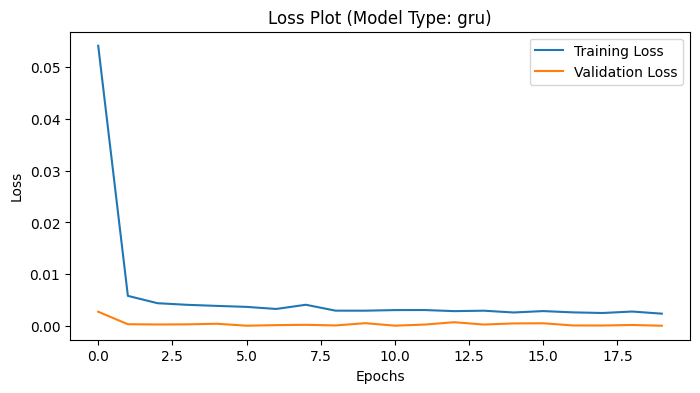

| 28        | -4.448e-0 | 15.61     | 0.3144    | 0.002483  | 102.0     |


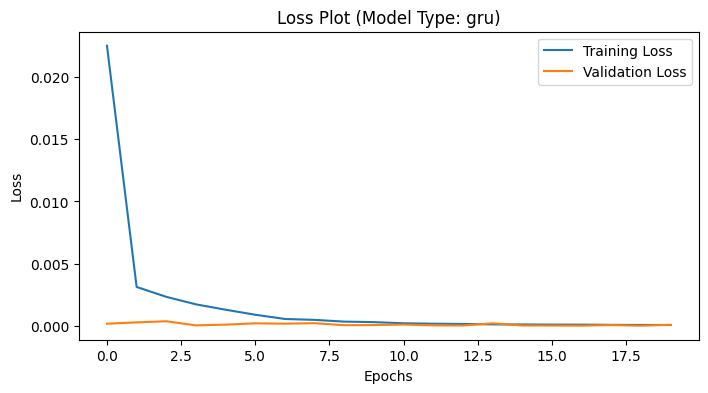

| 29        | -0.000101 | 4.378     | 0.2351    | 0.009767  | 75.0      |


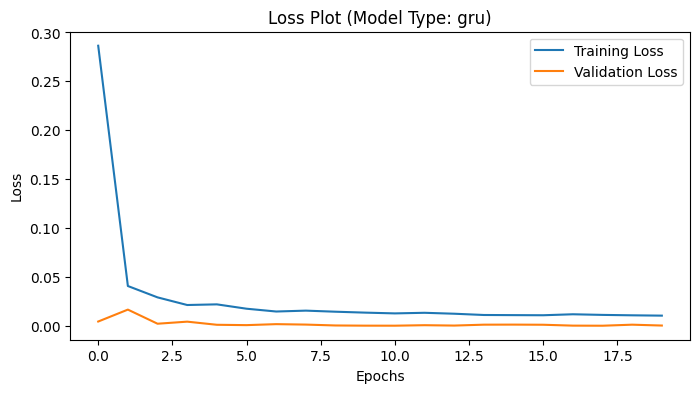

| 30        | -0.000349 | 48.56     | 0.2673    | 0.003004  | 18.2      |


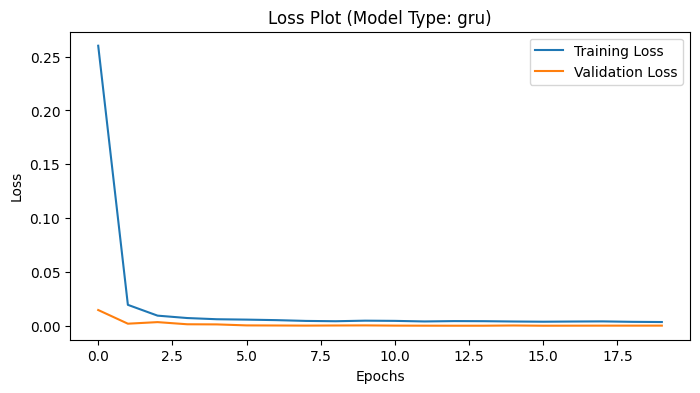

| 31        | -0.000139 | 57.22     | 0.2702    | 0.00257   | 75.49     |


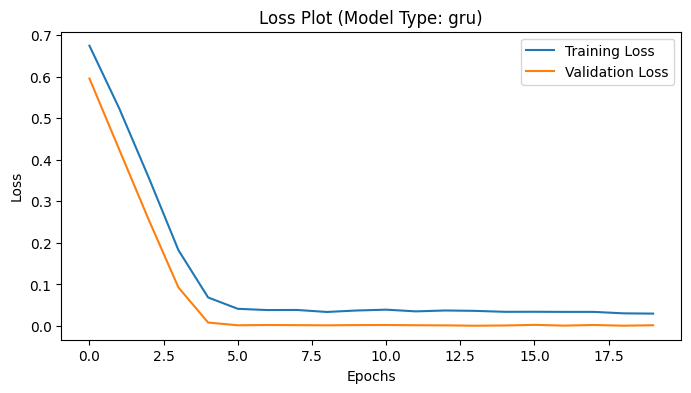

| 32        | -0.001788 | 16.37     | 0.4853    | 0.0001443 | 23.78     |


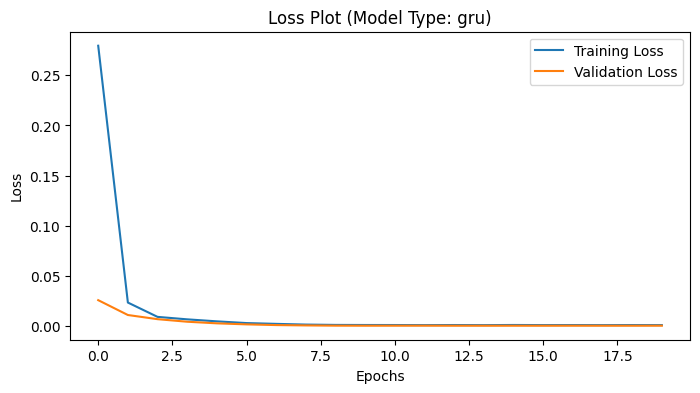

| 33        | -7.138e-0 | 30.9      | 0.05307   | 0.0005181 | 109.7     |


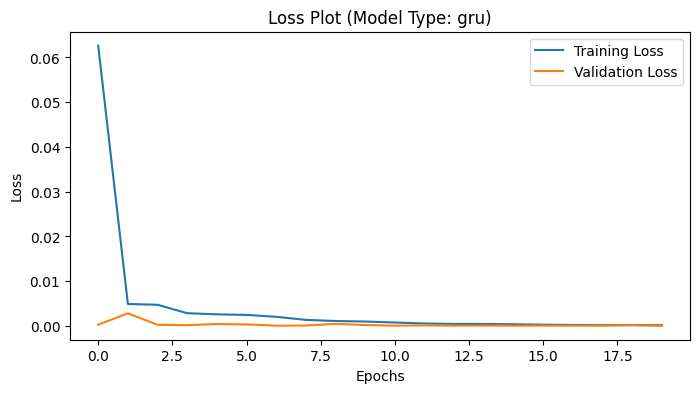

| 34        | -4.557e-0 | 8.984     | 0.4012    | 0.00922   | 124.8     |


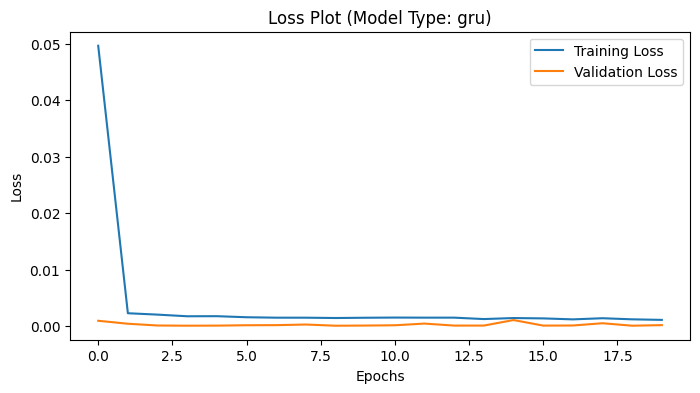

| 35        | -0.000146 | 25.87     | 0.1505    | 0.006923  | 90.74     |


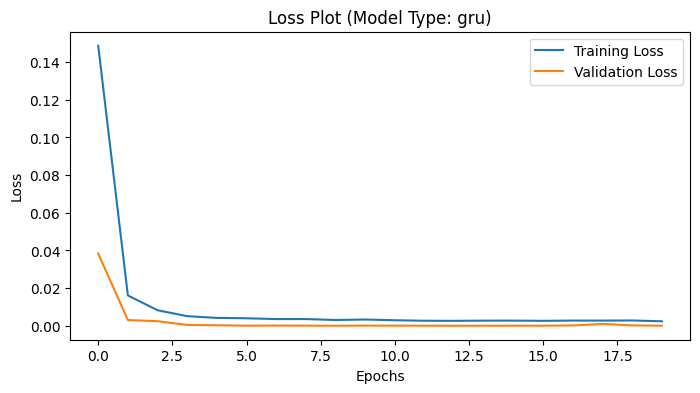

| 36        | -7.336e-0 | 63.21     | 0.3065    | 0.009006  | 100.8     |


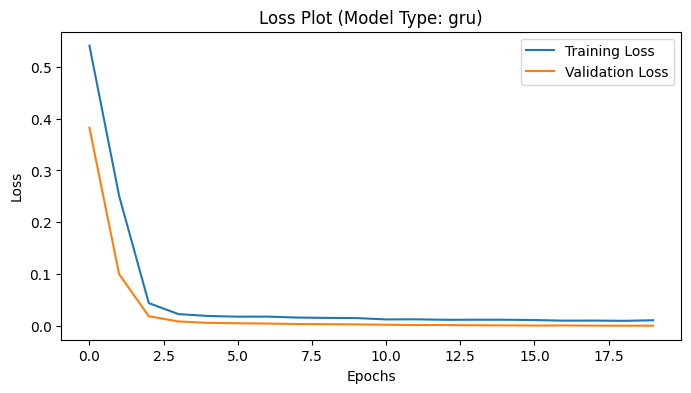

| 37        | -0.000331 | 46.83     | 0.3763    | 0.0004341 | 61.11     |


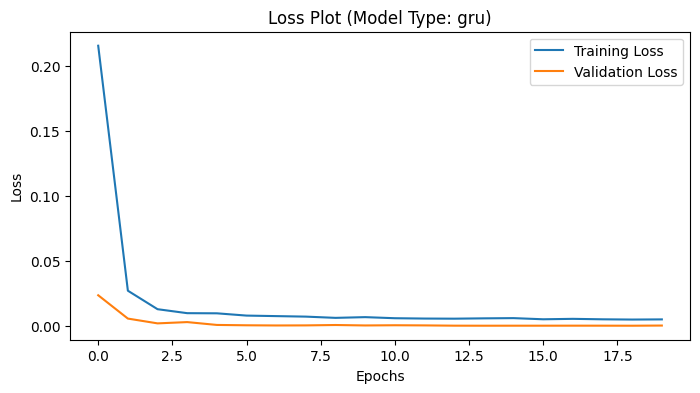

| 38        | -0.000171 | 54.72     | 0.3618    | 0.002955  | 76.56     |


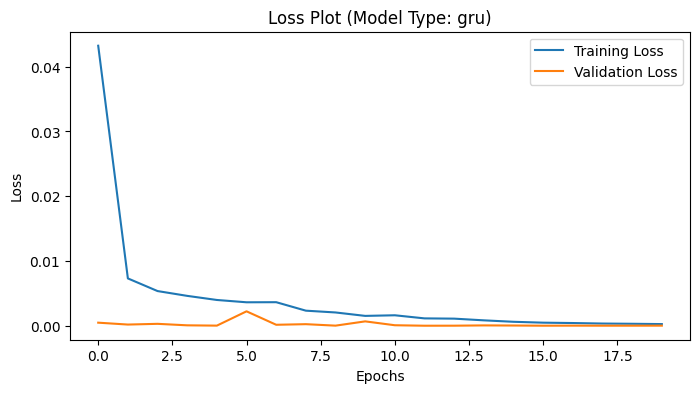

| 39        | -5.538e-0 | 9.063     | 0.4067    | 0.006915  | 83.78     |


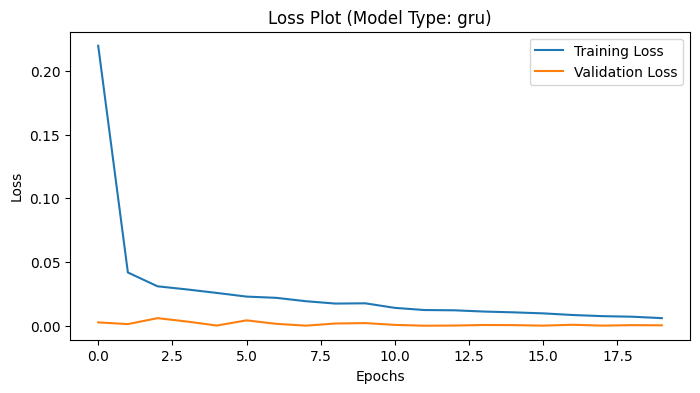

| 40        | -0.000376 | 51.55     | 0.4873    | 0.007285  | 20.33     |


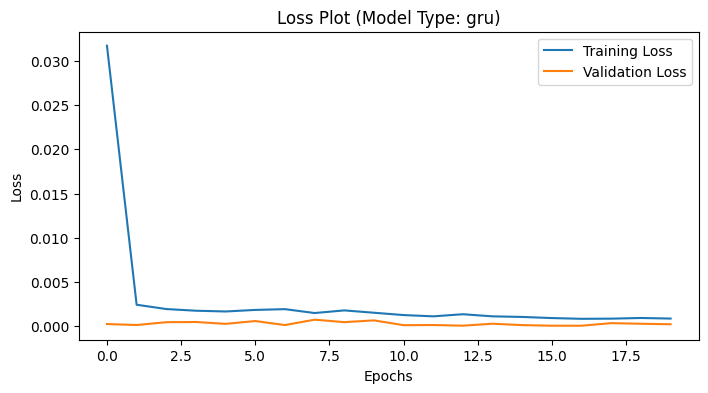

| 41        | -0.000198 | 17.85     | 0.2082    | 0.009455  | 112.5     |


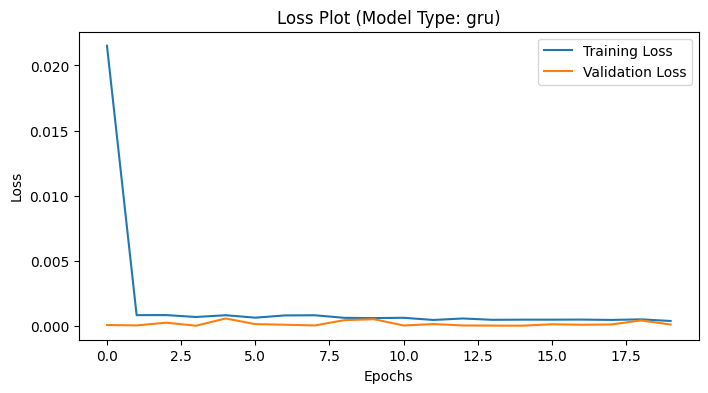

| 42        | -0.000128 | 7.505     | 0.07313   | 0.005504  | 113.4     |


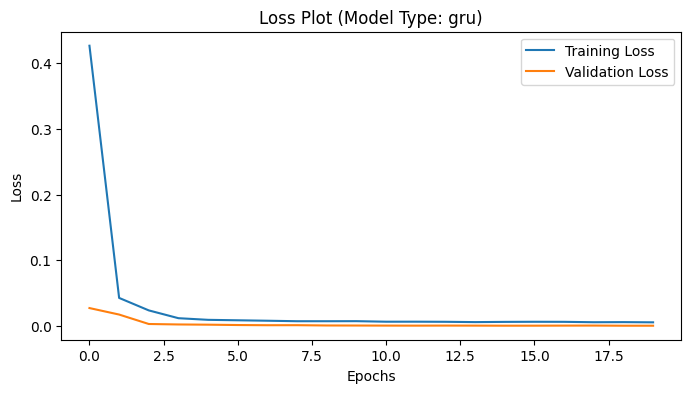

| 43        | -4.055e-0 | 60.84     | 0.3058    | 0.001688  | 65.3      |


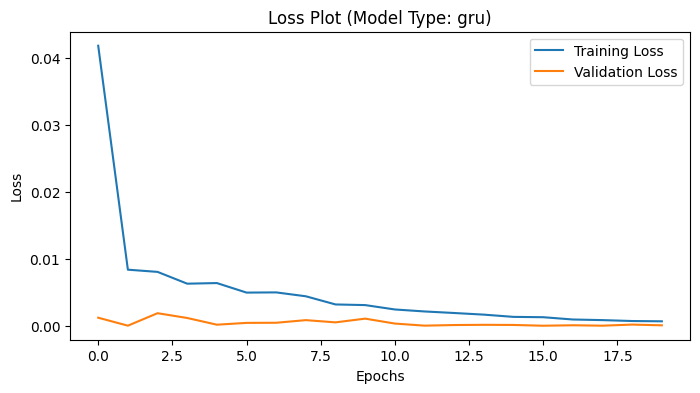

| 44        | -0.000108 | 12.92     | 0.4715    | 0.005351  | 85.13     |


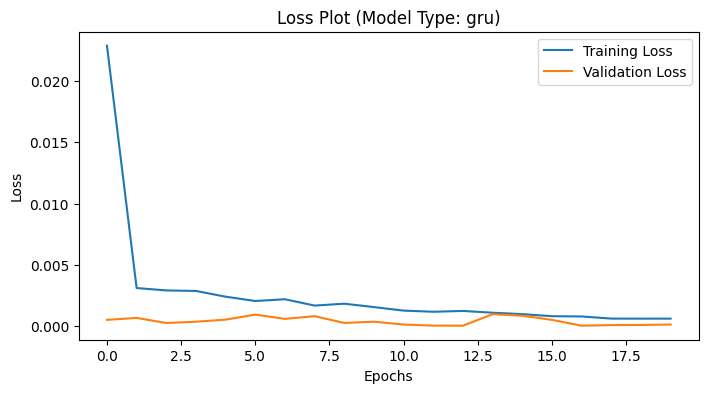

| 45        | -0.000141 | 7.685     | 0.2628    | 0.004271  | 122.7     |


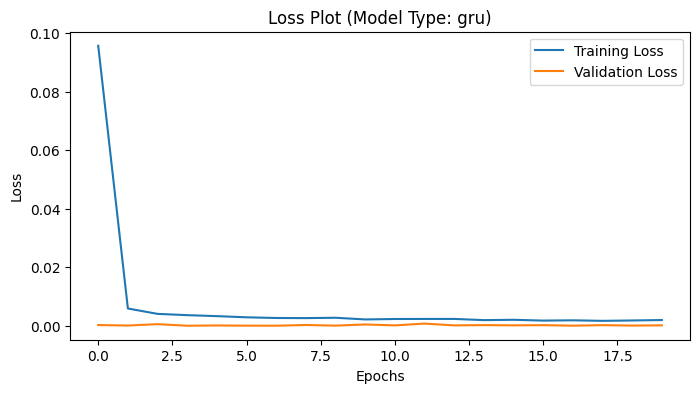

| 46        | -0.000158 | 24.84     | 0.1165    | 0.006669  | 33.93     |


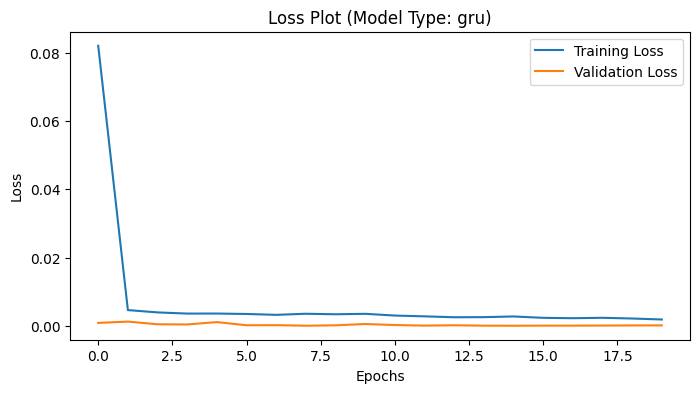

| 47        | -0.000138 | 13.55     | 0.2747    | 0.003152  | 84.4      |


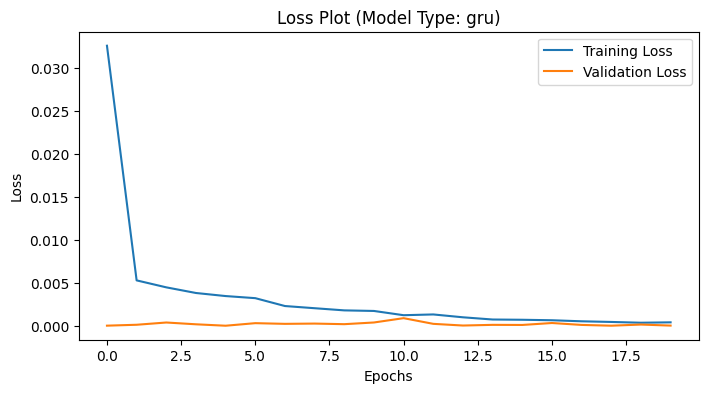

| 48        | -5.941e-0 | 9.581     | 0.3781    | 0.006563  | 110.6     |


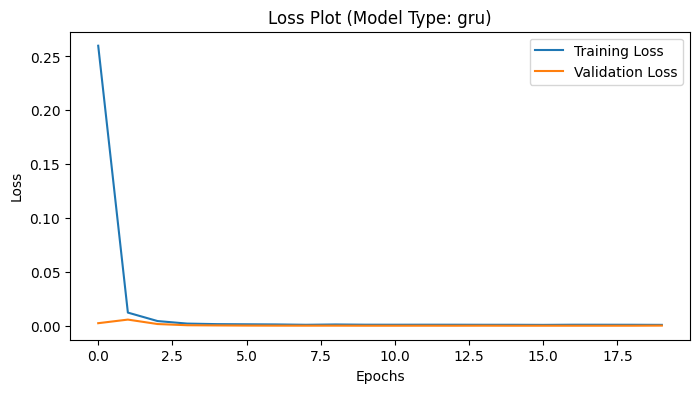

| 49        | -0.000145 | 46.98     | 0.03571   | 0.004745  | 35.69     |


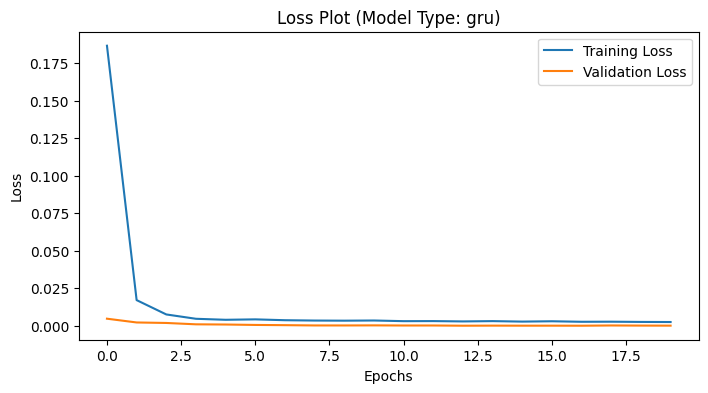

| 50        | -8.996e-0 | 58.0      | 0.1129    | 0.004614  | 32.1      |
Best hyperparameters:
{'target': -2.337664227525238e-05, 'params': {'batch_size': 4.331327027416144, 'dropout_rate': 0.40957609994286875, 'learning_rate': 0.007068866581132325, 'units': 97.64880282059057}}


In [72]:
# Bayesian 최적화를 위한 하이퍼파라미터 범위 설정
param_bounds = {
    'units': (16, 128),  # RNN 유닛 개수 (정수로 변환 필요)
    'dropout_rate': (0.01, 0.5),  # Dropout 비율
    'learning_rate': (1e-6, 1e-2),  # Learning Rate (연속 값)
    'batch_size': (4, 64),  # Batch Size 범위 (정수로 변환 필요)
}

# Bayesian 최적화 객체 생성
bayesian_optimizer = BayesianOptimization(
    f=lambda units, dropout_rate, learning_rate, batch_size: bayesian_optimization(
        units, dropout_rate, learning_rate, batch_size, model_type='gru'  # 여기에서 모델 타입 선택
    ),
    pbounds=param_bounds,
    random_state=42,
    verbose=2,
)

# Bayesian 최적화 실행
bayesian_optimizer.maximize(init_points=20, n_iter=30)

# 최적화 결과 출력
print("Best hyperparameters:")
print(bayesian_optimizer.max)

In [73]:
gru_best_hyperparameters = bayesian_optimizer.max['params']
gru_best_accuracy = bayesian_optimizer.max['target']

print("Best Hyperparameters:", gru_best_hyperparameters)
print("Best Validation Accuracy:", gru_best_accuracy)

# 최적 하이퍼파라미터 저장
gru_best_hyperparameters = bayesian_optimizer.max['params']

Best Hyperparameters: {'batch_size': 4.331327027416144, 'dropout_rate': 0.40957609994286875, 'learning_rate': 0.007068866581132325, 'units': 97.64880282059057}
Best Validation Accuracy: -2.337664227525238e-05


Epoch 1/50
243/243 [==============================] - 3s 3ms/step - loss: 0.0228 - mse: 0.0228
Epoch 2/50
243/243 [==============================] - 1s 3ms/step - loss: 0.0051 - mse: 0.0051
Epoch 3/50
243/243 [==============================] - 1s 4ms/step - loss: 0.0030 - mse: 0.0030
Epoch 4/50
243/243 [==============================] - 1s 4ms/step - loss: 0.0019 - mse: 0.0019
Epoch 5/50
243/243 [==============================] - 1s 3ms/step - loss: 0.0013 - mse: 0.0013
Epoch 6/50
243/243 [==============================] - 1s 3ms/step - loss: 7.6951e-04 - mse: 7.6951e-04
Epoch 7/50
243/243 [==============================] - 1s 3ms/step - loss: 5.3694e-04 - mse: 5.3694e-04
Epoch 8/50
243/243 [==============================] - 1s 3ms/step - loss: 3.7800e-04 - mse: 3.7800e-04
Epoch 9/50
243/243 [==============================] - 1s 4ms/step - loss: 2.5901e-04 - mse: 2.5901e-04
Epoch 10/50
243/243 [==============================] - 1s 3ms/step - loss: 1.8399e-04 - mse: 1.8399e-04
Epoch 11/

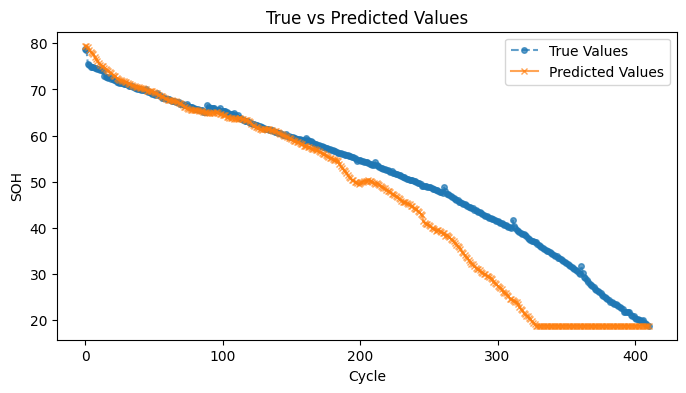

In [74]:
# 최적 하이퍼파라미터로 모델 생성
best_units = int(gru_best_hyperparameters['units'])
best_dropout_rate = gru_best_hyperparameters['dropout_rate']
best_learning_rate = gru_best_hyperparameters['learning_rate']
best_batch_size = int(gru_best_hyperparameters['batch_size'])

gru_model = ()
gru_model = build_gru_model(best_units, best_dropout_rate, best_learning_rate,fixed_activation)
gru_model.summary

history = gru_model.fit(
    train_feature, train_label,
    epochs=50,
    batch_size=best_batch_size,
    verbose=1
)

# 모델 평가
y_pred = gru_model.predict(test_feature)

#역변환
origin = reverse_min_max_scaling(test_label,x_min,x_max)[:,0]
result = reverse_min_max_scaling(y_pred,x_min,x_max)[:,0]


mse = mean_squared_error(origin, result)
mae = mean_absolute_error(origin, result)
rmse = np.sqrt(mse)
r2 = r2_score(origin, result)

print("Model Evaluation Results:")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² (R-squared): {r2:.4f}")

# 결과 샘플 시각화
plt.figure(figsize=(8, 4))
plt.plot(origin, label="True Values", marker='o', linestyle='--', markersize=4, alpha=0.7)
plt.plot(result, label="Predicted Values", marker='x', linestyle='-', markersize=4, alpha=0.7)
plt.title("True vs Predicted Values")
plt.xlabel("Cycle")
plt.ylabel("SOH")
plt.legend()
plt.show()

## LSTM

|   iter    |  target   | batch_... | dropou... | learni... |   units   |
-------------------------------------------------------------------------


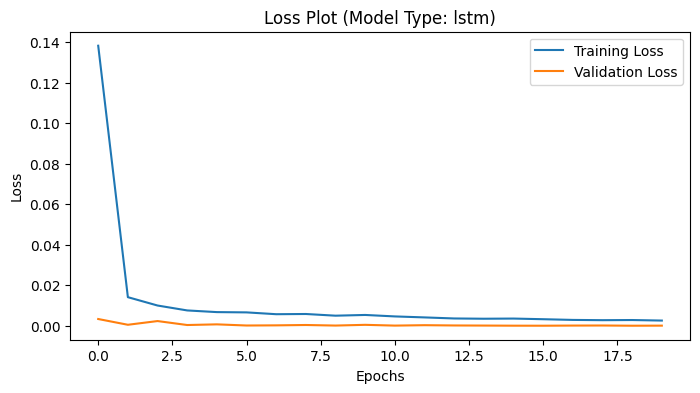

| 1         | -7.588e-0 | 26.47     | 0.4759    | 0.00732   | 83.05     |


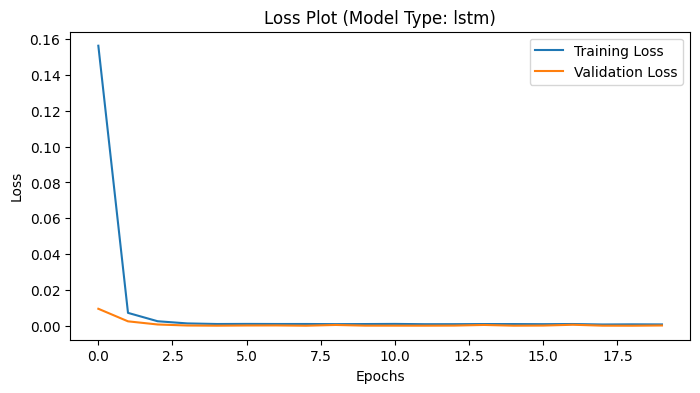

| 2         | -0.000162 | 13.36     | 0.08644   | 0.0005818 | 113.0     |


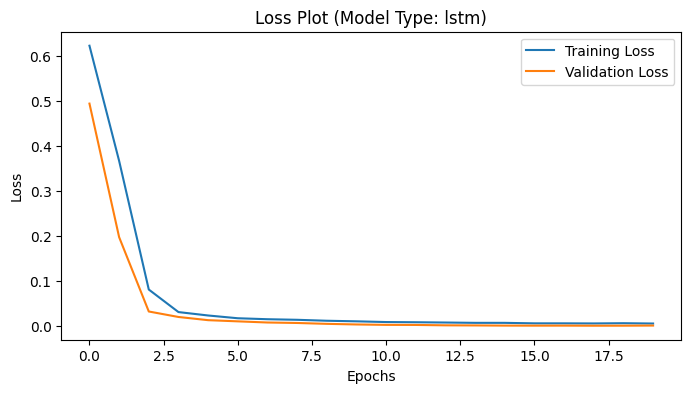

| 3         | -0.000438 | 40.07     | 0.357     | 0.0002068 | 124.6     |


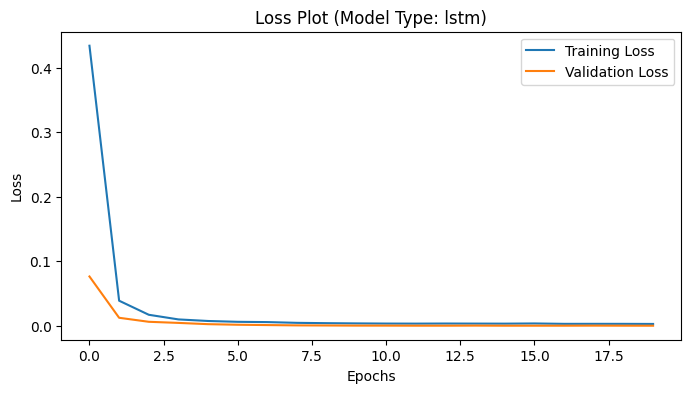

| 4         | -2.37e-05 | 53.95     | 0.114     | 0.001819  | 36.54     |


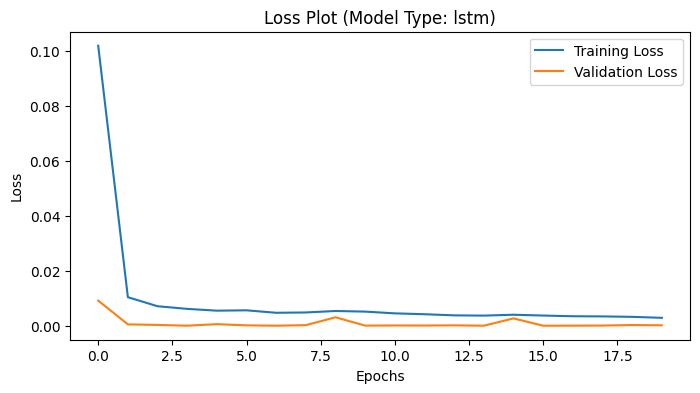

| 5         | -0.000183 | 22.25     | 0.2671    | 0.00432   | 48.62     |


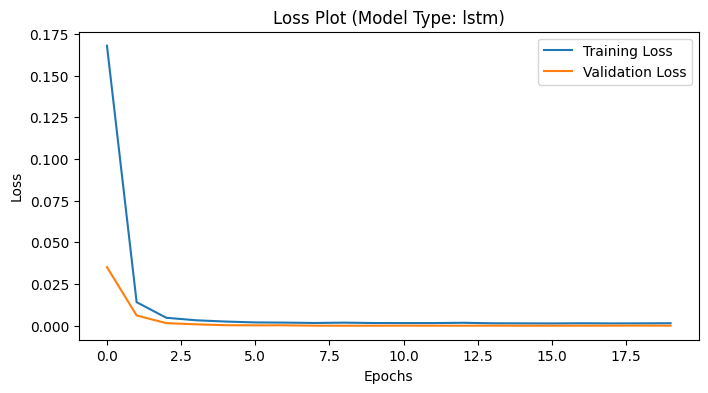

| 6         | -3.856e-0 | 40.71     | 0.07835   | 0.002922  | 57.03     |


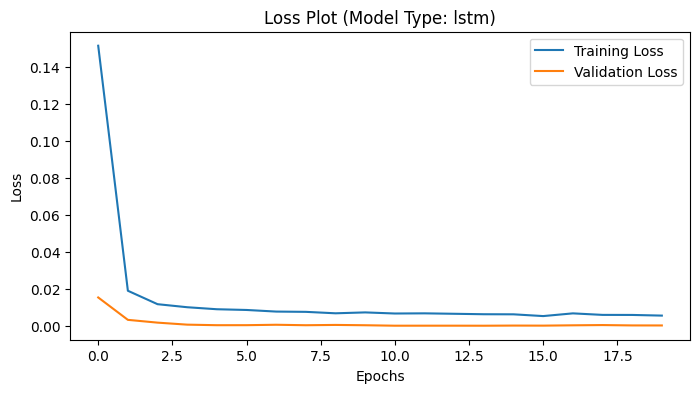

| 7         | -0.000168 | 31.36     | 0.3947    | 0.001998  | 73.59     |


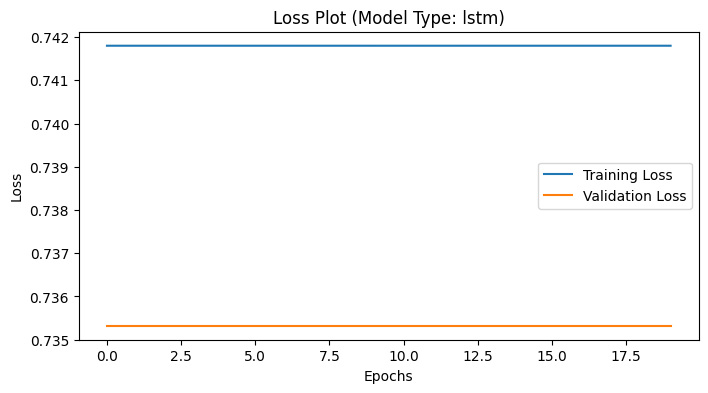

| 8         | -0.7353   | 39.54     | 0.03276   | 0.006076  | 35.1      |


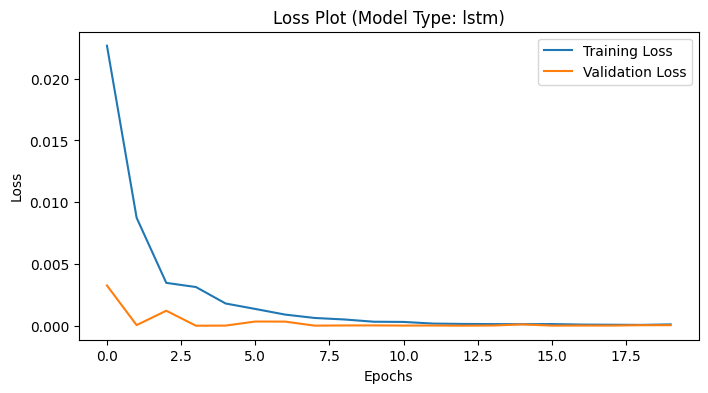

| 9         | -7.247e-0 | 7.903     | 0.475     | 0.009656  | 106.5     |


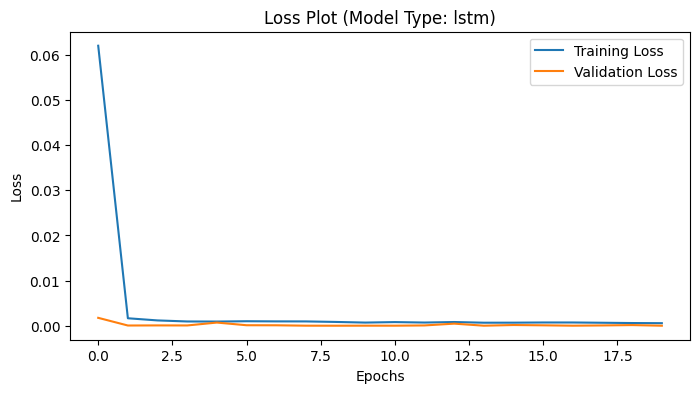

| 10        | -2.367e-0 | 22.28     | 0.05786   | 0.006843  | 65.3      |


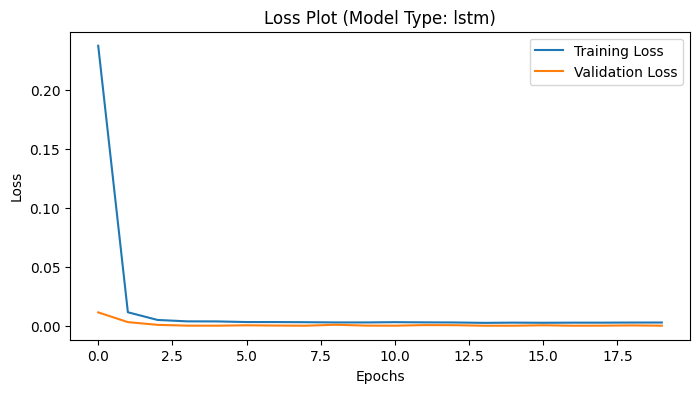

| 11        | -6.414e-0 | 11.32     | 0.2526    | 0.0003449 | 117.8     |


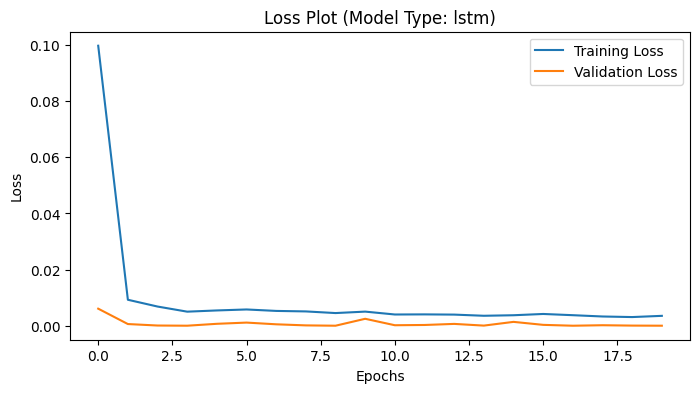

| 12        | -2.827e-0 | 19.53     | 0.3346    | 0.003118  | 74.25     |


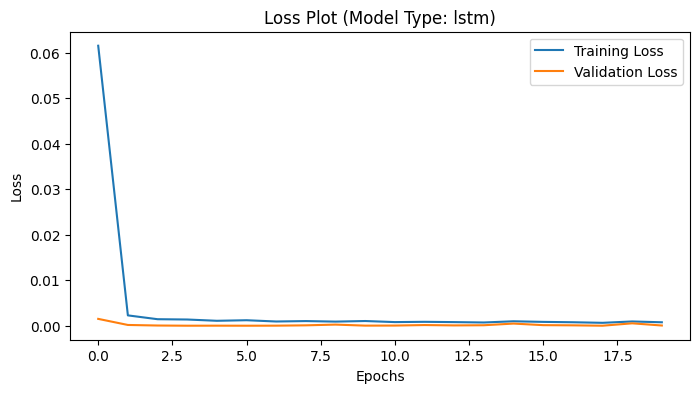

| 13        | -6.968e-0 | 36.8      | 0.1006    | 0.009696  | 102.8     |


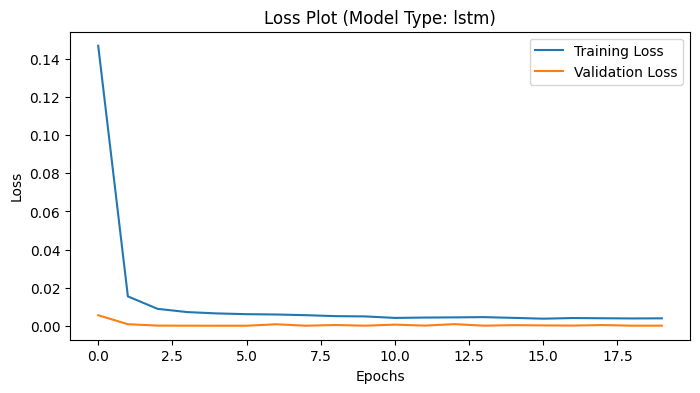

| 14        | -5.938e-0 | 60.37     | 0.4485    | 0.005979  | 119.2     |


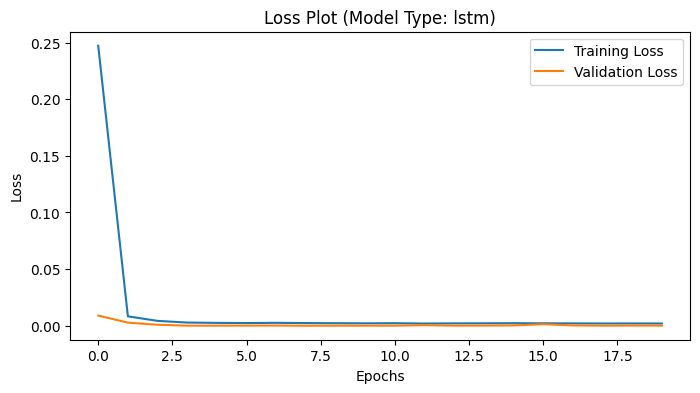

| 15        | -0.000129 | 9.31      | 0.106     | 0.0004532 | 52.44     |


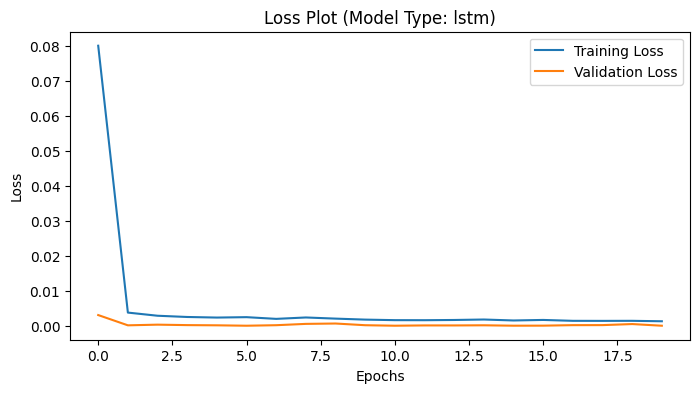

| 16        | -2.379e-0 | 27.32     | 0.143     | 0.008288  | 55.96     |


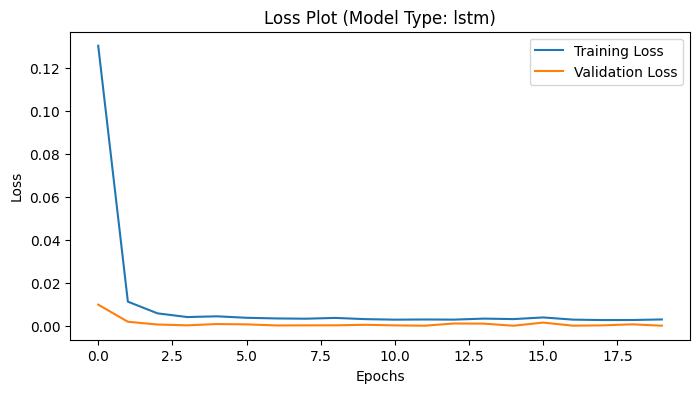

| 17        | -3.446e-0 | 20.86     | 0.2759    | 0.00141   | 105.8     |


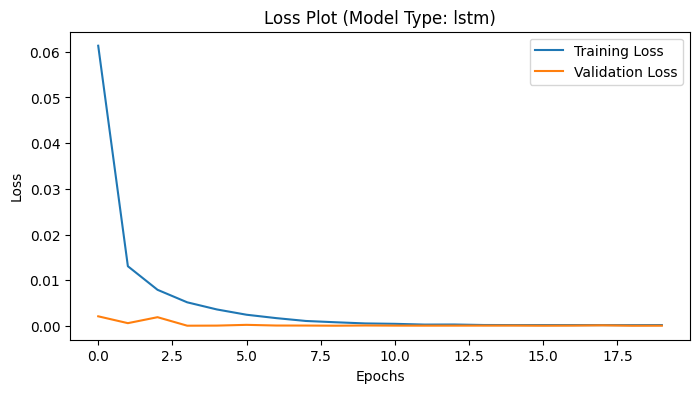

| 18        | -4.441e-0 | 8.473     | 0.4936    | 0.007723  | 38.26     |


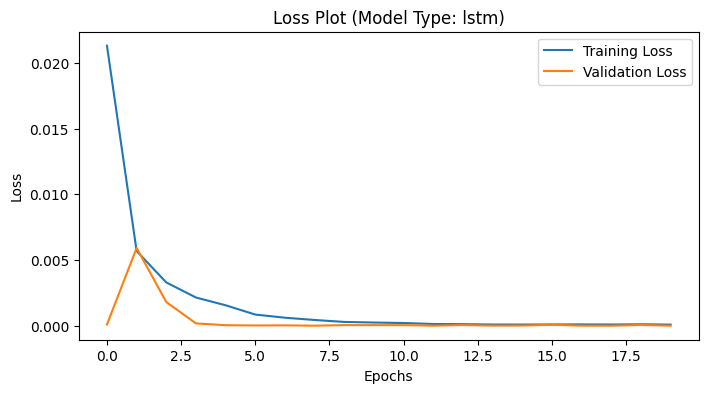

| 19        | -2.991e-0 | 4.331     | 0.4096    | 0.007069  | 97.65     |


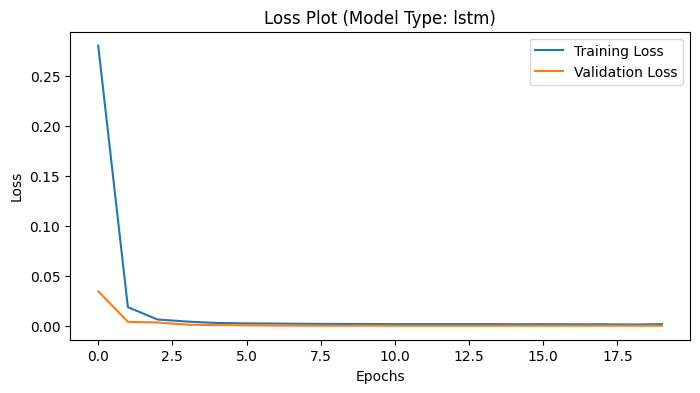

| 20        | -3.36e-05 | 50.28     | 0.04628   | 0.003585  | 28.98     |


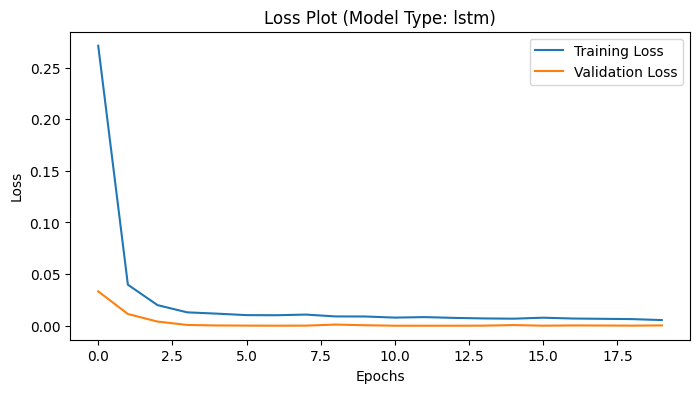

| 21        | -0.000331 | 60.93     | 0.2915    | 0.007593  | 26.03     |


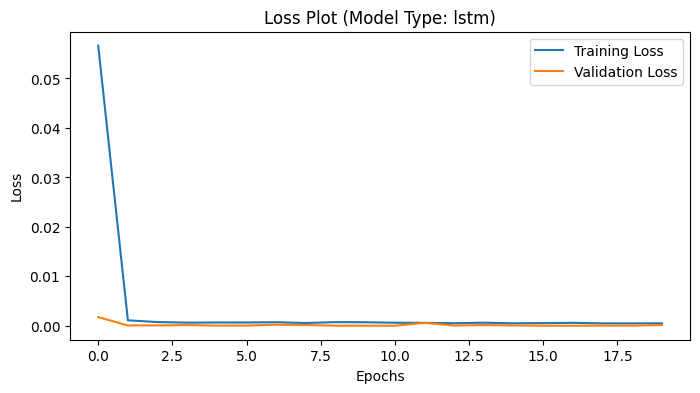

| 22        | -0.000166 | 12.08     | 0.06353   | 0.003512  | 115.3     |


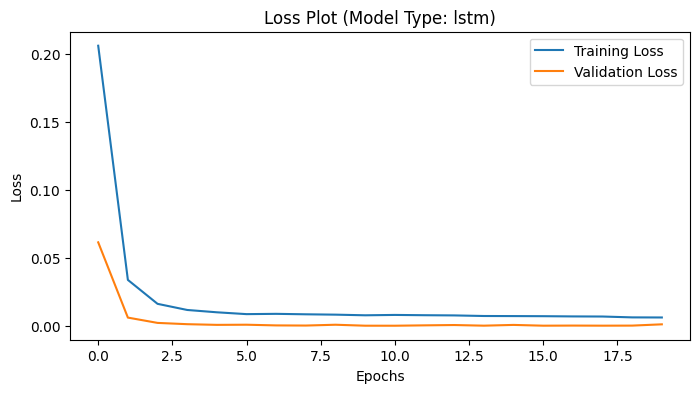

| 23        | -0.001067 | 51.89     | 0.4171    | 0.002838  | 71.05     |


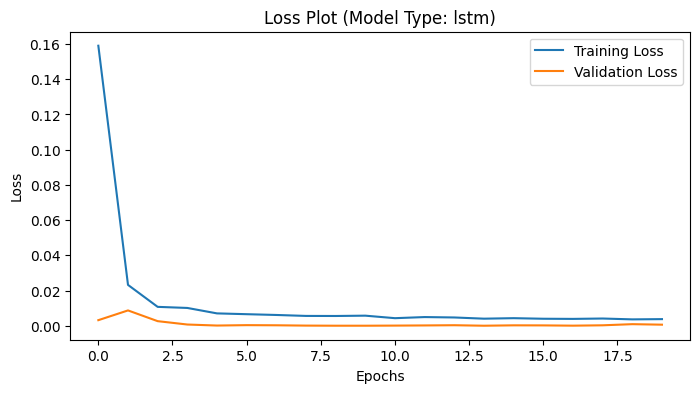

| 24        | -0.000615 | 63.98     | 0.2949    | 0.009105  | 50.98     |


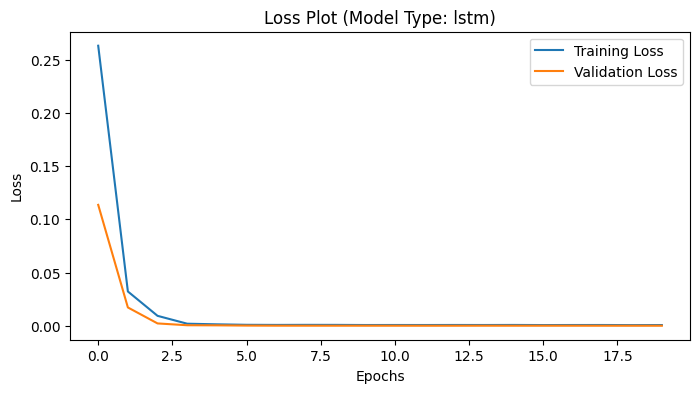

| 25        | -2.277e-0 | 56.9      | 0.04705   | 0.005468  | 99.22     |


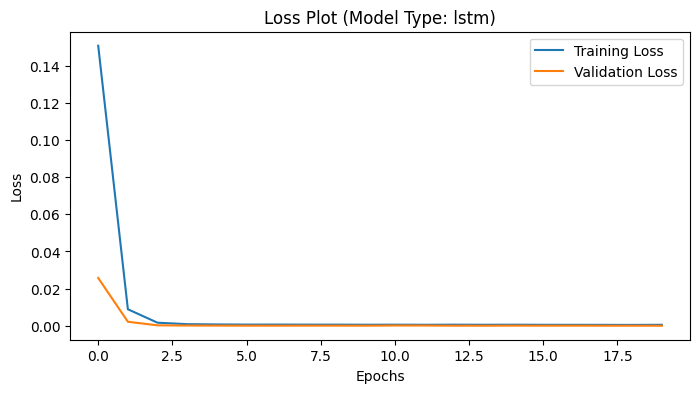

| 26        | -2.628e-0 | 44.27     | 0.03639   | 0.004755  | 86.93     |


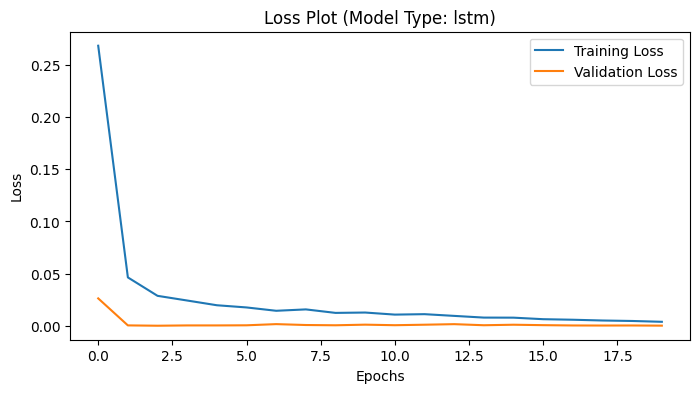

| 27        | -0.000109 | 51.92     | 0.4235    | 0.009599  | 16.05     |


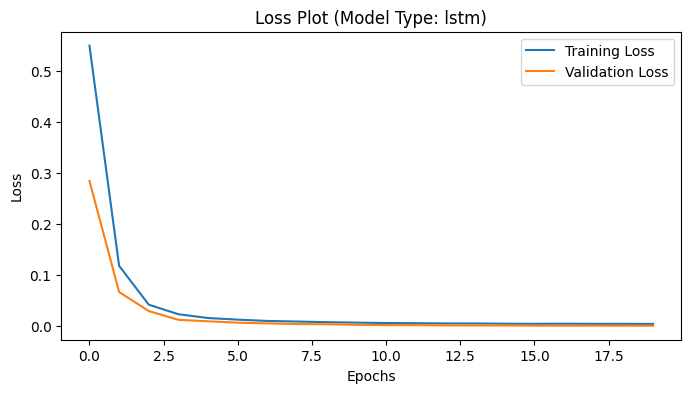

| 28        | -4.183e-0 | 63.43     | 0.2139    | 0.0007332 | 83.33     |


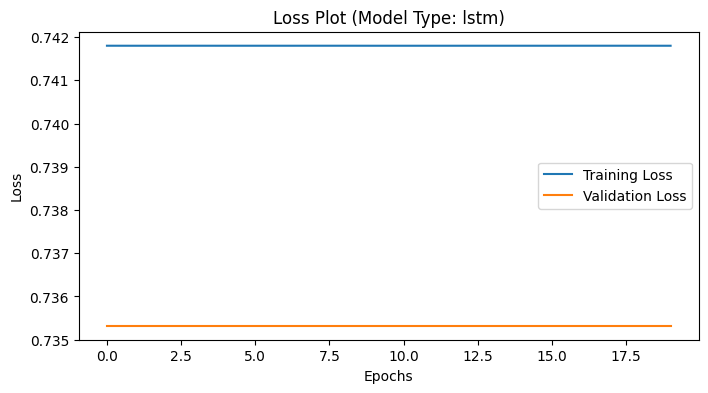

| 29        | -0.7353   | 4.035     | 0.1217    | 0.009261  | 19.11     |


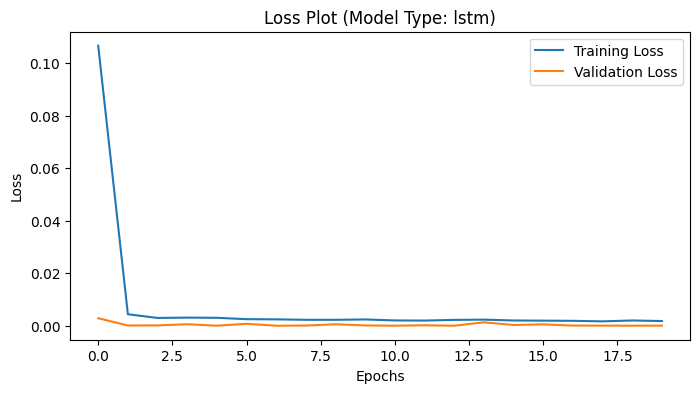

| 30        | -6.852e-0 | 4.159     | 0.1603    | 0.0003649 | 78.54     |


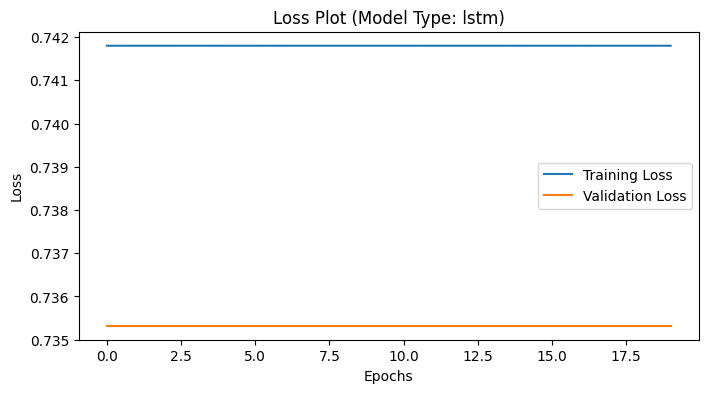

| 31        | -0.7353   | 25.75     | 0.0295    | 0.007212  | 127.7     |


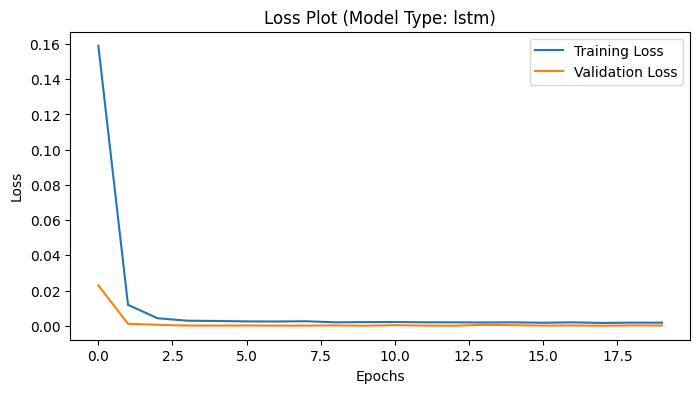

| 32        | -0.000164 | 47.54     | 0.216     | 0.003407  | 113.7     |


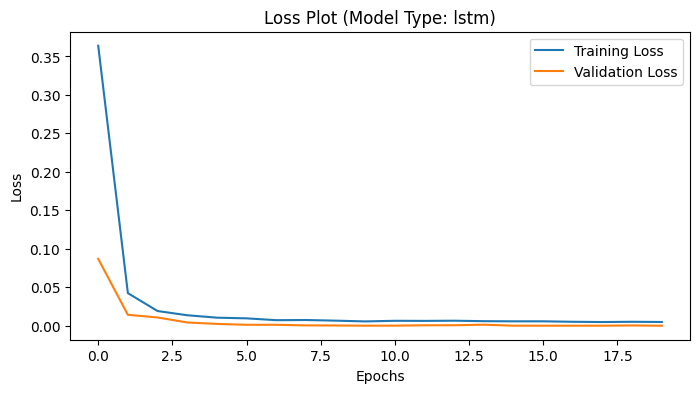

| 33        | -2.326e-0 | 51.47     | 0.4519    | 0.0009875 | 127.9     |


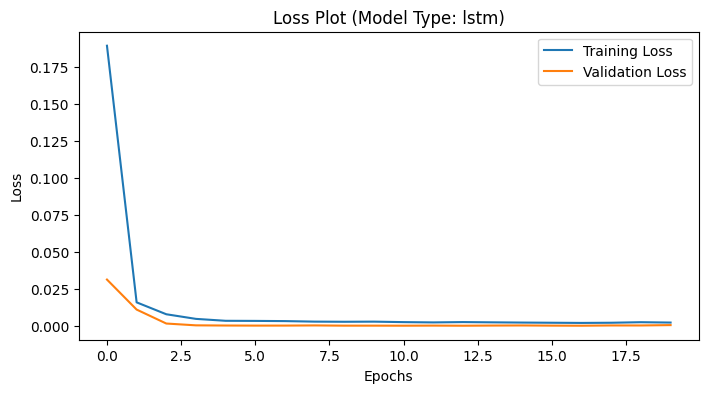

| 34        | -0.000444 | 63.72     | 0.1622    | 0.005074  | 65.61     |


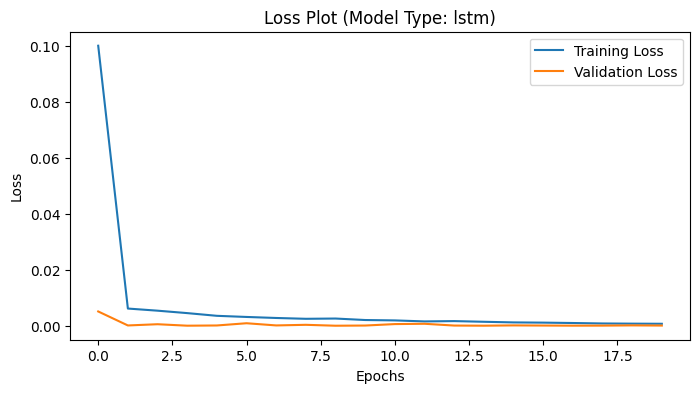

| 35        | -8.186e-0 | 14.83     | 0.3814    | 0.009624  | 90.86     |


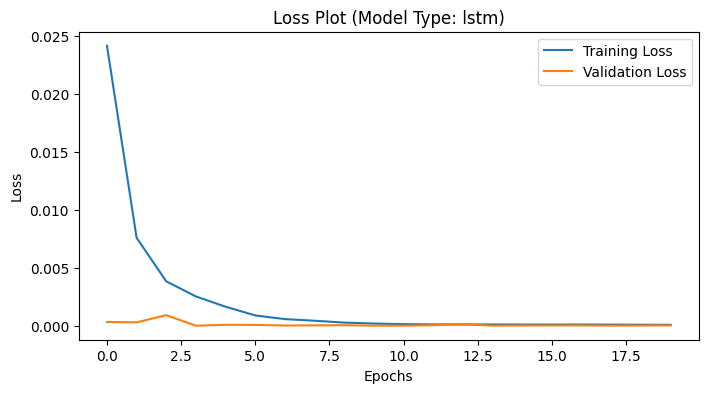

| 36        | -5.303e-0 | 4.045     | 0.4357    | 0.00629   | 64.04     |


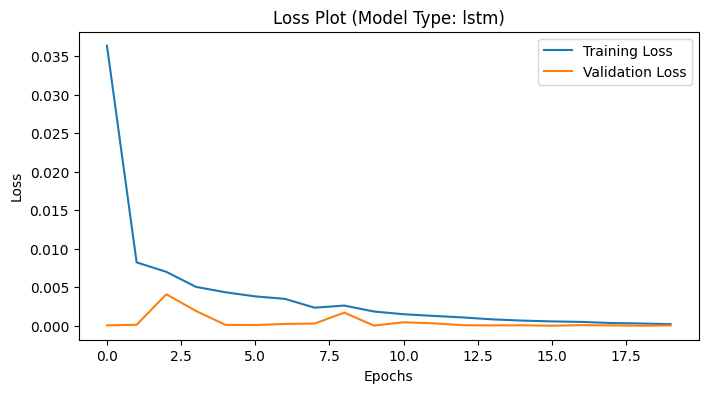

| 37        | -6.283e-0 | 4.027     | 0.4855    | 0.002556  | 126.7     |


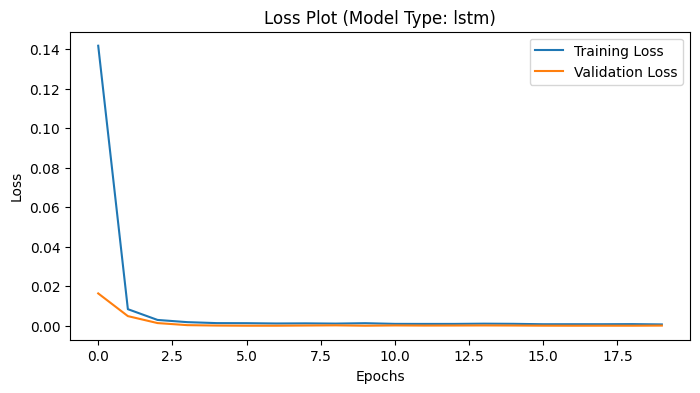

| 38        | -8.744e-0 | 52.62     | 0.05048   | 0.009892  | 57.05     |


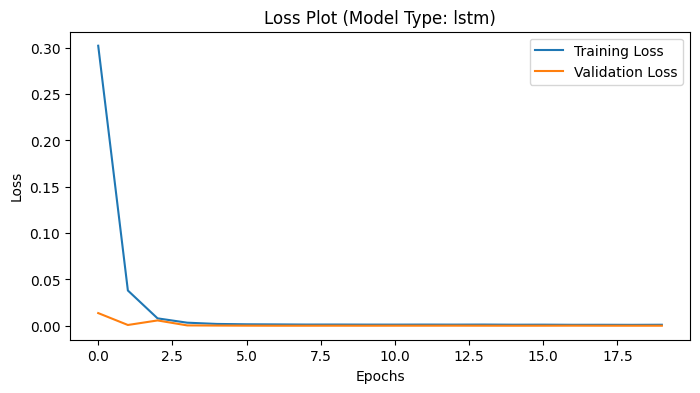

| 39        | -2.766e-0 | 63.92     | 0.1066    | 0.007475  | 107.5     |


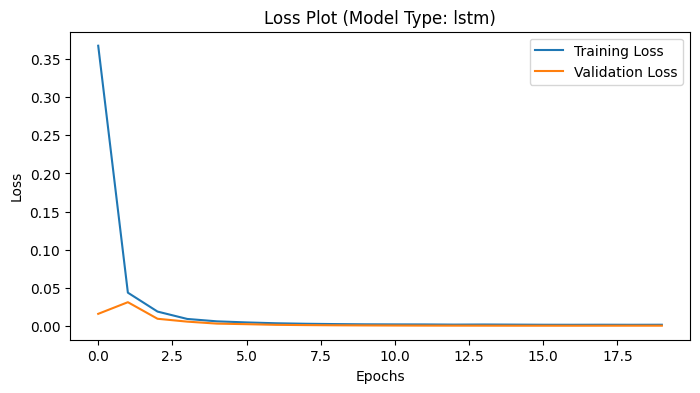

| 40        | -8.099e-0 | 63.95     | 0.04445   | 0.00234   | 38.33     |


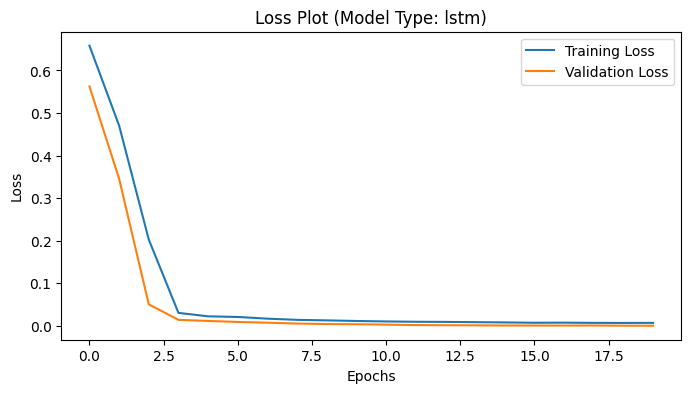

| 41        | -4.848e-0 | 28.79     | 0.3612    | 0.0001432 | 94.91     |


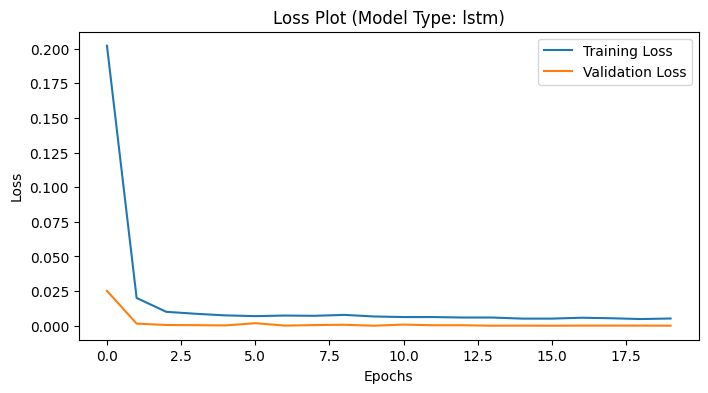

| 42        | -5.328e-0 | 40.64     | 0.3766    | 0.003076  | 67.27     |


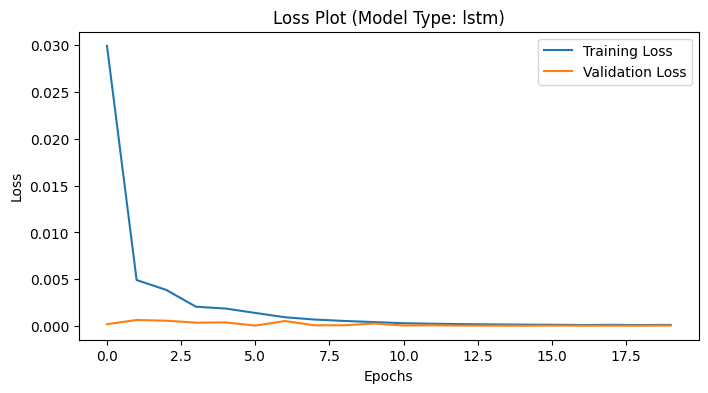

| 43        | -4.941e-0 | 4.057     | 0.3711    | 0.006738  | 116.8     |


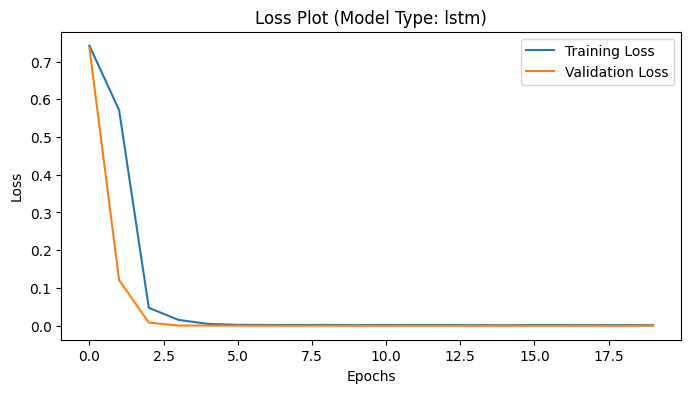

| 44        | -8.077e-0 | 63.27     | 0.02567   | 0.004893  | 16.36     |


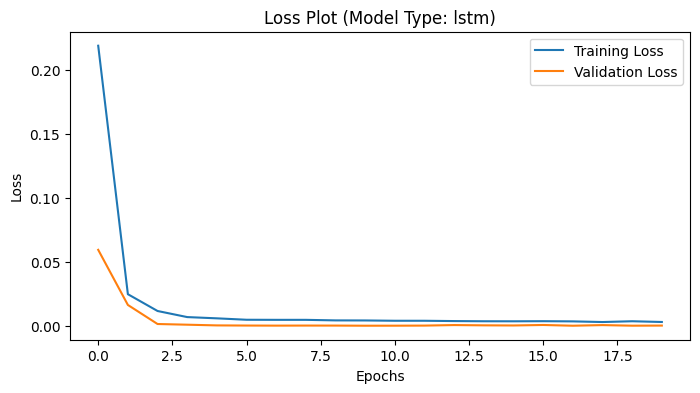

| 45        | -0.000139 | 63.86     | 0.3509    | 0.003086  | 127.7     |


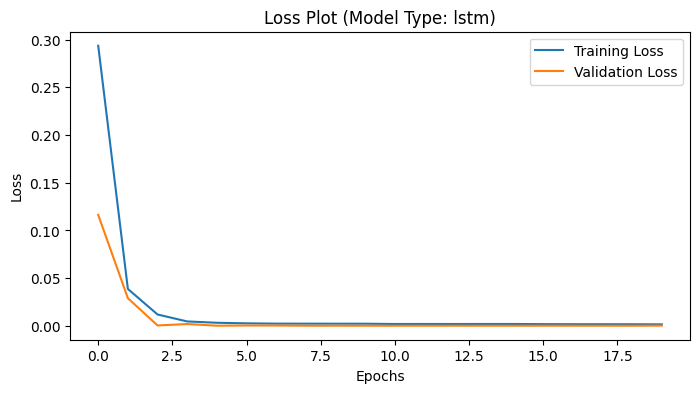

| 46        | -0.000142 | 63.85     | 0.1327    | 0.006482  | 94.09     |


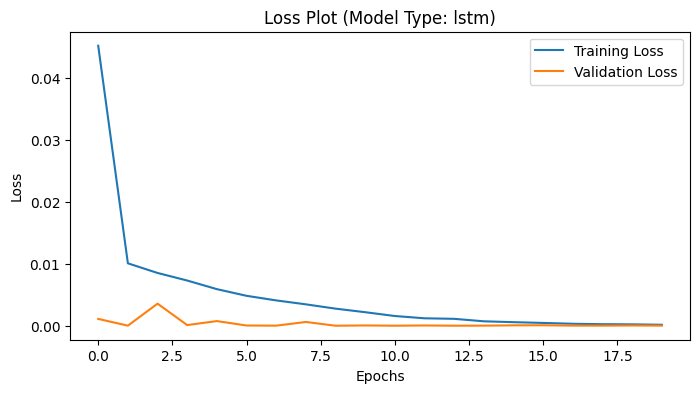

| 47        | -3.942e-0 | 4.166     | 0.3885    | 0.002402  | 45.79     |


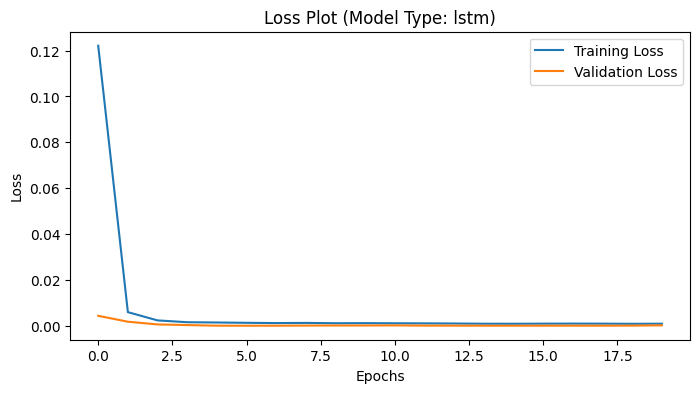

| 48        | -0.000193 | 54.24     | 0.07999   | 0.007202  | 86.78     |


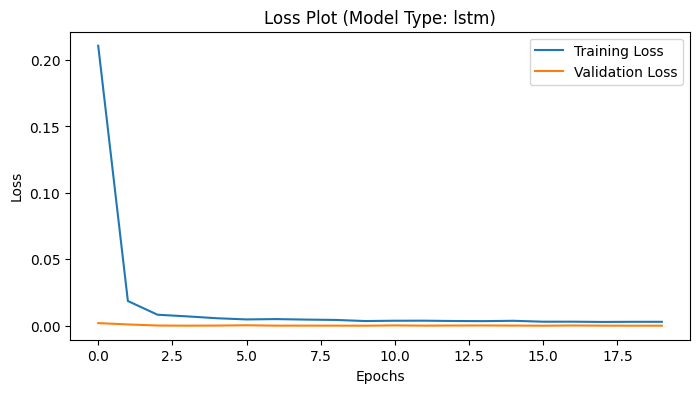

| 49        | -6.275e-0 | 46.13     | 0.3834    | 0.008005  | 97.98     |


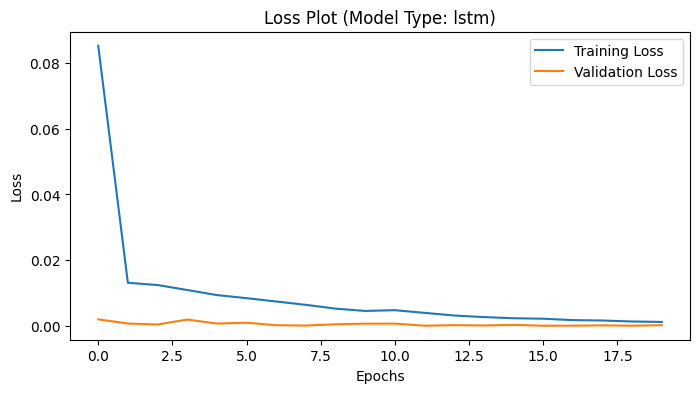

| 50        | -0.000179 | 14.03     | 0.4366    | 0.004801  | 44.35     |
Best hyperparameters:
{'target': -2.277273597428575e-05, 'params': {'batch_size': 56.89927225728135, 'dropout_rate': 0.04705077142779176, 'learning_rate': 0.005468364013886714, 'units': 99.21864764957438}}


In [75]:
# Bayesian 최적화를 위한 하이퍼파라미터 범위 설정
param_bounds = {
    'units': (16, 128),  # RNN 유닛 개수 (정수로 변환 필요)
    'dropout_rate': (0.01, 0.5),  # Dropout 비율
    'learning_rate': (1e-6, 1e-2),  # Learning Rate (연속 값)
    'batch_size': (4, 64),  # Batch Size 범위 (정수로 변환 필요)
}

# Bayesian 최적화 객체 생성
bayesian_optimizer = BayesianOptimization(
    f=lambda units, dropout_rate, learning_rate, batch_size: bayesian_optimization(
        units, dropout_rate, learning_rate, batch_size, model_type='lstm'  # 여기에서 모델 타입 선택
    ),
    pbounds=param_bounds,
    random_state=42,
    verbose=2,
)

# Bayesian 최적화 실행
bayesian_optimizer.maximize(init_points=20, n_iter=30)

# 최적화 결과 출력
print("Best hyperparameters:")
print(bayesian_optimizer.max)

In [76]:
lstm_best_hyperparameters = bayesian_optimizer.max['params']
lstm_best_accuracy = bayesian_optimizer.max['target']

print("Best Hyperparameters:", lstm_best_hyperparameters)
print("Best Validation Accuracy:", lstm_best_accuracy)

# 최적 하이퍼파라미터 저장
lstm_best_hyperparameters = bayesian_optimizer.max['params']

Best Hyperparameters: {'batch_size': 56.89927225728135, 'dropout_rate': 0.04705077142779176, 'learning_rate': 0.005468364013886714, 'units': 99.21864764957438}
Best Validation Accuracy: -2.277273597428575e-05


Epoch 1/20
18/18 [==============================] - 2s 8ms/step - loss: 0.7213 - mse: 0.7213
Epoch 2/20
18/18 [==============================] - 0s 7ms/step - loss: 0.1046 - mse: 0.1046
Epoch 3/20
18/18 [==============================] - 0s 6ms/step - loss: 0.0085 - mse: 0.0085
Epoch 4/20
18/18 [==============================] - 0s 6ms/step - loss: 0.0018 - mse: 0.0018  
Epoch 5/20
18/18 [==============================] - 0s 6ms/step - loss: 8.9258e-04 - mse: 8.9258e-04
Epoch 6/20
18/18 [==============================] - 0s 6ms/step - loss: 7.8534e-04 - mse: 7.8534e-04
Epoch 7/20
18/18 [==============================] - 0s 7ms/step - loss: 7.6893e-04 - mse: 7.6893e-04
Epoch 8/20
18/18 [==============================] - 0s 6ms/step - loss: 7.0080e-04 - mse: 7.0080e-04
Epoch 9/20
18/18 [==============================] - 0s 6ms/step - loss: 7.3162e-04 - mse: 7.3162e-04
Epoch 10/20
18/18 [==============================] - 0s 6ms/step - loss: 7.0447e-04 - mse: 7.0447e-04
Epoch 11/20
18/18 [

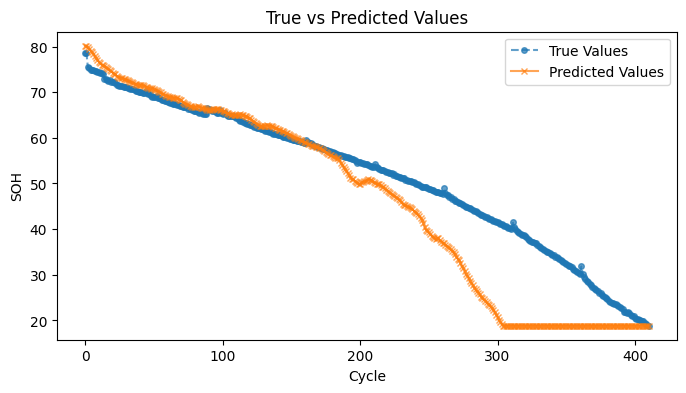

In [77]:
# 최적 하이퍼파라미터로 모델 생성
best_units = int(lstm_best_hyperparameters['units'])
best_dropout_rate = lstm_best_hyperparameters['dropout_rate']
best_learning_rate = lstm_best_hyperparameters['learning_rate']
best_batch_size = int(lstm_best_hyperparameters['batch_size'])

lstm_model = ()
lstm_model = build_lstm_model(best_units, best_dropout_rate, best_learning_rate,fixed_activation)
lstm_model.summary

history = lstm_model.fit(
    train_feature, train_label,
    epochs=20,
    batch_size=best_batch_size,
    verbose=1
)

# 모델 평가
y_pred = lstm_model.predict(test_feature)

#역변환
origin = reverse_min_max_scaling(test_label,x_min,x_max)[:,0]
result = reverse_min_max_scaling(y_pred,x_min,x_max)[:,0]

mse = mean_squared_error(origin, result)
mae = mean_absolute_error(origin, result)
rmse = np.sqrt(mse)
r2 = r2_score(origin, result)

print("Model Evaluation Results:")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² (R-squared): {r2:.4f}")

# 결과 샘플 시각화
plt.figure(figsize=(8, 4))
plt.plot(origin, label="True Values", marker='o', linestyle='--', markersize=4, alpha=0.7)
plt.plot(result, label="Predicted Values", marker='x', linestyle='-', markersize=4, alpha=0.7)
plt.title("True vs Predicted Values")
plt.xlabel("Cycle")
plt.ylabel("SOH")
plt.legend()
plt.show()

## 최종 모델 선정 및 저장

In [78]:
# 모델 저장
model_path = "best_prediction_model.h5"
gru_model.save(model_path) # 디렉토리 생성 (이미 존재하면 무시) 여기에 선정한 모델 이름 적기

print(f"Model saved at: {model_path}")

Model saved at: best_prediction_model.h5


In [79]:
#custom_objects = {'mse': tf.keras.metrics.MeanSquaredError()} # 지금 불러올때 케라스 무너져서 추가함함

loaded_model = load_model("best_prediction_model.h5")

# 로드된 모델로 예측 수행
best_predictions = loaded_model.predict(test_feature)

13/13 [==============================] - 0s 3ms/step


Model Evaluation Results:
Mean Squared Error (MSE): 58.4132
Mean Absolute Error (MAE): 5.2857
Root Mean Squared Error (RMSE): 7.6429
R² (R-squared): 0.7532


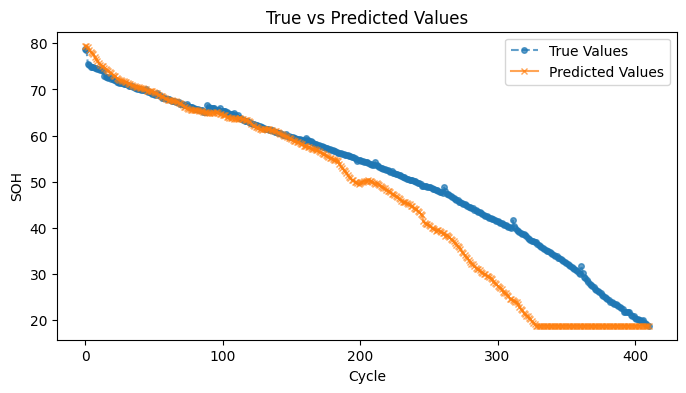

In [80]:
#역변환
origin = reverse_min_max_scaling(test_label,x_min,x_max)[:,0]
result = reverse_min_max_scaling(best_predictions,x_min,x_max)[:,0]


mse = mean_squared_error(origin, result)
mae = mean_absolute_error(origin, result)
rmse = np.sqrt(mse)
r2 = r2_score(origin, result)

print("Model Evaluation Results:")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² (R-squared): {r2:.4f}")

# 결과 샘플 시각화
plt.figure(figsize=(8, 4))
plt.plot(origin, label="True Values", marker='o', linestyle='--', markersize=4, alpha=0.7)
plt.plot(result, label="Predicted Values", marker='x', linestyle='-', markersize=4, alpha=0.7)
plt.title("True vs Predicted Values")
plt.xlabel("Cycle")
plt.ylabel("SOH")
plt.legend()
plt.show()